In [1]:
%pip install openmeteo-requests pandas numpy requests-cache retry-requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.4/820.4 kB 468.8 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 640.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.0 MB/s eta 0:00:00a 0:00:010m
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2━━━━━━━━━━━  3/14 [typing-extensions]
  Attempting uninstall: attrs╺━━━━━━━━━━━━━━━━━━━━━━  6/14 [jh2]xtensions]
    Found existing installation: attrs 24.3.0━━━━━━━━━━━━━━━━━  6/14 [jh2]
    Uninstalling attrs-24.3.0:╺━━━━━━━━━━━━━━━━━━━━━━  6/14 [jh2]
      Successfully uninstalled attrs-24.3.0━━━━━━━━━━━━━━━━━━━  6/14 [jh2]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [openmeteo-requests]iquests]uture]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
from openmeteo_requests import OpenMeteoRequestsError

print("Python used by this notebook:", sys.executable)


Python used by this notebook: /opt/anaconda3/bin/python


## 1. Start with a small Nairobi example
I am starting by collecting past weather data for one point in central Nairobi. This helps me check that downloading, organising and saving the data works before I add more locations. This point represents one place, not the whole county.

I use latitude and longitude to describe the location. Latitude tells me how far north or south a place is, and longitude tells me how far east or west it is. Later, I will use a map of Nairobi County and records of past floods to choose the study locations.

The code below creates folders for the original downloads, the checked data and temporary copies of downloads. Keeping the original data allows me to check my work later.

Open-Meteo estimates weather for areas on a map. Asking for a more precise location does not make those estimates more detailed.

I am following the [Open-Meteo Python guide](https://github.com/open-meteo/python-requests) and the [guide to past weather data](https://open-meteo.com/en/docs/historical-weather-api).

After moving the project, I open this notebook from its new folder and run the cells from top to bottom. The first cell installs packages into the Python used by this notebook. The next cell shows which Python I am using. If I change the notebook kernel, I restart it and run the setup again.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import numpy as np
from IPython.display import display

# Keep data folders inside the project folder.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
CACHE_DIR = DATA_DIR / "cache"
for folder in (RAW_DIR, PROCESSED_DIR, CACHE_DIR):
    folder.mkdir(parents=True, exist_ok=True)
print("Project folder:", PROJECT_DIR)

Project folder: /Users/imeldasidai/Documents/FinalYearProject


## 2. Choose the location and dates
I give each location its own name and ID. The ID will help me match its weather data with its land information and flood records later.

For this first example, I use April 2024. I also download the last seven days of March so I can calculate how much rain fell before the first day of April. Choosing this month does not mean that a flood happened on every day, or at this particular point.

I use one weather source, called ERA5, throughout this download. Its estimates cover areas much larger than individual streets. Later, I will add detailed information about the land to help distinguish locations.

I can change the dates below and add more checked locations to the table when I know which places and years the flood records cover.

In [ ]:
locations = pd.DataFrame([
    {"location_id": "nairobi_pilot_001", "location_name": "Central Nairobi test point",
     "latitude": -1.2864, "longitude": 36.8172}
])

START_DATE = "2024-04-01"
END_DATE = "2024-04-30"
TIMEZONE = "Africa/Nairobi"
WEATHER_MODEL = "era5"
LOOKBACK_DAYS = 7
FETCH_START_DATE = (pd.Timestamp(START_DATE) - pd.Timedelta(days=LOOKBACK_DAYS)).date().isoformat()
API_URL = "https://archive-api.open-meteo.com/v1/archive"
# Keep the requested variables and column names in matching order.
DAILY_VARIABLES = ["precipitation_sum", "temperature_2m_mean", "relative_humidity_2m_mean"]
COLUMN_NAMES = ["precipitation_mm", "temperature_mean_c", "relative_humidity_mean_pct"]

assert pd.Timestamp(START_DATE) <= pd.Timestamp(END_DATE)
assert not locations.empty and locations["location_id"].is_unique
assert locations["location_id"].notna().all()
assert locations["latitude"].between(-90, 90).all()
assert locations["longitude"].between(-180, 180).all()
display(locations)
print(f"Download: {FETCH_START_DATE} to {END_DATE}; analysis: {START_DATE} to {END_DATE}")

         location_id               location_name  latitude  longitude
0  nairobi_pilot_001  Central Nairobi test point   -1.2864    36.8172
Download: 2024-03-25 to 2024-04-30; analysis: 2024-04-01 to 2024-04-30


## 3. Prepare the download connection
I keep a local copy of each download for one day. This saves time when I run the same request again.

If the connection fails temporarily, the code tries again. It also limits how long it waits for a response. I need an internet connection for data that has not already been saved locally.

In [ ]:
# Reuse downloads for one day.
cache_session = requests_cache.CachedSession(
    str(CACHE_DIR / "openmeteo"), expire_after=86400
)
# Retry temporary connection failures.
retry_session = retry(cache_session, retries=3, backoff_factor=0.5)
openmeteo = openmeteo_requests.Client(session=retry_session)

## 4. Download and save the daily weather
I collect each day's total precipitation, average temperature and average humidity. Precipitation means water falling from the atmosphere, including rain and snow. Humidity describes how much moisture is in the air.

I keep both the location I asked for and the location Open-Meteo used for its weather estimate. These may differ because Open-Meteo uses a map divided into areas. I also record the source, dates and units so I can explain where the data came from.

I convert the dates to match Nairobi's local days. I save the original weather table before making any changes. The height returned by Open-Meteo is useful background information; I will still need a separate height map for the land calculations.

In [ ]:
weather_frames = []
request_metadata = []

# Download weather for each study point.
for location in locations.itertuples(index=False):
    params = {
        "latitude": location.latitude,
        "longitude": location.longitude,
        "start_date": FETCH_START_DATE,
        "end_date": END_DATE,
        "daily": DAILY_VARIABLES,
        "timezone": TIMEZONE,
        "models": WEATHER_MODEL,
        "temperature_unit": "celsius",
        "precipitation_unit": "mm",
    }
    try:
        responses = openmeteo.weather_api(API_URL, params=params, timeout=60)
    except OpenMeteoRequestsError as error:
        raise RuntimeError(
            f"Weather download failed for {location.location_id}. "
            "If the details below mention HTTP 500, Open-Meteo returned a server error; "
            "wait a few minutes and rerun this cell. For connection errors, check "
            "your internet connection. Do not run the later weather cells until "
            f"this download succeeds. Details: {error}"
        ) from error
    if len(responses) != 1:
        raise ValueError(f"Expected one response for {location.location_id}; got {len(responses)}")
    response = responses[0]
    daily_response = response.Daily()
    if daily_response is None or daily_response.VariablesLength() != len(DAILY_VARIABLES):
        raise ValueError(f"Missing daily variables for {location.location_id}")

    # Read the dates as Nairobi calendar days.
    timestamps = np.arange(daily_response.Time(), daily_response.TimeEnd(), daily_response.Interval())
    local_dates = pd.to_datetime(timestamps + response.UtcOffsetSeconds(), unit="s").normalize()
    frame = pd.DataFrame({"date": local_dates})
    for index, column in enumerate(COLUMN_NAMES):
        frame[column] = daily_response.Variables(index).ValuesAsNumpy()
    # Keep the study point separate from the weather source location.
    frame["location_id"] = location.location_id
    frame["latitude"] = location.latitude
    frame["longitude"] = location.longitude
    frame["weather_grid_latitude"] = response.Latitude()
    frame["weather_grid_longitude"] = response.Longitude()
    weather_frames.append(frame)
    request_metadata.append({
        "location_id": location.location_id,
        "url": API_URL,
        "parameters": params,
        "weather_grid_latitude": response.Latitude(),
        "weather_grid_longitude": response.Longitude(),
        "api_elevation_m": response.Elevation(),
        "utc_offset_seconds": response.UtcOffsetSeconds(),
    })

# Save the original values and download details.
raw_weather = pd.concat(weather_frames, ignore_index=True)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
raw_path = RAW_DIR / f"nairobi_daily_{RUN_ID}.csv"
raw_weather.to_csv(raw_path, index=False)
metadata = {
    "run_id": RUN_ID,
    "retrieved_or_loaded_from_cache_at_utc": datetime.now(timezone.utc).isoformat(),
    "source": "Open-Meteo Historical Weather API",
    "documentation": "https://open-meteo.com/en/docs/historical-weather-api",
    "coordinate_crs": "EPSG:4326",
    "date_timezone": TIMEZONE,
    "units": dict(zip(COLUMN_NAMES, ["mm", "degrees Celsius", "percent"])),
    "requests": request_metadata,
}
(RAW_DIR / f"nairobi_daily_{RUN_ID}_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)
print(f"Saved {len(raw_weather)} raw rows to {raw_path}")
display(raw_weather.head())
display(raw_weather[["location_id", "latitude", "longitude", "weather_grid_latitude", "weather_grid_longitude"]].drop_duplicates())

Saved 37 raw rows to /Users/imeldasidai/Documents/FinalYearProject/data/raw/nairobi_daily_20260915T164242268415Z.csv
        date  precipitation_mm  ...  weather_grid_latitude  weather_grid_longitude
0 2024-03-25               7.5  ...                  -1.25                   36.75
1 2024-03-26               0.2  ...                  -1.25                   36.75
2 2024-03-27               1.9  ...                  -1.25                   36.75
3 2024-03-28               0.9  ...                  -1.25                   36.75
4 2024-03-29               1.2  ...                  -1.25                   36.75

[5 rows x 9 columns]
         location_id  latitude  ...  weather_grid_latitude  weather_grid_longitude
0  nairobi_pilot_001   -1.2864  ...                  -1.25                   36.75

[1 rows x 5 columns]


## 5. Check for missing days and unusual values
I check that each location has only one row for each day. If a day is missing, I add its date and leave the weather values empty. This prevents later calculations from accidentally skipping a day.

I check for impossible values, such as negative precipitation or humidity below 0% or above 100%. I leave these values empty in the checked copy and keep the original download unchanged.

I do not treat missing rain data as zero rainfall. I also show the largest precipitation values for review because heavy rain could be important for this project.

The results below show missing values, values rejected by these checks and a summary of the weather. Passing these checks does not prove that the estimates match what happened on the ground.

In [ ]:
keys = ["location_id", "date"]
if raw_weather.duplicated(keys).any():
    raise ValueError("Duplicate location-date rows: investigate before continuing.")
# Include every requested day, even if its weather is missing.
expected_dates = pd.date_range(FETCH_START_DATE, END_DATE, freq="D")
expected_index = pd.MultiIndex.from_product(
    [locations["location_id"], expected_dates], names=keys
)
if not raw_weather["date"].isin(expected_dates).all():
    raise ValueError("API dates fall outside the requested local date range.")
missing_day_rows = len(expected_index.difference(pd.MultiIndex.from_frame(raw_weather[keys])))
clean_weather = raw_weather.set_index(keys)[COLUMN_NAMES].reindex(expected_index).reset_index()
clean_weather = clean_weather.merge(locations, on="location_id", how="left", validate="many_to_one")
# Leave impossible values empty in the checked copy.
invalid_counts = {}
for column in COLUMN_NAMES:
    values = clean_weather[column]
    invalid = values.notna() & ~np.isfinite(values)
    if column == "precipitation_mm":
        invalid |= values.lt(0)
    elif column == "relative_humidity_mean_pct":
        invalid |= values.lt(0) | values.gt(100)
    invalid_counts[column] = int(invalid.sum())
    clean_weather.loc[invalid, column] = np.nan

quality_report = pd.DataFrame({
    "invalid_values_replaced": pd.Series(invalid_counts),
    "missing_after_cleaning": clean_weather[COLUMN_NAMES].isna().sum(),
})
print("Missing location-date rows inserted:", missing_day_rows)
display(quality_report)
display(clean_weather[COLUMN_NAMES].describe())
print("Largest daily precipitation estimates ? inspect, do not automatically discard:")
display(clean_weather.nlargest(5, "precipitation_mm")[["location_id", "date", "precipitation_mm"]])

Missing location-date rows inserted: 0
                            invalid_values_replaced  missing_after_cleaning
precipitation_mm                                  0                       0
temperature_mean_c                                0                       0
relative_humidity_mean_pct                        0                       0
       precipitation_mm  temperature_mean_c  relative_humidity_mean_pct
count         37.000000           37.000000                   37.000000
mean           6.521621           20.773333                   78.125999
std            6.929251            0.648687                    5.678978
min            0.100000           19.315165                   68.208199
25%            1.900000           20.358915                   73.158661
50%            3.300000           20.833916                   77.503387
75%            9.700001           21.179750                   82.526947
max           25.699999           22.281832                   88.576332
Largest d

## 6. Calculate weather information from earlier days
I prepare one row for each day in April. Each row contains information from earlier days that could help the model learn about flood conditions.

For example, the row dated 8 April contains precipitation totals for 7 April, 5 to 7 April, and 1 to 7 April. It also contains the previous day's average temperature and humidity. It does not use weather from 8 April itself.

I calculate these totals separately for each location. If a required day has missing data, I leave the total empty instead of guessing.

This is still a study of past weather. ERA5 data becomes available after the weather has happened. Before using the system for live warnings, I will need to check which weather information would actually be available when a warning is made.

In [ ]:
feature_parts = []
FEATURE_COLUMNS = ["precipitation_previous_1d_mm", "precipitation_previous_3d_mm",
                   "precipitation_previous_7d_mm", "temperature_previous_day_c",
                   "relative_humidity_previous_day_pct"]
for location_id, group in clean_weather.groupby("location_id", sort=False):
    group = group.sort_values("date").copy()
    # Use only days before the date on this row.
    preceding_precipitation = group["precipitation_mm"].shift(1)
    for days in (1, 3, 7):
        group[f"precipitation_previous_{days}d_mm"] = preceding_precipitation.rolling(
            window=days, min_periods=days
        ).sum()
    group["temperature_previous_day_c"] = group["temperature_mean_c"].shift(1)
    group["relative_humidity_previous_day_pct"] = group["relative_humidity_mean_pct"].shift(1)
    feature_parts.append(group)

weather_features = pd.concat(feature_parts, ignore_index=True)
# Keep April rows after using March to calculate earlier-day totals.
weather_features = weather_features.loc[
    weather_features["date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE)),
    ["location_id", "location_name", "date", "latitude", "longitude"] + FEATURE_COLUMNS,
].reset_index(drop=True)
print("Feature rows:", len(weather_features))
display(weather_features.head(10))
display(weather_features[FEATURE_COLUMNS].isna().sum().rename("missing_feature_rows"))

Feature rows: 30
         location_id  ... relative_humidity_previous_day_pct
0  nairobi_pilot_001  ...                          75.295670
1  nairobi_pilot_001  ...                          73.158661
2  nairobi_pilot_001  ...                          75.728783
3  nairobi_pilot_001  ...                          72.189827
4  nairobi_pilot_001  ...                          75.554482
5  nairobi_pilot_001  ...                          76.320427
6  nairobi_pilot_001  ...                          84.440208
7  nairobi_pilot_001  ...                          76.112442
8  nairobi_pilot_001  ...                          78.025093
9  nairobi_pilot_001  ...                          74.163651

[10 rows x 10 columns]
precipitation_previous_1d_mm          0
precipitation_previous_3d_mm          0
precipitation_previous_7d_mm          0
temperature_previous_day_c            0
relative_humidity_previous_day_pct    0
Name: missing_feature_rows, dtype: int64


## 7. Save the checked data and calculations
I save the checked daily weather and the earlier-day calculations in separate files. I also save the location list and the results of the data checks.

Each run gets a different filename so I can keep track of the results. These files do not yet say whether a flood happened. I need land information and reliable flood records before I can train a model.

In [ ]:
# Save separate files for each result.
clean_path = PROCESSED_DIR / f"nairobi_daily_clean_{RUN_ID}.csv"
features_path = PROCESSED_DIR / f"nairobi_weather_features_{RUN_ID}.csv"
clean_weather.to_csv(clean_path, index=False)
weather_features.to_csv(features_path, index=False)
quality_report.to_csv(PROCESSED_DIR / f"nairobi_quality_{RUN_ID}.csv", index_label="variable")
locations.to_csv(PROCESSED_DIR / f"study_locations_{RUN_ID}.csv", index=False)
print("Clean weather:", clean_path)
print("Weather features:", features_path)

Clean weather: /Users/imeldasidai/Documents/FinalYearProject/data/processed/nairobi_daily_clean_20260915T164242268415Z.csv
Weather features: /Users/imeldasidai/Documents/FinalYearProject/data/processed/nairobi_weather_features_20260915T164242268415Z.csv


## 8. Prepare the land information and flood records
I have created two empty tables below to show the information I need next. Empty tables are expected here because I have not added those records yet.

For the land table, I need each location's height, how steep the ground is, its distance from a river and the source of that information. I will use a height map, also called a digital elevation model, to help calculate these values. Distance calculations must use a map measured in metres.

For the flood table, I need the location, date, source and how certain the record is. I will use 1 when the evidence shows flooding and 0 when reliable records support that flooding did not happen. A missing flood report alone is not enough to assign 0. I will leave uncertain cases empty.

My next step is to obtain the Nairobi County boundary and dated flood records, then choose locations that those records can support. A report saying that Nairobi flooded cannot tell me which individual street flooded.

After adding these records, I will match the tables by location and date. I will train the models on earlier periods and test them on later periods, keeping records of the same flood event together. I will compare logistic regression, random forest and XGBoost using the same data split.

In [ ]:
# Leave these tables empty until source records are available.
terrain_template = pd.DataFrame(columns=[
    "location_id", "elevation_m", "slope_degrees", "distance_to_river_m", "terrain_source"
])
flood_labels_template = pd.DataFrame(columns=[
    "location_id", "date", "flood_label", "event_id", "label_source", "label_confidence"
])
display(terrain_template)
display(flood_labels_template)


Empty DataFrame
Columns: [location_id, elevation_m, slope_degrees, distance_to_river_m, terrain_source]
Index: []
Empty DataFrame
Columns: [location_id, date, flood_label, event_id, label_source, label_confidence]
Index: []


## 9. Add tools for working with maps
I now need to check where my study points are and compare them with a flood map. GeoPandas lets me work with locations and boundaries. Matplotlib lets me draw the results.

The next cell installs these two tools. If the notebook asks for a restart after installation, I restart it and run the earlier cells again.

In [10]:
%pip install geopandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 296.9 kB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 235.7 kB/s eta 0:00:00a 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 97.6 kB/s eta 0:00:00a 0:00:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import hashlib
import zipfile
import requests
import geopandas as gpd

GEOGRAPHY_RAW_DIR = RAW_DIR / "geography"
GEOGRAPHY_DIR = PROCESSED_DIR / "geography"
FIGURES_DIR = DATA_DIR / "figures"
for folder in (GEOGRAPHY_RAW_DIR, GEOGRAPHY_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)
# Keep the map settings inside the project.
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
import matplotlib.pyplot as plt

MAP_CRS = "EPSG:4326"
DISTANCE_CRS = "EPSG:32737"

def save_geojson(frame, destination):
    # Replace the old file only after the new map is fully saved.
    temporary = destination.with_name(destination.stem + ".tmp.geojson")
    frame.to_file(temporary, driver="GeoJSON")
    temporary.replace(destination)


## 10. Save the boundary and flood sources
I use the Kenya county boundaries shared by geoBoundaries. This copy represents boundaries from 2020 and names RCMRD GeoPortal and Africa GeoPortal as its sources. I keep its source details with the download. This is a study boundary, not a legal boundary survey.

I also use a UNOSAT flood map based on a satellite image taken on **1 May 2024 at 11:06 a.m. in Nairobi**. The map was published on 6 May. I use the image date when describing the observation, not the publication date.

UNOSAT calls this a preliminary result that has not been checked on the ground. It shows what was visible in the analysed area at that time. I cannot use it to label every place or every day in April.

Sources: [geoBoundaries record](https://www.geoboundaries.org/api/current/gbOpen/KEN/ADM1/), [UNOSAT data on HDX](https://data.humdata.org/dataset/flood-impact-analysis-in-nairobi-kenya-as-of-1-may-2024), and [UNOSAT map](https://unosat.org/products/3834).

The code reuses files already downloaded. The UNOSAT download may take longer than the weather request.

In [ ]:
SOURCE_URLS = {
    "kenya_counties_metadata.json": "https://www.geoboundaries.org/api/current/gbOpen/KEN/ADM1/",
    "kenya_counties.geojson": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/KEN/ADM1/geoBoundaries-KEN-ADM1.geojson",
    "unosat_nairobi_metadata.json": "https://data.humdata.org/api/3/action/package_show?id=flood-impact-analysis-in-nairobi-kenya-as-of-1-may-2024",
    "unosat_nairobi_20240501_gdb.zip": "https://unosat.org/static/unosat_filesystem/3834/FL20240426KEN_gdb.zip",
    "unosat_nairobi_20240501.pdf": "https://unosat.org/static/unosat_filesystem/3834/UNOSAT_A3_Natural_Landscape_FL20240426KEN_Nairobi_Map5_6May2024_RevisedStat.pdf",
}
source_session = retry(requests.Session(), retries=3, backoff_factor=0.5)
source_records = []
for filename, url in SOURCE_URLS.items():
    destination = GEOGRAPHY_RAW_DIR / filename
    if not destination.exists():
        # Finish each download before giving it its final name.
        temporary = destination.with_suffix(destination.suffix + ".part")
        with source_session.get(url, timeout=(15, 120), stream=True) as response:
            response.raise_for_status()
            with temporary.open("wb") as handle:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    handle.write(chunk)
        temporary.replace(destination)
    source_records.append({
        "filename": filename,
        "source_url": url,
        "bytes": destination.stat().st_size,
        "sha256": hashlib.sha256(destination.read_bytes()).hexdigest(),
    })

boundary_metadata = json.loads((GEOGRAPHY_RAW_DIR / "kenya_counties_metadata.json").read_text(encoding="utf-8"))
hdx_response = json.loads((GEOGRAPHY_RAW_DIR / "unosat_nairobi_metadata.json").read_text(encoding="utf-8"))
if not hdx_response.get("success"):
    raise ValueError("The flood source details could not be read.")
flood_metadata = hdx_response["result"]
source_manifest = {
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "boundary_source": boundary_metadata.get("boundarySource"),
    "boundary_year": boundary_metadata.get("boundaryYearRepresented"),
    "boundary_license": boundary_metadata.get("boundaryLicense"),
    "boundary_download_url": SOURCE_URLS["kenya_counties.geojson"],
    "flood_source": "UNITAR-UNOSAT, distributed through HDX",
    "flood_license": flood_metadata.get("license_title"),
    "flood_observed_at": "2024-05-01T11:06:00+03:00",
    "flood_published_on": "2024-05-06",
    "files": source_records,
}
(GEOGRAPHY_DIR / "source_manifest.json").write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
display(pd.DataFrame(source_records)[["filename", "bytes"]])
print("Boundary source:", source_manifest["boundary_source"])
print("Boundary year:", source_manifest["boundary_year"])
print("Flood data licence:", source_manifest["flood_license"])

                          filename     bytes
0     kenya_counties_metadata.json      1710
1           kenya_counties.geojson   7956137
2     unosat_nairobi_metadata.json      9308
3  unosat_nairobi_20240501_gdb.zip  11409804
4      unosat_nairobi_20240501.pdf   4706039
Boundary source: RCMRD GeoPortal, Africa GeoPortal
Boundary year: 2020
Flood data licence: Creative Commons Attribution Share-Alike (CC BY-SA)


## 11. Select Nairobi County and check the first point
The boundary file contains Kenya's counties. I select the county named Nairobi and check that the shape can be used for map calculations.

I then check whether my original weather point falls inside or on Nairobi's boundary. The coordinates are in degrees for this check. For land areas and distances, I convert the map to a system that uses metres.

I save Nairobi's boundary so I can reuse it when choosing more locations.

In [ ]:
kenya_counties = gpd.read_file(GEOGRAPHY_RAW_DIR / "kenya_counties.geojson")
if kenya_counties.crs is None:
    raise ValueError("The county file has no coordinate system.")
nairobi_boundary = kenya_counties.loc[
    kenya_counties["shapeName"].str.strip().str.casefold().eq("nairobi")
].to_crs(MAP_CRS).copy()
if len(nairobi_boundary) != 1 or not nairobi_boundary.geometry.is_valid.all():
    raise ValueError("Expected one valid Nairobi boundary. Check the source file.")
nairobi_shape = nairobi_boundary.geometry.union_all()

study_points = gpd.GeoDataFrame(
    locations.copy(),
    geometry=gpd.points_from_xy(locations["longitude"], locations["latitude"]),
    crs=MAP_CRS,
)
study_points["inside_nairobi"] = study_points.geometry.map(nairobi_shape.covers)
if not study_points["inside_nairobi"].all():
    raise ValueError("A study point is outside Nairobi. Check its coordinates.")
save_geojson(nairobi_boundary, GEOGRAPHY_DIR / "nairobi_county.geojson")
save_geojson(study_points, GEOGRAPHY_DIR / "checked_study_points.geojson")
print("County records in source:", len(kenya_counties))
print("Nairobi area from this boundary (square kilometres):",
      round(nairobi_boundary.to_crs(DISTANCE_CRS).area.sum() / 1_000_000, 1))
display(study_points[["location_id", "latitude", "longitude", "inside_nairobi"]])

County records in source: 47
Nairobi area from this boundary (square kilometres): 705.3
         location_id  latitude  longitude  inside_nairobi
0  nairobi_pilot_001   -1.2864    36.8172            True


## 12. Check what the flood download contains
A map download can contain several kinds of information, such as water outlines, buildings and the area the satellite team examined. I list the files first so I can choose the right information rather than treating every shape as a flood.

I unpack a local working copy of the map files so repeated reads are faster. I keep the original ZIP file unchanged.

In [ ]:
flood_zip = GEOGRAPHY_RAW_DIR / "unosat_nairobi_20240501_gdb.zip"
with zipfile.ZipFile(flood_zip) as archive:
    database_names = sorted({name.split(".gdb/")[0] + ".gdb"
                             for name in archive.namelist() if ".gdb/" in name})
if len(database_names) != 1:
    raise ValueError("Expected one map database in the download.")
# Read a local copy to avoid repeated work inside the ZIP file.
archive_id = hashlib.sha256(flood_zip.read_bytes()).hexdigest()[:16]
map_cache = CACHE_DIR / f"unosat_{archive_id}"
map_cache.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(flood_zip) as archive:
    for member in archive.infolist():
        target = (map_cache / member.filename).resolve()
        if not target.is_relative_to(map_cache.resolve()):
            raise ValueError("The map archive contains an unexpected file path.")
        if not target.exists() or (not member.is_dir() and target.stat().st_size != member.file_size):
            archive.extract(member, map_cache)
flood_database = str(map_cache / database_names[0])
flood_layers = gpd.list_layers(flood_database)
display(flood_layers)


                                                 name    geometry_type
0   VIIRS_20240424_20240428_MaximumFloodWaterExten...     MultiPolygon
1      VIIRS_20240424_20240428_CloudObstruction_Kenya     MultiPolygon
2                                       Confidence_ID             None
3                                      Water_StatusID             None
4                                         Water_Class             None
5                                    Field_Validation             None
6        VIIRS_20240424_20240428_AnalysisExtent_Kenya     MultiPolygon
7   S2_20240429_AnalysisExtent_AlongTanaRiver_Gala...     MultiPolygon
8   S2_20240429_CloudObstruction_AlongTanaRiver_Ga...     MultiPolygon
9   S2_20240429_WaterExtent_AlongTanaRiver_GalanaR...     MultiPolygon
10  S2_20240429_FloodExtent_AlongTanaRiver_GalanaR...     MultiPolygon
11   S2_20240429_PotentiallyAffectedStructure_Garissa            Point
12                 S2_20240429_AnalysisExtent_Garissa     MultiPolygon
13    

## 13. Record the date and source of the first flood observation
I keep a list of the flood observations I find. Each record includes when the satellite image was taken, where the information came from and what still needs checking.

The first record belongs to the May 2024 observation. It is a source record, not a flood label for my original weather point. A single image also does not tell me how long the flooding lasted.

The check below shows whether the observation date is already in my weather calculations. If it is not, I will need weather data for that date and its preceding days once I choose the study locations.

In [ ]:
flood_observations = pd.DataFrame([{
    "observation_id": "unosat_3834_20240501",
    "event_id": "FL20240426KEN",
    "observed_at": "2024-05-01T11:06:00+03:00",
    "observation_date": "2024-05-01",
    "published_on": "2024-05-06",
    "source": "UNITAR-UNOSAT",
    "source_url": "https://unosat.org/products/3834",
    "status": "Preliminary satellite observation; field checks pending",
    "training_label_ready": False,
}])
flood_observations["observation_date"] = pd.to_datetime(flood_observations["observation_date"])
flood_observations["date_in_weather_features"] = flood_observations["observation_date"].isin(
    pd.to_datetime(weather_features["date"])
)
flood_observations.to_csv(GEOGRAPHY_DIR / "flood_observations.csv", index=False)
display(flood_observations[["observation_id", "observation_date", "date_in_weather_features", "training_label_ready"]])
print("Recorded flood observations:", len(flood_observations))
print("Independent flood events:", flood_observations["event_id"].nunique())
print("This source alone is not enough to train and test a flood forecasting model.")

         observation_id  ... training_label_ready
0  unosat_3834_20240501  ...                False

[1 rows x 4 columns]
Recorded flood observations: 1
Independent flood events: 1
This source alone is not enough to train and test a flood forecasting model.


## 14. Choose the matching flood map and check its shapes
The download contains maps for several places and dates. I select only the flood outline, the area examined and the clouds for the Nairobi/Kiambu image taken on 1 May 2024.

The file's explanation of its codes identifies water class 1 as flood water. It also says these flood shapes have not been checked on the ground. I keep those details instead of treating the map as certain evidence.

One flood shape has an error in how its outline is drawn. I repair a working copy so the map calculations can run and record how many shapes needed repair. The original download stays unchanged. I calculate areas from the repaired map instead of using the source's area columns, which appear inconsistent.

Some cloud records are missing a date or have a different event code. I keep all shapes from this image's cloud layer as possible blocked views. This avoids treating an uncertain area as clearly observed.

In [ ]:
LAYER_NAMES = {
    "flood": "PL_20240501_FloodExtent_Nairobi_Kiambu",
    "coverage": "PL_20240501_AnalysisExtent_Nairobi_Kiambu",
    "clouds": "PL_20240501_CloudObstruction_Nairobi_Kiambu",
}
if not set(LAYER_NAMES.values()).issubset(set(flood_layers["name"])):
    raise ValueError("The expected Nairobi flood layers are missing.")

water_codes = gpd.read_file(flood_database, layer="Water_Class")
validation_codes = gpd.read_file(flood_database, layer="Field_Validation")
display(water_codes)
display(validation_codes)

map_layers = {}
layer_checks = []
for kind, layer_name in LAYER_NAMES.items():
    layer = gpd.read_file(flood_database, layer=layer_name)
    if layer.crs is None or layer.geometry.isna().any() or layer.geometry.is_empty.any():
        raise ValueError(f"Missing map information in {layer_name}")
    date_column = "Sensor_Date" if kind == "flood" else "SensorDate"
    dates = pd.to_datetime(layer[date_column], utc=True, errors="coerce").dt.strftime("%Y-%m-%d")
    if kind != "clouds" and not dates.eq("2024-05-01").all():
        raise ValueError(f"Unexpected observation dates in {layer_name}")
    if kind == "flood" and not layer["Water_Class"].eq(1).all():
        raise ValueError("The selected layer includes a different water class.")

    # Repair a copy of the outlines and keep only areas.
    event_code_issues = int((~layer["EventCode"].fillna("").str.upper().eq("FL20240426KEN")).sum())
    invalid_count = int((~layer.geometry.is_valid).sum())
    layer.geometry = layer.geometry.make_valid()
    layer = layer.explode(index_parts=False).reset_index(drop=True)
    non_area_count = int((~layer.geom_type.isin(["Polygon", "MultiPolygon"])).sum())
    layer = layer.loc[layer.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    layer = layer.to_crs(DISTANCE_CRS)
    if layer.empty or not layer.geometry.is_valid.all():
        raise ValueError(f"The repaired map still needs checking: {layer_name}")
    map_layers[kind] = layer
    layer_checks.append({
        "layer": layer_name,
        "source_shapes_repaired": invalid_count,
        "non_area_parts_removed": non_area_count,
        "source_dates_missing": int(dates.isna().sum()),
        "source_dates_different": int((dates.notna() & dates.ne("2024-05-01")).sum()),
        "event_codes_different_or_missing": event_code_issues,
        "working_shapes": len(layer),
    })

layer_audit = pd.DataFrame(layer_checks)
layer_audit.to_csv(GEOGRAPHY_DIR / "flood_layer_checks.csv", index=False)
display(layer_audit)
print("Areas will be calculated from the map outlines in metres.")

   Water_Class_code                                    Water_Class_txt
0                 0                                     Preflood Water
1                 1                                        Flood Water
2                 2         Flood-Affected Land / Possible Flood water
3                 3                 Probable Flash Flood-Affected Land
4                 9                             Aquaculture (Wet Rice)
5                 6  Possible Saturated, wet Soil/ possible Flood W...
6                14                              Tsunami-Affected Land
7                99            Maximum Flood Water Extent (Cumulative)
   Field_Validation_code          Field_Validation_txt
0                      0       Not yet field validated
1                      1           Validated (correct)
2                      2       Validated (not correct)
3                      3  Site Not Identified in Image
                                         layer  ...  working_shapes
0       PL_2024050

## 15. Keep the part of the observation inside Nairobi
I cut the satellite analysis area to Nairobi's boundary and remove areas marked as cloud-covered. I then keep the mapped flood water inside that remaining area.

I check the original weather point against this area too. A point may be inside Nairobi but outside the area covered by this particular satellite observation. If so, this source cannot tell me whether that point flooded.

An area with no cloud marking is only a possible study area. The satellite may still miss water, and the map still needs review before I create training labels.

In [ ]:
nairobi_metres = nairobi_boundary.to_crs(DISTANCE_CRS)
county_area = nairobi_metres.geometry.union_all()
analysis_area = map_layers["coverage"].geometry.union_all().intersection(county_area)
cloud_area = map_layers["clouds"].geometry.union_all().intersection(analysis_area)
review_area = analysis_area.difference(cloud_area)
flood_area = map_layers["flood"].geometry.union_all().intersection(review_area)
if review_area.is_empty or flood_area.is_empty:
    raise ValueError("No usable study area or mapped flood water was found in Nairobi.")

area_shapes = {"analysis_area": analysis_area, "cloud_area": cloud_area,
               "review_area": review_area, "mapped_flood_water": flood_area}
for name, shape in area_shapes.items():
    if not shape.is_empty:
        saved_layer = gpd.GeoDataFrame({"observation_id": ["unosat_3834_20240501"]},
                                      geometry=[shape], crs=DISTANCE_CRS).to_crs(MAP_CRS)
        save_geojson(saved_layer, GEOGRAPHY_DIR / f"{name}_20240501.geojson")

point_review = study_points.to_crs(DISTANCE_CRS).copy()
point_review["inside_satellite_analysis"] = point_review.geometry.map(analysis_area.covers)
point_review["inside_area_without_marked_clouds"] = point_review.geometry.map(review_area.covers)
# This describes the map intersection, not a training label.
point_review["intersects_mapped_flood_water"] = point_review.geometry.map(flood_area.covers)
point_review.drop(columns="geometry").to_csv(GEOGRAPHY_DIR / "original_point_review.csv", index=False)
area_summary = pd.DataFrame([
    {"area": name, "square_kilometres": shape.area / 1_000_000}
    for name, shape in area_shapes.items()
])
area_summary.to_csv(GEOGRAPHY_DIR / "observation_area_summary.csv", index=False)
display(area_summary.round(3))
display(point_review.drop(columns="geometry"))

                 area  square_kilometres
0       analysis_area            285.785
1          cloud_area             27.792
2         review_area            257.993
3  mapped_flood_water             24.502
         location_id  ... intersects_mapped_flood_water
0  nairobi_pilot_001  ...                         False

[1 rows x 8 columns]


## 16. Draw the study area
I draw the whole county on the left and a closer view of the satellite observation on the right. Blue shows mapped flood water. Grey marks cloud-covered areas that I leave out of the study-area review.

The map helps me see whether my first weather point is useful for this observation. It does not show a model prediction.

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax in axes:
    nairobi_metres.plot(ax=ax, color="#f5f1e8", edgecolor="#333333", linewidth=1)
    gpd.GeoSeries([review_area], crs=DISTANCE_CRS).plot(ax=ax, color="#dcebd4")
    if not cloud_area.is_empty:
        gpd.GeoSeries([cloud_area], crs=DISTANCE_CRS).plot(ax=ax, color="#b5b5b5")
    gpd.GeoSeries([flood_area], crs=DISTANCE_CRS).plot(ax=ax, color="#167ac6")
    point_review.plot(ax=ax, color="#b22222", marker="*", markersize=120)
    ax.set_xlabel("East-west position (metres)")
    ax.set_ylabel("North-south position (metres)")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.set_aspect("equal")
axes[0].set_title("Nairobi County and the original weather point")
left, bottom, right, top = analysis_area.bounds
axes[1].set_xlim(left - 500, right + 500)
axes[1].set_ylim(bottom - 500, top + 500)
axes[1].set_title("Satellite observation: 1 May 2024")
axes[0].legend(handles=[
    Patch(facecolor="#dcebd4", label="Analysis area without marked clouds"),
    Patch(facecolor="#b5b5b5", label="Marked clouds"),
    Patch(facecolor="#167ac6", label="Mapped flood water"),
    Line2D([], [], marker="*", color="#b22222", linestyle="None", markersize=10,
           label="Original weather point"),
], loc="lower left", fontsize=8)
fig.suptitle("Nairobi flood-source review | preliminary satellite evidence", fontsize=14)
fig.supxlabel("Sources: geoBoundaries / RCMRD / Africa GeoPortal; UNITAR-UNOSAT via HDX (CC BY-SA)", fontsize=9)
map_path = FIGURES_DIR / "nairobi_flood_source_review.png"
fig.savefig(map_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved map:", map_path)

Saved map: /Users/imeldasidai/Documents/FinalYearProject/data/figures/nairobi_flood_source_review.png


## 17. Prepare possible study locations
I divide the area available for review into squares about one kilometre across and place one point inside each remaining piece. I use this size to keep the first review manageable. It does not mean the weather data has one-kilometre detail.

I keep all these possible locations, including places with and without mapped water. Choosing only flooded places would give an incomplete picture. I also record how much of each square overlaps the mapped flood water. This overlap is a map description, not a prediction or a final flood label.

These are candidate points. I have not added them to the earlier weather download or chosen a final study area. The next step is to review the map, find more dated flood observations and obtain a height map for the land calculations.

Area calculations can produce a value just above 1 because computers round decimal numbers. I correct only very small differences and stop if a larger error appears. I check the results before saving the files.

In [ ]:
from shapely.geometry import box

GRID_SIZE_M = 1000
min_x, min_y, max_x, max_y = review_area.bounds
start_x = int(np.floor(min_x / GRID_SIZE_M) * GRID_SIZE_M)
start_y = int(np.floor(min_y / GRID_SIZE_M) * GRID_SIZE_M)
candidate_rows = []
for x in range(start_x, int(np.ceil(max_x)), GRID_SIZE_M):
    for y in range(start_y, int(np.ceil(max_y)), GRID_SIZE_M):
        piece = box(x, y, x + GRID_SIZE_M, y + GRID_SIZE_M).intersection(review_area)
        if piece.is_empty or piece.area <= 0:
            continue
        candidate_rows.append({
            "location_id": f"nairobi_candidate_{x}_{y}",
            "review_area_m2": piece.area,
            "mapped_water_fraction": piece.intersection(flood_area).area / piece.area,
            "geometry": piece,
        })

candidate_cells = gpd.GeoDataFrame(candidate_rows, crs=DISTANCE_CRS)
# Allow only tiny rounding differences at the limits.
fractions = candidate_cells["mapped_water_fraction"]
FRACTION_TOLERANCE = 1e-10
if not np.isfinite(fractions).all() or not fractions.between(
    -FRACTION_TOLERANCE, 1 + FRACTION_TOLERANCE
).all():
    raise ValueError("Flood overlap is outside the expected range. Check the map shapes.")
rounding_adjustments = int((~fractions.between(0, 1)).sum())
candidate_cells["mapped_water_fraction"] = fractions.clip(0, 1)
candidate_points = candidate_cells.copy()
# Keep every point inside the area represented by its cell.
candidate_points.geometry = candidate_cells.geometry.representative_point()
candidate_points = candidate_points.to_crs(MAP_CRS)
candidate_points["longitude"] = candidate_points.geometry.x
candidate_points["latitude"] = candidate_points.geometry.y
candidate_points["status"] = "Candidate only; flood labels and terrain pending"
candidate_points["observation_id"] = "unosat_3834_20240501"
assert candidate_cells.geometry.is_valid.all()
assert candidate_points.to_crs(DISTANCE_CRS).geometry.map(review_area.covers).all()
assert candidate_cells["mapped_water_fraction"].between(0, 1).all()

save_geojson(candidate_cells.to_crs(MAP_CRS), GEOGRAPHY_DIR / "candidate_cells_1000m.geojson")
save_geojson(candidate_points, GEOGRAPHY_DIR / "candidate_points_1000m.geojson")
candidate_points.drop(columns="geometry").to_csv(GEOGRAPHY_DIR / "candidate_locations.csv", index=False)

print("Tiny rounding differences corrected:", rounding_adjustments)
print("Candidate locations:", len(candidate_points))
print("Cells overlapping mapped flood water:", int(candidate_cells["mapped_water_fraction"].gt(0).sum()))
print("Original weather locations remain:", len(locations))
display(candidate_points.drop(columns="geometry").head())

Tiny rounding differences corrected: 3
Candidate locations: 344
Cells overlapping mapped flood water: 188
Original weather locations remain: 1
                        location_id  ...        observation_id
0  nairobi_candidate_259000_9853000  ...  unosat_3834_20240501
1  nairobi_candidate_259000_9854000  ...  unosat_3834_20240501
2  nairobi_candidate_259000_9855000  ...  unosat_3834_20240501
3  nairobi_candidate_259000_9856000  ...  unosat_3834_20240501
4  nairobi_candidate_259000_9857000  ...  unosat_3834_20240501

[5 rows x 7 columns]


## 18. Review the candidate locations
I show the candidate areas and their points on a map. Darker blue means that more of the area overlaps water on the satellite map. The dots are places where I can request weather and sample land height later.

A dot represents its surrounding area. The water overlap describes the whole area, so it does not necessarily mean the dot itself was flooded. I keep this distinction when preparing the observation table.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
candidate_cells.plot(ax=ax, column="mapped_water_fraction", cmap="Blues",
                     vmin=0, vmax=1, edgecolor="grey", linewidth=0.3,
                     legend=True, legend_kwds={"label": "Fraction of area with mapped water"})
candidate_points.to_crs(DISTANCE_CRS).plot(ax=ax, color="black", markersize=3)
ax.set_title("Candidate study areas | satellite observation on 1 May 2024")
ax.set_xlabel("East-west position (metres)")
ax.set_ylabel("North-south position (metres)")
ax.ticklabel_format(style="plain", useOffset=False)
fig.savefig(FIGURES_DIR / "candidate_location_review.png", dpi=160, bbox_inches="tight")
plt.show()

## 19. Link candidate areas to the flood observation
I create one record for each candidate area on 1 May 2024. I keep the fraction covered by mapped water and separately check whether its representative point touches mapped water.

These are observations from a preliminary satellite map. I leave the flood label empty until I review the source and choose a clear rule for what counts as flooding in an area. No mapped water does not prove that there was no flood that day. I also leave areas outside the satellite coverage out of this table.

The date is the day the satellite observed the area. It is not the time the flood began. I must keep that limit in mind when deciding what the model will predict.

In [ ]:
candidate_observations = candidate_points.drop(columns="geometry").copy()
observation = flood_observations.set_index("observation_id").loc["unosat_3834_20240501"]
candidate_observations["date"] = observation["observation_date"]
candidate_observations["observed_at"] = observation["observed_at"]
candidate_observations["event_id"] = observation["event_id"]
candidate_observations["source_url"] = observation["source_url"]
candidate_observations["point_intersects_mapped_water"] = (
    candidate_points.to_crs(DISTANCE_CRS).geometry.map(flood_area.covers)
)
candidate_observations["flood_label"] = pd.Series(
    pd.NA, index=candidate_observations.index, dtype="Int64"
)
candidate_observations["label_status"] = "Pending review of area-based label rule"
if candidate_observations.duplicated(["location_id", "date"]).any():
    raise ValueError("A candidate area has more than one record for the same date.")
candidate_observations.to_csv(GEOGRAPHY_DIR / "candidate_flood_observations.csv", index=False)
print("Observation rows:", len(candidate_observations))
print("Confirmed training labels:", candidate_observations["flood_label"].notna().sum())
display(candidate_observations[["location_id", "date", "mapped_water_fraction",
                                "point_intersects_mapped_water", "flood_label"]].head())

Observation rows: 344
Confirmed training labels: 0
                        location_id  ... flood_label
0  nairobi_candidate_259000_9853000  ...        <NA>
1  nairobi_candidate_259000_9854000  ...        <NA>
2  nairobi_candidate_259000_9855000  ...        <NA>
3  nairobi_candidate_259000_9856000  ...        <NA>
4  nairobi_candidate_259000_9857000  ...        <NA>

[5 rows x 5 columns]


## 20. Check what I need before building the training table
I compare the candidate observations with the weather features already collected. My April pilot uses a different location and does not include 1 May, so I expect no exact matches yet.

I save the dates and coordinates needed for the next weather download. Each request starts seven days before the observation so I can calculate earlier rainfall. This is a download plan; it does not fetch weather yet.

Next I need a height map covering these areas, then I can calculate elevation and slope. I also need more independent flood observations and reviewed labels before I split the data or train models. Hundreds of areas from one flood are still only one event.

In [ ]:
weather_keys = weather_features[["location_id", "date"]].drop_duplicates()
coverage_check = candidate_observations.merge(
    weather_keys.assign(weather_available=True), on=["location_id", "date"],
    how="left", validate="one_to_one"
)
weather_download_plan = candidate_observations[
    ["location_id", "latitude", "longitude", "date"]
].copy()
weather_download_plan["start_date"] = (
    weather_download_plan["date"] - pd.Timedelta(days=LOOKBACK_DAYS)
).dt.strftime("%Y-%m-%d")
# Only earlier days are needed for these rainfall features.
weather_download_plan["end_date"] = (
    weather_download_plan["date"] - pd.Timedelta(days=1)
).dt.strftime("%Y-%m-%d")
weather_download_plan["weather_model"] = WEATHER_MODEL
weather_download_plan["timezone"] = TIMEZONE
weather_download_plan.to_csv(GEOGRAPHY_DIR / "candidate_weather_download_plan.csv", index=False)
print("Candidate observations with matching weather:",
      int(coverage_check["weather_available"].eq(True).sum()))
print("Independent flood events:", candidate_observations["event_id"].nunique())
print("Weather requests planned:", len(weather_download_plan))
print("Terrain and reviewed labels are still needed before training.")
display(weather_download_plan.head())

Candidate observations with matching weather: 0
Independent flood events: 1
Weather requests planned: 344
Terrain and reviewed labels are still needed before training.
                        location_id  latitude  ...  weather_model        timezone
0  nairobi_candidate_259000_9853000 -1.321302  ...           era5  Africa/Nairobi
1  nairobi_candidate_259000_9854000 -1.316657  ...           era5  Africa/Nairobi
2  nairobi_candidate_259000_9855000 -1.306415  ...           era5  Africa/Nairobi
3  nairobi_candidate_259000_9856000 -1.297360  ...           era5  Africa/Nairobi
4  nairobi_candidate_259000_9857000 -1.288319  ...           era5  Africa/Nairobi

[5 rows x 8 columns]


## 21. Continue from the saved candidate files
I can start here after restarting the notebook, without repeating the large flood-map calculations. I load the saved locations, observation records and weather plan. I run this section and the following sections in order.

I am preparing inputs for the observation on 1 May 2024. This remains a data-preparation example for one event, not a tested forecast.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import requests_cache
import openmeteo_requests
from retry_requests import retry
from IPython.display import display

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data/raw"
PROCESSED_DIR = PROJECT_DIR / "data/processed"
GEOGRAPHY_DIR = PROCESSED_DIR / "geography"
CANDIDATE_RAW_DIR = RAW_DIR / "candidate_weather"
TERRAIN_RAW_DIR = RAW_DIR / "terrain"
TERRAIN_DIR = PROCESSED_DIR / "terrain"
for folder in (CANDIDATE_RAW_DIR, TERRAIN_RAW_DIR, TERRAIN_DIR):
    folder.mkdir(parents=True, exist_ok=True)
DISTANCE_CRS = "EPSG:32737"
plan = pd.read_csv(GEOGRAPHY_DIR / "candidate_weather_download_plan.csv", parse_dates=["date"])
observations = pd.read_csv(GEOGRAPHY_DIR / "candidate_flood_observations.csv", parse_dates=["date"])
points = gpd.read_file(GEOGRAPHY_DIR / "candidate_points_1000m.geojson").to_crs("EPSG:4326")
if plan.empty or plan.duplicated(["location_id", "date"]).any():
    raise ValueError("The weather plan is empty or has duplicate rows.")
if set(plan.location_id) != set(points.location_id):
    raise ValueError("The saved points and weather plan do not match.")
if not points.location_id.is_unique:
    raise ValueError("Study point IDs must be unique.")
point_coordinates = points.set_index("location_id").geometry
for row in plan.itertuples(index=False):
    point = point_coordinates.loc[row.location_id]
    if not np.allclose([row.longitude, row.latitude], [point.x, point.y], rtol=0, atol=1e-8):
        raise ValueError(f"Coordinates do not match for {row.location_id}.")
print("Candidate locations:", len(points))
print("Observation dates:", plan.date.dt.strftime("%Y-%m-%d").unique())

Candidate locations: 344
Observation dates: ['2024-05-01']


## 22. Download the earlier weather for the candidate locations
I send locations in small groups and save each completed group. If a download fails, I can rerun this cell and reuse the completed files. I keep the requested coordinates and the coordinates returned by the weather service.

Nearby locations can share the same weather grid. Downloading more points does not create more detailed rainfall data. I keep ERA5, the same source used in the original pilot.

Source: [Open-Meteo historical weather documentation](https://open-meteo.com/en/docs/historical-weather-api).

In [2]:
API_URL = "https://archive-api.open-meteo.com/v1/archive"
DAILY_VARIABLES = ["precipitation_sum", "temperature_2m_mean", "relative_humidity_2m_mean"]
WEATHER_COLUMNS = ["precipitation_mm", "temperature_mean_c", "relative_humidity_mean_pct"]
weather_client = openmeteo_requests.Client(session=retry(requests.Session(), retries=3, backoff_factor=1))
BATCH_SIZE = 40
weather_parts = []
for settings, group in plan.groupby(["start_date", "end_date", "weather_model", "timezone"], sort=True):
    start, end, model, local_timezone = settings
    group = group.sort_values("location_id")
    for offset in range(0, len(group), BATCH_SIZE):
        batch = group.iloc[offset:offset + BATCH_SIZE]
        params = {
            "latitude": ",".join(batch.latitude.astype(str)),
            "longitude": ",".join(batch.longitude.astype(str)),
            "start_date": start, "end_date": end, "models": model,
            "timezone": local_timezone, "daily": DAILY_VARIABLES,
            "temperature_unit": "celsius", "precipitation_unit": "mm",
        }
        request_details = {"url": API_URL, "parameters": params, "location_ids": batch.location_id.tolist()}
        request_id = hashlib.sha256(json.dumps(request_details, sort_keys=True).encode()).hexdigest()[:20]
        data_path = CANDIDATE_RAW_DIR / f"{request_id}.csv"
        details_path = CANDIDATE_RAW_DIR / f"{request_id}.json"
        if data_path.exists() and details_path.exists():
            batch_weather = pd.read_csv(data_path, parse_dates=["date"])
        else:
            responses = weather_client.weather_api(API_URL, params=params, timeout=120)
            if len(responses) != len(batch):
                raise ValueError("The number of returned locations does not match the request.")
            frames = []
            for location, response in zip(batch.itertuples(index=False), responses, strict=True):
                daily = response.Daily()
                if daily is None or daily.VariablesLength() != len(WEATHER_COLUMNS):
                    raise ValueError(f"Missing weather variables for {location.location_id}.")
                timestamps = np.arange(daily.Time(), daily.TimeEnd(), daily.Interval())
                frame = pd.DataFrame({"date": pd.to_datetime(
                    timestamps + response.UtcOffsetSeconds(), unit="s").normalize()})
                for j, column in enumerate(WEATHER_COLUMNS):
                    frame[column] = daily.Variables(j).ValuesAsNumpy()
                frame["location_id"] = location.location_id
                frame["latitude"] = location.latitude
                frame["longitude"] = location.longitude
                frame["weather_grid_latitude"] = response.Latitude()
                frame["weather_grid_longitude"] = response.Longitude()
                frame["api_elevation_m"] = response.Elevation()
                frames.append(frame)
            batch_weather = pd.concat(frames, ignore_index=True)
            batch_weather.to_csv(data_path.with_suffix(".tmp"), index=False)
            data_path.with_suffix(".tmp").replace(data_path)
            request_details["downloaded_at_utc"] = datetime.now(timezone.utc).isoformat()
            request_details["units"] = dict(zip(WEATHER_COLUMNS, ["mm", "degrees Celsius", "percent"]))
            request_details["response_mapping"] = "Responses paired with locations in request order"
            details_path.write_text(json.dumps(request_details, indent=2))
            time.sleep(1)
        expected = pd.MultiIndex.from_product(
            [batch.location_id, pd.date_range(start, end)], names=["location_id", "date"])
        actual = pd.MultiIndex.from_frame(batch_weather[["location_id", "date"]])
        if actual.has_duplicates or len(expected.difference(actual)) or len(actual.difference(expected)):
            raise ValueError(f"Incomplete or unexpected dates in weather batch {request_id}.")
        weather_parts.append(batch_weather)
        print(f"Ready: {min(offset + BATCH_SIZE, len(group))}/{len(group)} locations")
candidate_daily = pd.concat(weather_parts, ignore_index=True)
if candidate_daily.duplicated(["location_id", "date"]).any():
    raise ValueError("Overlapping download windows need to be combined before continuing.")
print("Daily weather rows:", len(candidate_daily))

Ready: 40/344 locations


Ready: 80/344 locations


Ready: 120/344 locations


Ready: 160/344 locations


Ready: 200/344 locations


Ready: 240/344 locations


Ready: 280/344 locations


Ready: 320/344 locations


Ready: 344/344 locations
Daily weather rows: 2408


## 23. Check the weather and calculate the earlier rainfall
I check that each location has the seven required days. I stop if a value is missing or impossible so I do not turn missing rainfall into zero rainfall.

For the 1 May observation, I use only 24–30 April. I calculate the rain total over the previous one, three and seven days, plus the previous day's temperature and humidity. The actual weather on 1 May is not used.

In [3]:
values = candidate_daily[WEATHER_COLUMNS]
if not np.isfinite(values.to_numpy()).all():
    raise ValueError("Some weather values are missing. Review them before making features.")
if candidate_daily.precipitation_mm.lt(0).any() or not candidate_daily.relative_humidity_mean_pct.between(0, 100).all():
    raise ValueError("Weather values outside the expected range need review.")
feature_rows = []
for target in plan.itertuples(index=False):
    history = candidate_daily.loc[candidate_daily.location_id.eq(target.location_id)].set_index("date").sort_index()
    dates = pd.date_range(target.date - pd.Timedelta(days=7), target.date - pd.Timedelta(days=1))
    history = history.reindex(dates)
    if history[WEATHER_COLUMNS].isna().any().any():
        raise ValueError(f"Seven complete earlier days are needed for {target.location_id}.")
    feature = {"location_id": target.location_id, "date": target.date}
    for days in (1, 3, 7):
        feature[f"precipitation_previous_{days}d_mm"] = history.precipitation_mm.iloc[-days:].sum()
    feature["temperature_previous_day_c"] = history.temperature_mean_c.iloc[-1]
    feature["relative_humidity_previous_day_pct"] = history.relative_humidity_mean_pct.iloc[-1]
    feature_rows.append(feature)
candidate_features = pd.DataFrame(feature_rows)
candidate_daily.to_csv(PROCESSED_DIR / "candidate_daily_weather.csv", index=False)
candidate_features.to_csv(PROCESSED_DIR / "candidate_weather_features.csv", index=False)
weather_grid_count = candidate_daily[["weather_grid_latitude", "weather_grid_longitude"]].drop_duplicates().shape[0]
print("Weather feature rows:", len(candidate_features))
print("Distinct returned weather grid coordinates:", weather_grid_count)
display(candidate_features.head())

Weather feature rows: 344
Distinct returned weather grid coordinates: 2


,location_id,date,precipitation_previous_1d_mm,precipitation_previous_3d_mm,precipitation_previous_7d_mm,temperature_previous_day_c,relative_humidity_previous_day_pct
0,nairobi_candidate_259000_9853000,2024-05-01,4.9,39.700005,91.700005,21.103998,81.119804
1,nairobi_candidate_259000_9854000,2024-05-01,4.9,39.700005,91.700005,21.071497,81.116020
2,nairobi_candidate_259000_9855000,2024-05-01,4.9,39.700005,91.700005,21.116999,81.121323
3,nairobi_candidate_259000_9856000,2024-05-01,4.9,39.700005,91.700005,21.064997,81.115257
4,nairobi_candidate_259000_9857000,2024-05-01,4.9,39.700005,91.700005,21.162500,81.126610


## 24. Add the tool for reading height maps
I install Rasterio into the Python used by this notebook. It lets me read height values and save the slope map.

In [ ]:
%pip install rasterio

## 25. Download a first height map
I use Copernicus GLO-30, a public height map with roughly 30-metre spacing. This is a surface map: it includes buildings and vegetation, so it is not a bare-ground survey. I use it as a first source and record this limitation.

I download the tiles covering the candidate points and a small surrounding margin. I save the original files and their source details. Existing complete files are reused.

Sources: [dataset and licence](https://registry.opendata.aws/copernicus-dem/) and [tile naming guide](https://copernicus-dem-30m.s3.amazonaws.com/readme.html).

In [4]:
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import rowcol

west, south, east, north = points.total_bounds
terrain_bounds = (west - 0.02, south - 0.02, east + 0.02, north + 0.02)
terrain_sources = []
terrain_session = retry(requests.Session(), retries=3, backoff_factor=1)
for lat in range(int(np.floor(terrain_bounds[1])), int(np.floor(terrain_bounds[3])) + 1):
    for lon in range(int(np.floor(terrain_bounds[0])), int(np.floor(terrain_bounds[2])) + 1):
        northing = f"{'N' if lat >= 0 else 'S'}{abs(lat):02d}_00"
        easting = f"{'E' if lon >= 0 else 'W'}{abs(lon):03d}_00"
        tile = f"Copernicus_DSM_COG_10_{northing}_{easting}_DEM"
        url = f"https://copernicus-dem-30m.s3.amazonaws.com/{tile}/{tile}.tif"
        path = TERRAIN_RAW_DIR / f"{tile}.tif"
        if not path.exists():
            temporary = path.with_suffix(".part")
            with terrain_session.get(url, stream=True, timeout=(15, 180)) as response:
                response.raise_for_status()
                with temporary.open("wb") as handle:
                    for chunk in response.iter_content(1024 * 1024):
                        handle.write(chunk)
            with rasterio.open(temporary) as source:
                if source.count != 1 or source.crs != rasterio.crs.CRS.from_epsg(4326):
                    raise ValueError("Unexpected height-map format.")
            temporary.replace(path)
        with rasterio.open(path) as source:
            terrain_sources.append({"filename": path.name, "url": url,
                                    "crs": str(source.crs), "nodata": source.nodata,
                                    "bytes": path.stat().st_size,
                                    "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
        print("Height tile ready:", path.name)
terrain_manifest = {
    "source": "Copernicus DEM GLO-30 Public, AWS 2021 release",
    "source_url": "https://registry.opendata.aws/copernicus-dem/",
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitation": "Surface heights include buildings and vegetation; not a bare-earth model.",
    "tiles": terrain_sources,
}
(TERRAIN_RAW_DIR / "source_manifest.json").write_text(json.dumps(terrain_manifest, indent=2))

Height tile ready: Copernicus_DSM_COG_10_S02_00_E036_00_DEM.tif


Height tile ready: Copernicus_DSM_COG_10_S02_00_E037_00_DEM.tif


1057

## 26. Calculate height and slope at each point
I join the height tiles and convert a cropped copy to a grid measured in metres. Each square is 30 metres across. I calculate slope from changes in height between neighbouring squares; flat ground has a slope near zero degrees.

I sample the height and slope at each candidate point. These are point samples, not averages for the whole candidate area. I save both maps so I can check the results later. I leave missing values as missing and stop if any study point lacks a result.

In [5]:
from contextlib import ExitStack

with ExitStack() as stack:
    sources = [stack.enter_context(rasterio.open(TERRAIN_RAW_DIR / item["filename"]))
               for item in terrain_sources]
    merged, source_transform = merge(sources, bounds=terrain_bounds, nodata=np.nan, dtype="float32")
source_height, source_width = merged.shape[1:]
source_bounds = rasterio.transform.array_bounds(source_height, source_width, source_transform)
terrain_transform, width, height = calculate_default_transform(
    "EPSG:4326", DISTANCE_CRS, source_width, source_height, *source_bounds, resolution=30)
elevation = np.full((height, width), np.nan, dtype="float32")
reproject(source=merged[0], destination=elevation,
          src_transform=source_transform, src_crs="EPSG:4326", src_nodata=np.nan,
          dst_transform=terrain_transform, dst_crs=DISTANCE_CRS, dst_nodata=np.nan,
          resampling=Resampling.bilinear)
# Both height and horizontal spacing are measured in metres.
dy, dx = np.gradient(elevation, abs(terrain_transform.e), terrain_transform.a)
slope = np.degrees(np.arctan(np.hypot(dx, dy))).astype("float32")
profile = dict(driver="GTiff", height=height, width=width, count=1, dtype="float32",
               crs=DISTANCE_CRS, transform=terrain_transform, nodata=np.nan, compress="deflate")
for filename, array in [("surface_elevation_30m.tif", elevation), ("surface_slope_30m.tif", slope)]:
    destination = TERRAIN_DIR / filename
    temporary = destination.with_suffix(".tmp.tif")
    with rasterio.open(temporary, "w", **profile) as output:
        output.write(array, 1)
    temporary.replace(destination)
metre_points = points.to_crs(DISTANCE_CRS)
rows, cols = rowcol(terrain_transform, metre_points.geometry.x, metre_points.geometry.y)
rows, cols = np.asarray(rows), np.asarray(cols)
if ((rows < 1) | (rows >= height - 1) | (cols < 1) | (cols >= width - 1)).any():
    raise ValueError("A study point is too close to the height-map edge.")
terrain_features = pd.DataFrame({
    "location_id": points.location_id.to_numpy(),
    "point_surface_elevation_m": elevation[rows, cols],
    "point_surface_slope_degrees": slope[rows, cols],
})
terrain_columns = ["point_surface_elevation_m", "point_surface_slope_degrees"]
if not np.isfinite(terrain_features[terrain_columns].to_numpy()).all():
    raise ValueError("A study point has missing height or slope.")
if not terrain_features.point_surface_slope_degrees.between(0, 90).all():
    raise ValueError("Slope is outside the expected range.")
terrain_features["terrain_source"] = "Copernicus GLO-30 surface model"
terrain_features.to_csv(TERRAIN_DIR / "candidate_terrain_features.csv", index=False)
terrain_manifest["processing"] = {
    "projected_crs": DISTANCE_CRS, "pixel_size_m": 30,
    "resampling": "bilinear", "slope_method": "numpy gradient; arctan of gradient magnitude",
    "sampling": "raster pixel containing representative point", "height_units": "metres",
}
(TERRAIN_DIR / "processing_metadata.json").write_text(json.dumps(terrain_manifest, indent=2))
print("Locations with height and slope:", len(terrain_features))
display(terrain_features[terrain_columns].describe().round(2))

Locations with height and slope: 344


,point_surface_elevation_m,point_surface_slope_degrees
count,344.00,344.00
mean,1558.43,1.92
std,58.87,2.28
min,1462.27,0.00
25%,1497.37,0.51
50%,1564.87,1.17
75%,1611.78,2.38
max,1658.47,16.15


## 27. Join the inputs and check what is still missing
I join the weather features, terrain samples and satellite observations by location and date. I keep the flood evidence for review, but I do not include it in the list of model inputs. Otherwise the model could learn the answer from the flood map itself.

This table is not ready for training: its labels still need review and it covers only one event. River distance and other land variables have not been added. The weather is reconstructed historical data, so these checks also do not establish how well a live warning system would perform.

My next priorities are to review the study areas and label rule, add river information, and find more dated flood observations for separate training and testing periods.

In [6]:
prepared = observations.merge(candidate_features, on=["location_id", "date"],
                              how="left", validate="one_to_one")
prepared = prepared.merge(terrain_features, on="location_id", how="left", validate="many_to_one")
MODEL_INPUT_COLUMNS = [
    "precipitation_previous_1d_mm", "precipitation_previous_3d_mm",
    "precipitation_previous_7d_mm", "temperature_previous_day_c",
    "relative_humidity_previous_day_pct", "point_surface_elevation_m",
    "point_surface_slope_degrees",
]
if len(prepared) != len(observations) or prepared[MODEL_INPUT_COLUMNS].isna().any().any():
    raise ValueError("The joined inputs are incomplete.")
prepared.to_csv(PROCESSED_DIR / "candidate_inputs_pending_labels.csv", index=False)
readiness = {
    "rows": len(prepared), "independent_events": int(prepared.event_id.nunique()),
    "reviewed_labels": int(prepared.flood_label.notna().sum()),
    "missing_predictor_values": int(prepared[MODEL_INPUT_COLUMNS].isna().sum().sum()),
    "model_input_columns": MODEL_INPUT_COLUMNS, "ready_for_training": False,
    "pending": ["Review labels", "Find independent flood events", "Add river-distance data"],
}
(PROCESSED_DIR / "candidate_input_readiness.json").write_text(json.dumps(readiness, indent=2))
display(prepared[["location_id", "date"] + MODEL_INPUT_COLUMNS].head())
print("Prepared rows:", len(prepared))
print("Missing weather or terrain values:", readiness["missing_predictor_values"])
print("Ready for model training:", readiness["ready_for_training"])

,location_id,date,precipitation_previous_1d_mm,precipitation_previous_3d_mm,precipitation_previous_7d_mm,temperature_previous_day_c,relative_humidity_previous_day_pct,point_surface_elevation_m,point_surface_slope_degrees
0,nairobi_candidate_259000_9853000,2024-05-01,4.9,39.700005,91.700005,21.103998,81.119804,1649.283569,0.397630
1,nairobi_candidate_259000_9854000,2024-05-01,4.9,39.700005,91.700005,21.071497,81.116020,1653.350708,2.318554
2,nairobi_candidate_259000_9855000,2024-05-01,4.9,39.700005,91.700005,21.116999,81.121323,1642.921509,4.480929
3,nairobi_candidate_259000_9856000,2024-05-01,4.9,39.700005,91.700005,21.064997,81.115257,1654.034790,0.500378
4,nairobi_candidate_259000_9857000,2024-05-01,4.9,39.700005,91.700005,21.162500,81.126610,1643.985962,5.250574


Prepared rows: 344
Missing weather or terrain values: 0
Ready for model training: False


## 28. Continue with river information and label review
I can start here after restarting the notebook. I load the prepared weather and terrain inputs and the candidate points. I keep the earlier inputs as a separate file so I can compare the results.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from retry_requests import retry
from IPython.display import display

PROJECT_DIR = Path.cwd()
PROCESSED_DIR = PROJECT_DIR / "data/processed"
GEOGRAPHY_DIR = PROCESSED_DIR / "geography"
RIVER_RAW_DIR = PROJECT_DIR / "data/raw/rivers"
RIVER_DIR = PROCESSED_DIR / "rivers"
EVIDENCE_DIR = PROCESSED_DIR / "flood_evidence"
FIGURES_DIR = PROJECT_DIR / "data/figures"
for folder in (RIVER_RAW_DIR, RIVER_DIR, EVIDENCE_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)
DISTANCE_CRS = "EPSG:32737"
prepared_inputs = pd.read_csv(PROCESSED_DIR / "candidate_inputs_pending_labels.csv", parse_dates=["date"])
river_points = gpd.read_file(GEOGRAPHY_DIR / "candidate_points_1000m.geojson").to_crs(DISTANCE_CRS)
if not river_points.location_id.is_unique or set(river_points.location_id) != set(prepared_inputs.location_id):
    raise ValueError("The saved points and prepared inputs do not match.")
print("Study locations:", len(river_points))

Study locations: 344


## 29. Download and select the nearby river network
I use HydroRIVERS version 1. This source maps larger river channels based on a catchment area of at least 10 square kilometres or an average flow of at least 0.1 cubic metres per second. It does not include every small urban drain or stream.

The Africa download is about 108 MB. I download it once, unpack a working copy, and read only the area near my points. I include a wide margin outside the study area so a river just outside its boundary is not missed.

Source and licence: [HydroRIVERS](https://www.hydrosheds.org/products/hydrorivers). Reference: Lehner and Grill (2013), [Global river hydrography and network routing](https://doi.org/10.1002/hyp.9740).

In [2]:
RIVER_URL = "https://data.hydrosheds.org/file/HydroRIVERS/HydroRIVERS_v10_af_shp.zip"
river_zip = RIVER_RAW_DIR / "HydroRIVERS_v10_af_shp.zip"
river_session = retry(requests.Session(), retries=3, backoff_factor=1)
if not river_zip.exists():
    temporary = river_zip.with_suffix(".part")
    with river_session.get(RIVER_URL, stream=True, timeout=(15, 180)) as response:
        response.raise_for_status()
        with temporary.open("wb") as handle:
            for chunk in response.iter_content(1024 * 1024):
                handle.write(chunk)
    if not zipfile.is_zipfile(temporary):
        raise ValueError("The river download is not a ZIP archive.")
    temporary.replace(river_zip)
archive_hash = hashlib.sha256(river_zip.read_bytes()).hexdigest()
river_cache = PROJECT_DIR / "data/cache" / f"hydrorivers_{archive_hash[:16]}"
river_cache.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(river_zip) as archive:
    for member in archive.infolist():
        target = (river_cache / member.filename).resolve()
        if not target.is_relative_to(river_cache.resolve()):
            raise ValueError("Unexpected file path in river archive.")
        if not target.exists() or (not member.is_dir() and target.stat().st_size != member.file_size):
            archive.extract(member, river_cache)
shapefiles = list(river_cache.rglob("HydroRIVERS_v10_af.shp"))
if len(shapefiles) != 1:
    raise ValueError("Expected one Africa river shapefile.")
# Add roughly 20 km on each side of the study points.
west, south, east, north = river_points.to_crs("EPSG:4326").total_bounds
river_bbox = (west - 0.2, south - 0.2, east + 0.2, north + 0.2)
nearby_rivers = gpd.read_file(shapefiles[0], bbox=river_bbox)
if nearby_rivers.crs != "EPSG:4326":
    raise ValueError("The river source has an unexpected coordinate system.")
if nearby_rivers.empty or not nearby_rivers.geometry.is_valid.all():
    raise ValueError("The nearby river shapes need checking.")
if not nearby_rivers.geom_type.isin(["LineString", "MultiLineString"]).all():
    raise ValueError("Expected river lines.")
nearby_rivers = nearby_rivers.to_crs(DISTANCE_CRS)
destination = RIVER_DIR / "nearby_hydrorivers.geojson"
temporary = destination.with_name("nearby_hydrorivers.tmp.geojson")
nearby_rivers.to_crs("EPSG:4326").to_file(temporary, driver="GeoJSON")
temporary.replace(destination)
river_metadata = {
    "source": "HydroRIVERS version 1, Africa", "url": RIVER_URL,
    "documentation": "https://www.hydrosheds.org/products/hydrorivers",
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "sha256": archive_hash, "read_bbox_wgs84": list(river_bbox),
    "limitation": "Coarse river network; small streams and urban drains may be missing.",
}
(RIVER_RAW_DIR / "source_manifest.json").write_text(json.dumps(river_metadata, indent=2))
print("Nearby river reaches:", len(nearby_rivers))

Nearby river reaches: 212


## 30. Measure distance to the nearest mapped river
I measure the shortest straight-line distance from each representative point to a mapped river line, in metres. This is distance to a mapped channel line, not distance to its bank, flood depth, or distance travelled by water.

I check that the nearest river is well within the search margin. I keep its source ID for checking the result. If two reaches are equally close, I keep the lower ID; the distance is unchanged.

In [3]:
nearest = gpd.sjoin_nearest(
    river_points[["location_id", "geometry"]], nearby_rivers[["HYRIV_ID", "geometry"]],
    how="left", distance_col="point_distance_to_mapped_river_m")
nearest = nearest.sort_values(["location_id", "point_distance_to_mapped_river_m", "HYRIV_ID"]).drop_duplicates("location_id")
river_features = pd.DataFrame(nearest[["location_id", "HYRIV_ID", "point_distance_to_mapped_river_m"]]).rename(
    columns={"HYRIV_ID": "nearest_hydrorivers_id"})
distances = river_features.point_distance_to_mapped_river_m
if len(river_features) != len(river_points) or not np.isfinite(distances).all() or distances.lt(0).any():
    raise ValueError("Some river distances are missing or invalid.")
if distances.ge(10000).any():
    raise ValueError("A nearest river is too far away; expand the search area and check again.")
# Confirm the distance against the complete local river network.
river_union = nearby_rivers.geometry.union_all()
reference_distances = river_points.set_index("location_id").geometry.distance(river_union)
if not np.allclose(distances, reference_distances.loc[river_features.location_id], atol=1e-6, rtol=0):
    raise ValueError("The nearest-river check did not agree.")
river_features.to_csv(RIVER_DIR / "candidate_river_features.csv", index=False)
prepared_with_rivers = prepared_inputs.merge(river_features, on="location_id", how="left", validate="many_to_one")
if len(prepared_with_rivers) != len(prepared_inputs):
    raise ValueError("The river join changed the number of observations.")
prepared_with_rivers.to_csv(PROCESSED_DIR / "candidate_inputs_with_rivers_pending_labels.csv", index=False)
river_metadata["distance_method"] = "Shortest planar point-to-line distance in EPSG:32737"
river_metadata["search_margin_degrees"] = 0.2
river_metadata["maximum_distance_m"] = float(distances.max())
(RIVER_DIR / "processing_metadata.json").write_text(json.dumps(river_metadata, indent=2))
print("Locations with river distance:", len(river_features))
display(distances.describe().round(1))

Locations with river distance: 344


count     344.0
mean      845.9
std       648.9
min         8.0
25%       317.1
50%       714.6
75%      1283.5
max      2804.3
Name: point_distance_to_mapped_river_m, dtype: float64

## 31. Review the river distances on a map
I plot the mapped rivers with the candidate points. The point colour shows distance to a river. This helps me spot obvious location errors. Small drains may still be missing from this source.

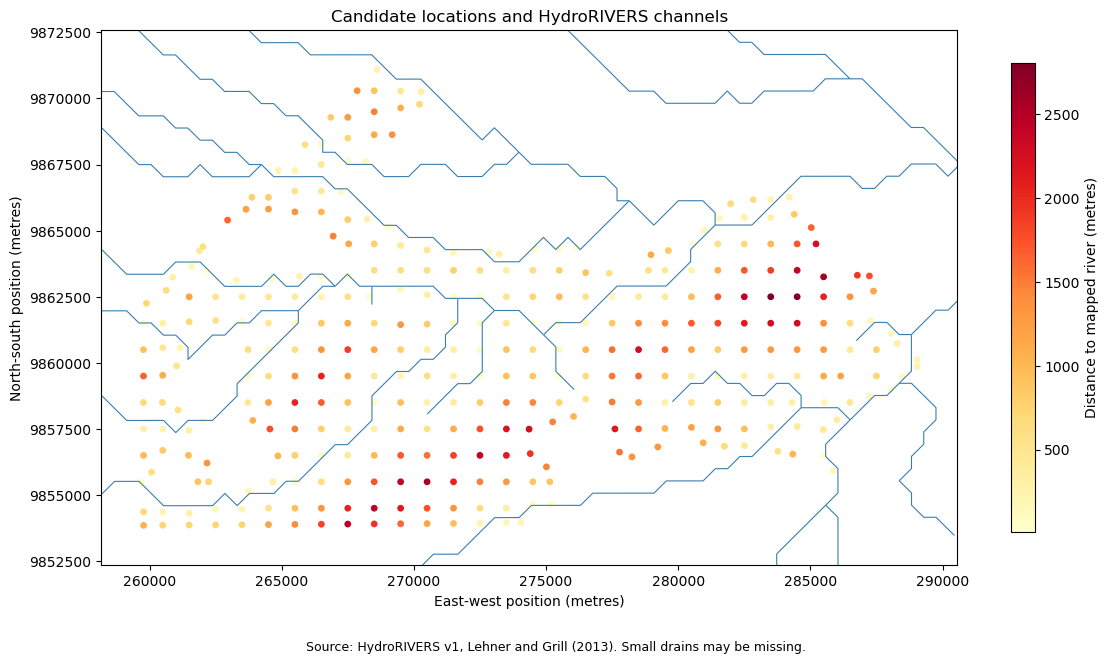

In [4]:
import matplotlib.pyplot as plt

map_points = river_points[["location_id", "geometry"]].merge(river_features, on="location_id", validate="one_to_one")
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
nearby_rivers.plot(ax=ax, color="#397eaf", linewidth=0.8)
map_points.plot(ax=ax, column="point_distance_to_mapped_river_m", cmap="YlOrRd", markersize=15,
                legend=True, legend_kwds={"label": "Distance to mapped river (metres)", "shrink": 0.7})
xmin, ymin, xmax, ymax = river_points.total_bounds
ax.set_xlim(xmin - 1500, xmax + 1500)
ax.set_ylim(ymin - 1500, ymax + 1500)
ax.set_title("Candidate locations and HydroRIVERS channels")
ax.set_xlabel("East-west position (metres)")
ax.set_ylabel("North-south position (metres)")
ax.ticklabel_format(style="plain", useOffset=False)
fig.supxlabel("Source: HydroRIVERS v1, Lehner and Grill (2013). Small drains may be missing.", fontsize=9)
fig.savefig(FIGURES_DIR / "candidate_river_distance_review.png", dpi=160, bbox_inches="tight")
plt.show()

## 32. Record other flood evidence without guessing locations
I found earlier reports of Nairobi flooding. I record the date reported for the event separately from the report's publication date. I do not guess coordinates from a place name or assign a county-wide report to every grid cell.

The 2010 IFRC report names Gando and Uthiru on 1 March. I keep “Gando” exactly as written because its location needs checking. The ACT Alliance report describes flooding in Nairobi on the night of 2 March 2018, but it does not provide affected polygons. These are leads for finding more precise records, not additional training rows.

I also record the Nairobi/Kiambu satellite product separately. It uses the same 1 May 2024 image and event as the existing source, so it does not create an independent test event.

Sources: [IFRC 2010 appeal, page 2](https://www.ifrc.org/docs/appeals/10/MDRKE012EA.pdf), [ACT Alliance 2018 response](https://actalliance.org/appeals-rapid-response-funds/kenya-emergency-response-to-floods-response-rrf-no-5/), [UNOSAT 3833](https://unosat.org/products/3833), [UNOSAT 3834](https://unosat.org/products/3834).

In [5]:
evidence_register = pd.DataFrame([
    {"evidence_id": "ifrc_2010_03_01", "event_group": "FL-2010-000047-KEN",
     "reported_event_date": "2010-03-01", "published_on": "2010-06-11",
     "reported_location": "Gando and Uthiru, Nairobi (source wording)",
     "source_url": "https://www.ifrc.org/docs/appeals/10/MDRKE012EA.pdf",
     "spatial_detail": "Named places, no affected boundary", "source_page": "2",
     "next_action": "Resolve source place names and obtain affected boundaries or verified points"},
    {"evidence_id": "act_2018_03_02", "event_group": "nairobi_2018_march_reported",
     "reported_event_date": "2018-03-02", "published_on": None,
     "reported_location": "Nairobi County; night of 2 March",
     "source_url": "https://actalliance.org/appeals-rapid-response-funds/kenya-emergency-response-to-floods-response-rrf-no-5/",
     "spatial_detail": "County-wide narrative, no affected boundary", "source_page": None,
     "next_action": "Find named affected places, boundaries, and the overnight event interval"},
    {"evidence_id": "unosat_3833", "event_group": "FL20240426KEN",
     "reported_event_date": "2024-05-01", "published_on": "2024-05-03",
     "reported_location": "Nairobi and Kiambu",
     "source_url": "https://unosat.org/products/3833",
     "spatial_detail": "Satellite map from the same image/event as 3834", "source_page": None,
     "next_action": "Check geographic coverage; keep in the same event group as 3834"},
    {"evidence_id": "unosat_3834", "event_group": "FL20240426KEN",
     "reported_event_date": "2024-05-01", "published_on": "2024-05-06",
     "reported_location": "Nairobi",
     "source_url": "https://unosat.org/products/3834",
     "spatial_detail": "Existing preliminary satellite observation", "source_page": None,
     "next_action": "Review water classes, coverage and label rule"},
])
evidence_register["usable_for_current_grid_labels"] = False
evidence_register["review_status"] = "Evidence lead only; not a reviewed training label"
evidence_register.to_csv(EVIDENCE_DIR / "flood_evidence_register.csv", index=False)
print("Evidence sources recorded:", len(evidence_register))
print("Additional independent events with usable grid labels: 0")
display(evidence_register[["evidence_id", "reported_event_date", "reported_location", "next_action"]])

Evidence sources recorded: 4
Additional independent events with usable grid labels: 0


,evidence_id,reported_event_date,reported_location,next_action
0,ifrc_2010_03_01,2010-03-01,"Gando and Uthiru, Nairobi (source wording)",Resolve source place names and obtain affected...
1,act_2018_03_02,2018-03-02,Nairobi County; night of 2 March,"Find named affected places, boundaries, and th..."
2,unosat_3833,2024-05-01,Nairobi and Kiambu,Check geographic coverage; keep in the same ev...
3,unosat_3834,2024-05-01,Nairobi,"Review water classes, coverage and label rule"


## 33. Prepare the label review and check sensitivity
Some candidate areas are only small pieces of a one-kilometre square. I record how much of the full square was available for review. A high water percentage in a tiny piece should not automatically describe the full square.

I compare several possible water thresholds for areas with at least 80% coverage. These thresholds are examples for review, not validated definitions of flooding. The counts show how much the choice could change the dataset. Areas without mapped water remain unlabelled because the satellite may miss flooding and one image does not cover the whole day.

I save a review table with an empty flood label and fields for a reason and reviewer. Existing review work is kept when this cell is rerun. I need trustworthy labels for both flooding and non-flooding, plus independent events, before starting the model comparison.

In [6]:
label_review = prepared_with_rivers[["location_id", "date", "observation_id", "event_id",
                                     "review_area_m2", "mapped_water_fraction", "source_url"]].copy()
label_review["reviewed_fraction_of_full_square"] = label_review.review_area_m2 / 1_000_000
if not label_review.reviewed_fraction_of_full_square.between(0, 1 + 1e-10).all():
    raise ValueError("Review area exceeds the one-kilometre square.")
label_review["mapped_water_area_m2"] = label_review.review_area_m2 * label_review.mapped_water_fraction
label_review["coverage_review_needed"] = label_review.reviewed_fraction_of_full_square.lt(0.8)
label_review["map_evidence"] = np.where(label_review.mapped_water_fraction.gt(0),
                                        "Some mapped water", "No water mapped in this image")
label_review["flood_label"] = pd.Series(pd.NA, index=label_review.index, dtype="Int64")
label_review["review_reason"] = ""
label_review["reviewer"] = ""
review_path = EVIDENCE_DIR / "label_review.csv"
if review_path.exists():
    previous_review = pd.read_csv(review_path, parse_dates=["date"])
    review_keys = ["location_id", "date", "observation_id"]
    saved_columns = ["flood_label", "review_reason", "reviewer"]
    label_review = label_review.drop(columns=saved_columns).merge(
        previous_review[review_keys + saved_columns], on=review_keys, how="left", validate="one_to_one")
label_review.to_csv(review_path, index=False)
eligible = label_review.reviewed_fraction_of_full_square.ge(0.8)
sensitivity_rows = []
for threshold in (0.01, 0.05, 0.10, 0.25):
    sensitivity_rows.append({
        "minimum_reviewed_fraction": 0.8, "example_water_fraction_threshold": threshold,
        "areas_above_water_threshold": int((eligible & label_review.mapped_water_fraction.ge(threshold)).sum()),
        "areas_below_water_threshold_not_confirmed_negative": int((eligible & label_review.mapped_water_fraction.lt(threshold)).sum()),
        "areas_with_limited_coverage": int((~eligible).sum()),
    })
label_sensitivity = pd.DataFrame(sensitivity_rows)
label_sensitivity.to_csv(EVIDENCE_DIR / "label_threshold_sensitivity.csv", index=False)
readiness = json.loads((PROCESSED_DIR / "candidate_input_readiness.json").read_text())
readiness["model_input_columns"] = list(dict.fromkeys(
    readiness["model_input_columns"] + ["point_distance_to_mapped_river_m"]))
readiness["pending"] = ["Review labels and observation timing", "Obtain independent events with usable locations", "Verify non-flood examples"]
readiness["river_feature_complete"] = True
readiness["ready_for_training"] = False
readiness["dataset"] = "candidate_inputs_with_rivers_pending_labels.csv"
readiness["missing_predictor_values"] = int(prepared_with_rivers[readiness["model_input_columns"]].isna().sum().sum())
(PROCESSED_DIR / "candidate_input_readiness_with_rivers.json").write_text(json.dumps(readiness, indent=2))
print("Input rows:", len(prepared_with_rivers))
print("Missing predictor values:", readiness["missing_predictor_values"])
print("Areas needing coverage review:", int((~eligible).sum()))
display(label_sensitivity)
print("Training remains pending: labels and independent events are not yet ready.")

Input rows: 344
Missing predictor values: 0
Areas needing coverage review: 121


,minimum_reviewed_fraction,example_water_fraction_threshold,areas_above_water_threshold,areas_below_water_threshold_not_confirmed_negative,areas_with_limited_coverage
0,0.8,0.01,112,111,121
1,0.8,0.05,73,150,121
2,0.8,0.10,46,177,121
3,0.8,0.25,26,197,121


Training remains pending: labels and independent events are not yet ready.


## 34. Check whether satellite archives can supply flood evidence
I am checking the AI for Good flood archive before deciding whether to use it for labels. Its dated table contains model detections. An absent detection does not tell me whether a location was observed and dry.

I also check original Sentinel-1 image availability. Image footprints show where an image was taken, not whether every pixel can be used to detect water. I can start this section after restarting the notebook.

Sources: [AI for Good dataset and field descriptions](https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset), [research paper](https://www.nature.com/articles/s41467-025-60973-1), and [Sentinel-1 RTC catalogue](https://planetarycomputer.microsoft.com/dataset/sentinel-1-rtc).

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib
import numpy as np
import pandas as pd
import geopandas as gpd
import pyarrow.parquet as pq
import rasterio
import requests
from retry_requests import retry
from IPython.display import display

PROJECT_DIR = Path.cwd()
SATELLITE_RAW_DIR = PROJECT_DIR / "data/raw/satellite_archive"
SATELLITE_DIR = PROJECT_DIR / "data/processed/satellite_audit"
GEOGRAPHY_DIR = PROJECT_DIR / "data/processed/geography"
for folder in (SATELLITE_RAW_DIR, SATELLITE_DIR):
    folder.mkdir(parents=True, exist_ok=True)
county = gpd.read_file(GEOGRAPHY_DIR / "nairobi_county.geojson").to_crs("EPSG:4326")
cells = gpd.read_file(GEOGRAPHY_DIR / "candidate_cells_1000m.geojson").to_crs("EPSG:4326")
points = gpd.read_file(GEOGRAPHY_DIR / "candidate_points_1000m.geojson").to_crs("EPSG:4326")
archive_session = retry(requests.Session(), retries=3, backoff_factor=1)
manifest_path = SATELLITE_RAW_DIR / "download_manifest.json"
repository = "ai-for-good-lab/ai4g-flood-dataset"
if manifest_path.exists():
    download_manifest = json.loads(manifest_path.read_text())
    revision = download_manifest["revision"]
else:
    response = archive_session.get(f"https://huggingface.co/api/datasets/{repository}", timeout=60)
    response.raise_for_status()
    revision = response.json()["sha"]
    download_manifest = {"repository": repository, "revision": revision, "files": []}
# This three-degree tile covers the current Nairobi study area.
if not ((county.total_bounds >= [36, -3, 36, -3]).all() and
        (county.total_bounds <= [39, 0, 39, 0]).all()):
    raise ValueError("The study boundary needs a different satellite tile.")
file_records = []
for filename in ["S03E036-post-processing.parquet", "S03E036-80m-buffer.tif"]:
    destination = SATELLITE_RAW_DIR / filename
    url = f"https://huggingface.co/datasets/{repository}/resolve/{revision}/S03/S03E036/{filename}"
    if not destination.exists():
        temporary = destination.with_suffix(destination.suffix + ".part")
        with archive_session.get(url, stream=True, timeout=(20, 180)) as response:
            response.raise_for_status()
            with temporary.open("wb") as handle:
                for chunk in response.iter_content(1024 * 1024):
                    handle.write(chunk)
        temporary.replace(destination)
    digest = hashlib.sha256(destination.read_bytes()).hexdigest()
    previous = next((item for item in download_manifest["files"] if item["filename"] == filename), None)
    if previous and previous["sha256"] != digest:
        raise ValueError(f"The saved archive file has changed: {filename}")
    file_records.append({"filename": filename, "url": url, "bytes": destination.stat().st_size, "sha256": digest})
download_manifest["files"] = file_records
download_manifest["checked_at_utc"] = datetime.now(timezone.utc).isoformat()
manifest_path.write_text(json.dumps(download_manifest, indent=2))
print("Archive revision:", revision)

Archive revision: d594d7a72f9719abff2df375dd3734a912b80595


## 35. Count dated detections inside Nairobi and the study areas
I read the part of the table around Nairobi, then use the actual county boundary to remove outside points. I retain the source image name and time for each detection.

I match detection points to candidate areas without adding a buffer. This is a coverage check, not an estimate of flooded area. I count distinct dates and images separately. Several dates may belong to the same flood, and many detected pixels are not independent examples.

I keep spatial quality flags alongside the detections. I do not use rainfall, temperature or soil-moisture thresholds to create the answer that a weather model will later learn.

In [ ]:
parquet_path = SATELLITE_RAW_DIR / "S03E036-post-processing.parquet"
west, south, east, north = county.total_bounds
bbox_detections = pq.read_table(parquet_path, filters=[
    ("lon", ">=", west), ("lon", "<=", east), ("lat", ">=", south), ("lat", "<=", north)
]).to_pandas()
detections = gpd.GeoDataFrame(bbox_detections,
    geometry=gpd.points_from_xy(bbox_detections.lon, bbox_detections.lat), crs="EPSG:4326")
detections = detections.loc[detections.geometry.intersects(county.geometry.union_all())].copy()
detections = detections.drop_duplicates(["filename", "lat", "lon", "year", "month", "day"])
detections["archive_date"] = pd.to_datetime(detections[["year", "month", "day"]])
source_times = detections.filename.str.extract(r"_(\d{8}T\d{6})_", expand=False)
detections["observed_at_utc"] = pd.to_datetime(source_times, format="%Y%m%dT%H%M%S", utc=True, errors="coerce")
if detections.observed_at_utc.isna().any():
    raise ValueError("Some image names do not contain a readable observation time.")
if not detections.observed_at_utc.dt.tz_localize(None).dt.normalize().eq(detections.archive_date).all():
    raise ValueError("The image date and archive date do not agree.")
detections["observation_date_local"] = detections.observed_at_utc.dt.tz_convert("Africa/Nairobi").dt.tz_localize(None).dt.normalize()
detections["built_up_flag"] = detections.land_cover.eq(50)
detections["spatial_review_flag"] = (
    detections.land_cover.isin([50, 60, 80]) | detections.land_cover.isna() |
    detections.edge_false_positives.ne(0) | detections.dem_metric_2.ge(10) | detections.dem_metric_2.isna())
detections.drop(columns="geometry").to_parquet(SATELLITE_DIR / "nairobi_detections.parquet", index=False)
matched = gpd.sjoin(detections, cells[["location_id", "geometry"]], how="inner", predicate="within")
matched.drop(columns=["geometry", "index_right"]).to_parquet(SATELLITE_DIR / "candidate_detections.parquet", index=False)
yearly = detections.groupby("year").agg(
    detection_points=("filename", "size"), distinct_images=("filename", "nunique"),
    detection_dates=("observation_date_local", "nunique"), spatial_flags=("spatial_review_flag", "sum"))
yearly.to_csv(SATELLITE_DIR / "county_detection_years.csv")
candidate_dates = matched.groupby(["location_id", "observation_date_local"]).agg(
    detection_points=("filename", "size"), distinct_images=("filename", "nunique"),
    spatial_flags=("spatial_review_flag", "sum")).reset_index()
candidate_dates.to_csv(SATELLITE_DIR / "candidate_detection_dates.csv", index=False)
print("County detection points:", len(detections))
print("County detection dates:", detections.observation_date_local.nunique())
print("Candidate areas containing detections:", matched.location_id.nunique())
print("Candidate detection dates:", matched.observation_date_local.nunique())
display(yearly)

County detection points: 53639
County detection dates: 306
Candidate areas containing detections: 209
Candidate detection dates: 213


,detection_points,distinct_images,detection_dates,spatial_flags
year,,,,
2014,2827,7,7,2413
2015,5144,36,34,4918
2016,1553,32,32,898
2017,18503,60,60,17512
2018,20901,77,77,20003
2019,4199,62,62,3004
2020,36,8,8,14
2021,308,18,18,62
2022,118,4,4,116


## 36. Check the archive's reliability map at our points
The archive map uses 1 for excluded areas, 2 for buffered flood detections, and 0 for no detections outside the exclusion mask. I sample it at the representative points. These values describe an accumulated map, not flooding on a particular date.

A value of 0 is not a daily non-flood label. A value of 2 is not independent validation of the dated table. I keep all areas for review, including those flagged as unreliable.

This file also declares zero as its missing-data value. I record that ambiguity and check whether points fall inside the map separately. I do not interpret zero as a confirmed dry observation.

In [ ]:
with rasterio.open(SATELLITE_RAW_DIR / "S03E036-80m-buffer.tif") as source:
    map_points = points.to_crs(source.crs)
    sample_rows, sample_cols = rasterio.transform.rowcol(
        source.transform, map_points.geometry.x, map_points.geometry.y)
    if any(row < 0 or row >= source.height or col < 0 or col >= source.width
           for row, col in zip(sample_rows, sample_cols)):
        raise ValueError("A candidate point is outside the reliability map.")
    # Zero is both a documented map class and the file's nodata value.
    raster_nodata_value = source.nodata
    mask_values = np.array([sample[0] for sample in source.sample(
        zip(map_points.geometry.x, map_points.geometry.y), masked=False)], dtype=int)
if not np.isin(mask_values, [0, 1, 2]).all():
    raise ValueError("Unexpected archive map values.")
point_audit = points[["location_id"]].copy()
point_audit["archive_map_value"] = mask_values
point_audit["archive_map_meaning"] = point_audit.archive_map_value.map({
    0: "Zero / no detection or nodata; not a dry-day label",
    1: "Excluded or unreliable area", 2: "Buffered detection in accumulated map"})
point_counts = candidate_dates.groupby("location_id").size().rename("dates_with_detections")
point_audit = point_audit.merge(point_counts, on="location_id", how="left", validate="one_to_one")
point_audit["dates_with_detections"] = point_audit.dates_with_detections.fillna(0).astype(int)
point_audit.to_csv(SATELLITE_DIR / "candidate_archive_coverage.csv", index=False)
print("Candidate point map values:")
display(point_audit.archive_map_meaning.value_counts())

Candidate point map values:


archive_map_meaning
Zero / no detection or nodata; not a dry-day label    177
Excluded or unreliable area                           157
Buffered detection in accumulated map                  10
Name: count, dtype: int64

## 37. Check original image availability and choose the next experiment
I check the public Sentinel-1 RTC catalogue for January 2023 to September 2024. This is a limited pilot period, not a search of the entire archive. I save the full search result and its settings. Image footprints only establish potential coverage; pixel quality and flood detection still need checking.

The next experiment is to examine a few suitable images around the April–May 2024 flood alongside the existing UNOSAT observation. I must account for the time difference between images. I will also need usable non-flood observations and more events before calling this a forecasting dataset.

In [ ]:
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
scene_params = {"collections": "sentinel-1-rtc", "bbox": "36.65,-1.45,37.15,-1.1",
                "datetime": "2023-01-01T00:00:00Z/2024-09-30T23:59:59Z", "limit": 1000}
scene_path = SATELLITE_RAW_DIR / "sentinel1_scene_search.json"
if not scene_path.exists():
    response = archive_session.get(STAC_URL, params=scene_params, timeout=90)
    response.raise_for_status()
    scene_path.write_text(json.dumps(response.json()))
scene_response = json.loads(scene_path.read_text())
if any(link.get("rel") == "next" for link in scene_response.get("links", [])):
    raise ValueError("The scene search has more pages; collect them before counting coverage.")
scenes = gpd.GeoDataFrame.from_features(scene_response["features"], crs="EPSG:4326")
scenes["scene_id"] = [item["id"] for item in scene_response["features"]]
scenes = scenes.loc[scenes.geometry.intersects(county.geometry.union_all())].copy()
scenes["observed_at_utc"] = pd.to_datetime(scenes.datetime, utc=True)
scenes["observation_date_local"] = scenes.observed_at_utc.dt.tz_convert("Africa/Nairobi").dt.tz_localize(None).dt.normalize()
scene_table = scenes[["scene_id", "observed_at_utc", "observation_date_local"]].copy()
scene_table.to_csv(SATELLITE_DIR / "sentinel1_available_scenes.csv", index=False)
scene_matches = gpd.sjoin(points[["location_id", "geometry"]],
                         scenes[["scene_id", "observation_date_local", "geometry"]],
                         how="inner", predicate="within")
scene_matches.drop(columns=["geometry", "index_right"]).to_csv(SATELLITE_DIR / "candidate_scene_footprints.csv", index=False)
pilot_scenes = scene_table.loc[scene_table.observation_date_local.between("2024-04-15", "2024-05-15")].copy()
pilot_scenes["days_from_unosat_image"] = (pilot_scenes.observation_date_local - pd.Timestamp("2024-05-01")).dt.days
pilot_scenes.to_csv(SATELLITE_DIR / "2024_flood_scene_shortlist.csv", index=False)
summary = {
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "archive_revision": revision, "county_detection_points": len(detections),
    "county_detection_dates": int(detections.observation_date_local.nunique()),
    "candidate_areas_with_detections": int(matched.location_id.nunique()),
    "candidate_detection_dates": int(matched.observation_date_local.nunique()),
    "raster_nodata_value": raster_nodata_value,
    "candidate_points_zero_or_nodata": int((mask_values == 0).sum()),
    "candidate_points_excluded_by_map": int((mask_values == 1).sum()),
    "catalogue_scene_count_in_county": len(scenes),
    "catalogue_distinct_dates_in_county": int(scenes.observation_date_local.nunique()),
    "catalogue_search": {"url": STAC_URL, "parameters": scene_params},
    "confirmed_independent_events": None, "confirmed_negative_labels": 0,
    "ready_for_training": False,
    "next_step": "Inspect original scenes near the 2024 flood and establish usable observed non-flood examples",
}
(SATELLITE_DIR / "coverage_summary.json").write_text(json.dumps(summary, indent=2))
print("Original scenes intersecting Nairobi:", len(scenes))
print("Distinct image dates:", scenes.observation_date_local.nunique())
print("Candidate locations within at least one image footprint:", scene_matches.location_id.nunique())
display(pilot_scenes.sort_values("observed_at_utc"))
print("The archive supplies leads for dated detections, but not confirmed dry-day labels.")

Original scenes intersecting Nairobi: 93
Distinct image dates: 93
Candidate locations within at least one image footprint: 344
The archive supplies leads for dated detections, but not confirmed dry-day labels.


,scene_id,observed_at_utc,observation_date_local,days_from_unosat_image
25,S1A_IW_GRDH_1SDV_20240419T154818_20240419T1548...,2024-04-19 15:48:30.635250+00:00,2024-04-19,-12
24,S1A_IW_GRDH_1SDV_20240501T154818_20240501T1548...,2024-05-01 15:48:30.932886+00:00,2024-05-01,0
23,S1A_IW_GRDH_1SDV_20240506T155630_20240506T1556...,2024-05-06 15:56:42.768853+00:00,2024-05-06,5
22,S1A_IW_GRDH_1SDV_20240513T154818_20240513T1548...,2024-05-13 15:48:30.588427+00:00,2024-05-13,12


## 38. Check the same-day image against the existing flood evidence
I found a Sentinel-1 image from the same calendar day as the UNOSAT observation. I check its time and the areas where the archive contains detections. I keep the time gap visible because flood water can change between the two images.

I compare whether each candidate area has any detection with whether its UNOSAT water fraction is above zero. This is a coarse check of two sources, not a score for forecast accuracy. No archive detection stays unknown; I do not turn it into a non-flood label. The source maps may also have different errors.

I save earlier images from the same satellite orbit for a possible image comparison. An earlier image is not automatically a dry baseline; that still needs checking.

In [ ]:
target_date = pd.Timestamp("2024-05-01")
observations = pd.read_csv(GEOGRAPHY_DIR / "candidate_flood_observations.csv", parse_dates=["date"])
reference_times = pd.to_datetime(observations.observed_at, utc=True).unique()
if len(reference_times) != 1:
    raise ValueError("Choose one reference image before comparing times.")
reference_time = pd.Timestamp(reference_times[0])
same_day = scenes.loc[scenes.observation_date_local.eq(target_date)].copy()
if len(same_day) != 1:
    raise ValueError("Review the available same-day scenes before selecting an image.")
selected = same_day.iloc[0]
scene_key = selected.scene_id.removesuffix("_rtc")
image_detections = matched.loc[matched.filename.str.replace(r"(-20m|_rtc)$", "", regex=True).eq(scene_key)].copy()
detection_counts = image_detections.groupby("location_id").size().rename("archive_detection_points")
comparison = observations[["location_id", "date", "review_area_m2", "mapped_water_fraction"]].merge(
    detection_counts, on="location_id", how="left", validate="one_to_one")
comparison["archive_detection_points"] = comparison.archive_detection_points.fillna(0).astype(int)
comparison["archive_has_detection"] = comparison.archive_detection_points.gt(0)
comparison["unosat_has_mapped_water"] = comparison.mapped_water_fraction.gt(0)
comparison["reviewed_fraction_of_square"] = comparison.review_area_m2 / 1_000_000
comparison = comparison.merge(point_audit[["location_id", "archive_map_value"]], on="location_id", validate="one_to_one")
comparison["reference_time_utc"] = reference_time
comparison["satellite_time_utc"] = selected.observed_at_utc
comparison["time_gap_hours"] = (selected.observed_at_utc - reference_time).total_seconds() / 3600
comparison["interpretation"] = np.where(comparison.archive_has_detection,
    "Model detection to review", "No model detection; flood state unknown")
comparison.to_csv(SATELLITE_DIR / "same_day_source_comparison.csv", index=False)
comparison_counts = comparison.groupby(["unosat_has_mapped_water", "archive_has_detection"]).size().rename("candidate_areas").reset_index()
comparison_counts.to_csv(SATELLITE_DIR / "same_day_source_counts.csv", index=False)
previous_scenes = scenes.loc[
    scenes["sat:relative_orbit"].eq(selected["sat:relative_orbit"]) &
    scenes["sat:orbit_state"].eq(selected["sat:orbit_state"]) &
    scenes["platform"].eq(selected["platform"]) &
    scenes.observed_at_utc.lt(selected.observed_at_utc) &
    scenes.observed_at_utc.ge(selected.observed_at_utc - pd.Timedelta(days=90))
].sort_values("observed_at_utc")
previous_scenes[["scene_id", "observed_at_utc", "sat:relative_orbit", "sat:orbit_state"]].to_csv(
    SATELLITE_DIR / "earlier_same_orbit_images_to_review.csv", index=False)
summary["same_day_pilot"] = {
    "scene_id": selected.scene_id,
    "reference_time_utc": reference_time.isoformat(),
    "satellite_time_utc": selected.observed_at_utc.isoformat(),
    "time_gap_hours": float(comparison.time_gap_hours.iloc[0]),
    "areas_with_archive_detections": int(comparison.archive_has_detection.sum()),
    "areas_with_unosat_mapped_water": int(comparison.unosat_has_mapped_water.sum()),
    "areas_with_both": int((comparison.archive_has_detection & comparison.unosat_has_mapped_water).sum()),
    "interpretation": "Source comparison only; absence of detections is not a non-flood label",
}
(SATELLITE_DIR / "coverage_summary.json").write_text(json.dumps(summary, indent=2))
print("Image time gap (hours):", round(comparison.time_gap_hours.iloc[0], 2))
display(comparison_counts)
print("Earlier same-orbit images available for review:", len(previous_scenes))
print("No flood labels were created from absent archive detections.")

Image time gap (hours): 7.71
Earlier same-orbit images available for review: 6
No flood labels were created from absent archive detections.


,unosat_has_mapped_water,archive_has_detection,candidate_areas
0,False,False,156
1,True,False,178
2,True,True,10


## 39. Choose a small radar-image experiment
I test a five-kilometre square in the existing study area. I chose this square from the earlier map to include mapped water and surrounding land. It is a diagnostic example, not a representative test of Nairobi.

I compare the image from 1 May 2024 with images from 19 February, 2 March and 14 March, using the same satellite orbit and radar channel (VH). The earlier images are reference images, not confirmed dry observations. I download only the small crops and retain their source details.

Source: [Microsoft Sentinel-1 RTC example](https://github.com/microsoft/PlanetaryComputerExamples/blob/main/datasets/sentinel-1-rtc/sentinel-1-rtc-example.ipynb).

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import rasterio
import certifi
from rasterio.windows import from_bounds
from rasterio.transform import from_origin
from rasterio.features import geometry_mask
from scipy.ndimage import uniform_filter
from retry_requests import retry
from IPython.display import display

PROJECT_DIR = Path.cwd()
PILOT_RAW_DIR = PROJECT_DIR / "data/raw/radar_pilot"
PILOT_DIR = PROJECT_DIR / "data/processed/radar_pilot"
GEOGRAPHY_DIR = PROJECT_DIR / "data/processed/geography"
FIGURES_DIR = PROJECT_DIR / "data/figures"
for folder in (PILOT_RAW_DIR, PILOT_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)
PILOT_CRS = "EPSG:32737"
PILOT_BOUNDS = (278000, 9860000, 283000, 9865000)
PIXEL_SIZE_M = 10
pilot_transform = from_origin(PILOT_BOUNDS[0], PILOT_BOUNDS[3], PIXEL_SIZE_M, PIXEL_SIZE_M)
pilot_shape = (500, 500)
BASELINE_DATES = ["2024-02-19", "2024-03-02", "2024-03-14"]
EVENT_DATE = "2024-05-01"
CHANNEL = "vh"
catalogue = json.loads((PROJECT_DIR / "data/raw/satellite_archive/sentinel1_scene_search.json").read_text())
selected_scenes = []
for date in BASELINE_DATES + [EVENT_DATE]:
    matches = [item for item in catalogue["features"]
               if item["properties"]["datetime"].startswith(date)
               and item["properties"]["sat:relative_orbit"] == 57
               and item["properties"]["sat:orbit_state"] == "ascending"
               and item["properties"]["platform"] == "SENTINEL-1A"]
    if len(matches) != 1:
        raise ValueError(f"Expected one matching image for {date}.")
    selected_scenes.append(matches[0])
radar_session = retry(requests.Session(), retries=3, backoff_factor=1)
radar_arrays = []
radar_records = []
for item in selected_scenes:
    date = item["properties"]["datetime"][:10]
    href = item["assets"][CHANNEL]["href"]
    crop_settings = {"scene_id": item["id"], "channel": CHANNEL,
                     "bounds": PILOT_BOUNDS, "crs": PILOT_CRS, "pixel_size_m": PIXEL_SIZE_M}
    crop_id = hashlib.sha256(json.dumps(crop_settings, sort_keys=True).encode()).hexdigest()[:12]
    path = PILOT_RAW_DIR / f"{date}_{CHANNEL}_{crop_id}.tif"
    if not path.exists():
        response = radar_session.get("https://planetarycomputer.microsoft.com/api/sas/v1/sign",
                                     params={"href": href}, timeout=60)
        if not response.ok:
            raise RuntimeError("The imagery service did not grant access. Check access requirements.")
        signed_href = response.json()["href"]
        # Keep temporary access tokens out of saved metadata and error messages.
        try:
            with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
                              CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tiff", CURL_CA_BUNDLE=certifi.where()):
                with rasterio.open(signed_href) as source:
                    if source.crs != PILOT_CRS:
                        raise ValueError("Unexpected image coordinate system.")
                    window = from_bounds(*PILOT_BOUNDS, source.transform).round_offsets().round_lengths()
                    if not source.window_transform(window).almost_equals(pilot_transform):
                        raise ValueError("The image does not match the common grid.")
                    array = source.read(1, window=window, masked=True).filled(np.nan).astype("float32")
        except Exception:
            raise RuntimeError("The image crop could not be read or aligned. Check the connection and source grid.") from None
        finally:
            del signed_href
        if array.shape != pilot_shape:
            raise ValueError("The image does not cover the full pilot square.")
        temporary = path.with_suffix(".tmp.tif")
        with rasterio.open(temporary, "w", driver="GTiff", height=500, width=500, count=1,
                           dtype="float32", crs=PILOT_CRS, transform=pilot_transform,
                           nodata=np.nan, compress="deflate") as output:
            output.write(array, 1)
        temporary.replace(path)
    with rasterio.open(path) as source:
        if source.crs != PILOT_CRS or source.shape != pilot_shape or not source.transform.almost_equals(pilot_transform):
            raise ValueError("A saved crop does not match the pilot settings.")
        array = source.read(1, masked=True).filled(np.nan)
    radar_arrays.append(array)
    radar_records.append({**crop_settings, "datetime_utc": item["properties"]["datetime"],
                          "original_asset_url": href, "crop_file": path.name,
                          "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
                          "valid_pixels": int((np.isfinite(array) & (array > 0)).sum())})
    print("Radar crop ready:", date)
radar_manifest = {"created_at_utc": datetime.now(timezone.utc).isoformat(), "images": radar_records,
                  "selection": "Illustrative square chosen using existing map; not independent validation"}
(PILOT_RAW_DIR / "crop_manifest.json").write_text(json.dumps(radar_manifest, indent=2))

Radar crop ready: 2024-02-19
Radar crop ready: 2024-03-02
Radar crop ready: 2024-03-14
Radar crop ready: 2024-05-01


## 40. Flag a simple change in the radar signal
Water can appear dark in a radar image, but dark pixels can also have other causes. I first reduce small pixel fluctuations using a three-by-three average. I convert the signal to decibels and use the median of the three earlier images as a reference.

For this first example, I flag pixels below -20 dB on 1 May, at least 3 dB darker than the reference, and not already below -20 dB in the reference. These are illustrative thresholds, not calibrated flood rules. Buildings, vegetation and standing water need further checks.

I save the flags separately from the training data. A pixel not flagged by this rule is not confirmed dry.

In [ ]:
def smooth_radar_db(array):
    valid = np.isfinite(array) & (array > 0)
    weight = uniform_filter(valid.astype("float32"), size=3, mode="constant", cval=0)
    average = uniform_filter(np.where(valid, array, 0).astype("float32"), size=3, mode="constant", cval=0)
    result = np.full(array.shape, np.nan, dtype="float32")
    complete = (weight > 0.99999) & (average > 0)
    result[complete] = 10 * np.log10(average[complete] / weight[complete])
    return result

radar_db = np.stack([smooth_radar_db(array) for array in radar_arrays])
valid_radar = np.isfinite(radar_db).all(axis=0)
reference_db = np.median(radar_db[:3], axis=0)
event_db = radar_db[3]
change_db = event_db - reference_db
DARK_THRESHOLD_DB = -20
DROP_THRESHOLD_DB = -3
new_darkening = valid_radar & (event_db < DARK_THRESHOLD_DB) & (change_db <= DROP_THRESHOLD_DB) & (reference_db >= DARK_THRESHOLD_DB)
flag_raster = np.full(pilot_shape, 255, dtype="uint8")
flag_raster[valid_radar] = new_darkening[valid_radar].astype("uint8")
for filename, array, nodata in [
    ("reference_signal_db.tif", reference_db, np.nan),
    ("event_signal_db.tif", event_db, np.nan),
    ("signal_change_db.tif", change_db, np.nan),
    ("exploratory_darkening_flags.tif", flag_raster, 255),
]:
    destination = PILOT_DIR / filename
    temporary = destination.with_suffix(".tmp.tif")
    with rasterio.open(temporary, "w", driver="GTiff", height=500, width=500, count=1,
                       dtype=array.dtype, crs=PILOT_CRS, transform=pilot_transform,
                       nodata=nodata, compress="deflate") as output:
        output.write(array, 1)
    temporary.replace(destination)
print("Valid radar pixels:", int(valid_radar.sum()))
print("Pixels flagged for review:", int(new_darkening.sum()))
print("Flags are not training labels.")

Valid radar pixels: 248004
Pixels flagged for review: 1252
Flags are not training labels.


## 41. Compare with the UNOSAT map inside its review area
I compare the flags only where the saved UNOSAT review area and valid radar pixels overlap. I rasterise the reference polygons onto the same grid. I show several threshold combinations to see how sensitive the result is, without choosing the best-looking threshold.

The reference image was taken about 7 hours 42 minutes earlier. These are map-agreement checks within one chosen square, not measurements of future flood prediction accuracy. Unflagged pixels remain unknown for training purposes.

In [ ]:
from io import BytesIO

# Read the bytes first so cloud-backed files are available locally.
review_polygons = gpd.read_file(BytesIO((GEOGRAPHY_DIR / "review_area_20240501.geojson").read_bytes())).to_crs(PILOT_CRS)
water_polygons = gpd.read_file(BytesIO((GEOGRAPHY_DIR / "mapped_flood_water_20240501.geojson").read_bytes())).to_crs(PILOT_CRS)
review_mask = geometry_mask(review_polygons.geometry, out_shape=pilot_shape,
                            transform=pilot_transform, invert=True)
water_mask = geometry_mask(water_polygons.geometry, out_shape=pilot_shape,
                           transform=pilot_transform, invert=True)
comparison_mask = review_mask & valid_radar
if not comparison_mask.any() or not (water_mask & comparison_mask).any():
    raise ValueError("The pilot has no usable reference coverage or mapped water.")
comparison_rows = []
for dark in (-18, -20, -22):
    for drop in (-2, -3, -4):
        flags = comparison_mask & (event_db < dark) & (change_db <= drop) & (reference_db >= dark)
        overlap = flags & water_mask
        mapped = water_mask & comparison_mask
        comparison_rows.append({
            "dark_threshold_db": dark, "drop_threshold_db": drop,
            "reference_water_km2": float(mapped.sum() * 100 / 1e6),
            "flagged_km2": float(flags.sum() * 100 / 1e6),
            "overlap_km2": float(overlap.sum() * 100 / 1e6),
            "fraction_of_reference_water_flagged": float(overlap.sum() / mapped.sum()),
            "fraction_of_flags_on_reference_water": float(overlap.sum() / flags.sum()) if flags.any() else None,
        })
pilot_comparison = pd.DataFrame(comparison_rows)
pilot_comparison.to_csv(PILOT_DIR / "threshold_agreement_checks.csv", index=False)
radar_manifest["processing"] = {"smoothing": "3 by 3 mean in linear units, then 10 log10",
    "reference": "Median of three earlier images; not confirmed dry",
    "dark_threshold_db": DARK_THRESHOLD_DB, "drop_threshold_db": DROP_THRESHOLD_DB,
    "flag_codes": {"0": "Not flagged; not confirmed dry", "1": "New darkening to review", "255": "Invalid radar"},
    "reference_comparison_area_km2": float(comparison_mask.sum() * 100 / 1e6),
    "ready_for_training": False}
(PILOT_DIR / "processing_metadata.json").write_text(json.dumps(radar_manifest, indent=2))
display(pilot_comparison.round(3))

,dark_threshold_db,drop_threshold_db,reference_water_km2,flagged_km2,overlap_km2,fraction_of_reference_water_flagged,fraction_of_flags_on_reference_water
0,-18,-2,6.587,0.500,0.164,0.025,0.329
1,-18,-3,6.587,0.216,0.087,0.013,0.404
2,-18,-4,6.587,0.085,0.048,0.007,0.571
3,-20,-2,6.587,0.331,0.033,0.005,0.100
4,-20,-3,6.587,0.125,0.023,0.004,0.186
5,-20,-4,6.587,0.044,0.014,0.002,0.317
6,-22,-2,6.587,0.029,0.000,0.000,0.017
7,-22,-3,6.587,0.020,0.000,0.000,0.024
8,-22,-4,6.587,0.009,0.000,0.000,0.047


## 42. Look at the original signal and the flagged changes
I draw the earlier reference, the event image, the signal change and the review flags. Blue outlines show UNOSAT water. Purple flags are candidates for checking, not validated flood predictions.

Before expanding this approach, I need to judge whether the changes follow plausible water patterns, account for permanent water and unreliable urban pixels, and find independently observed non-flood examples.

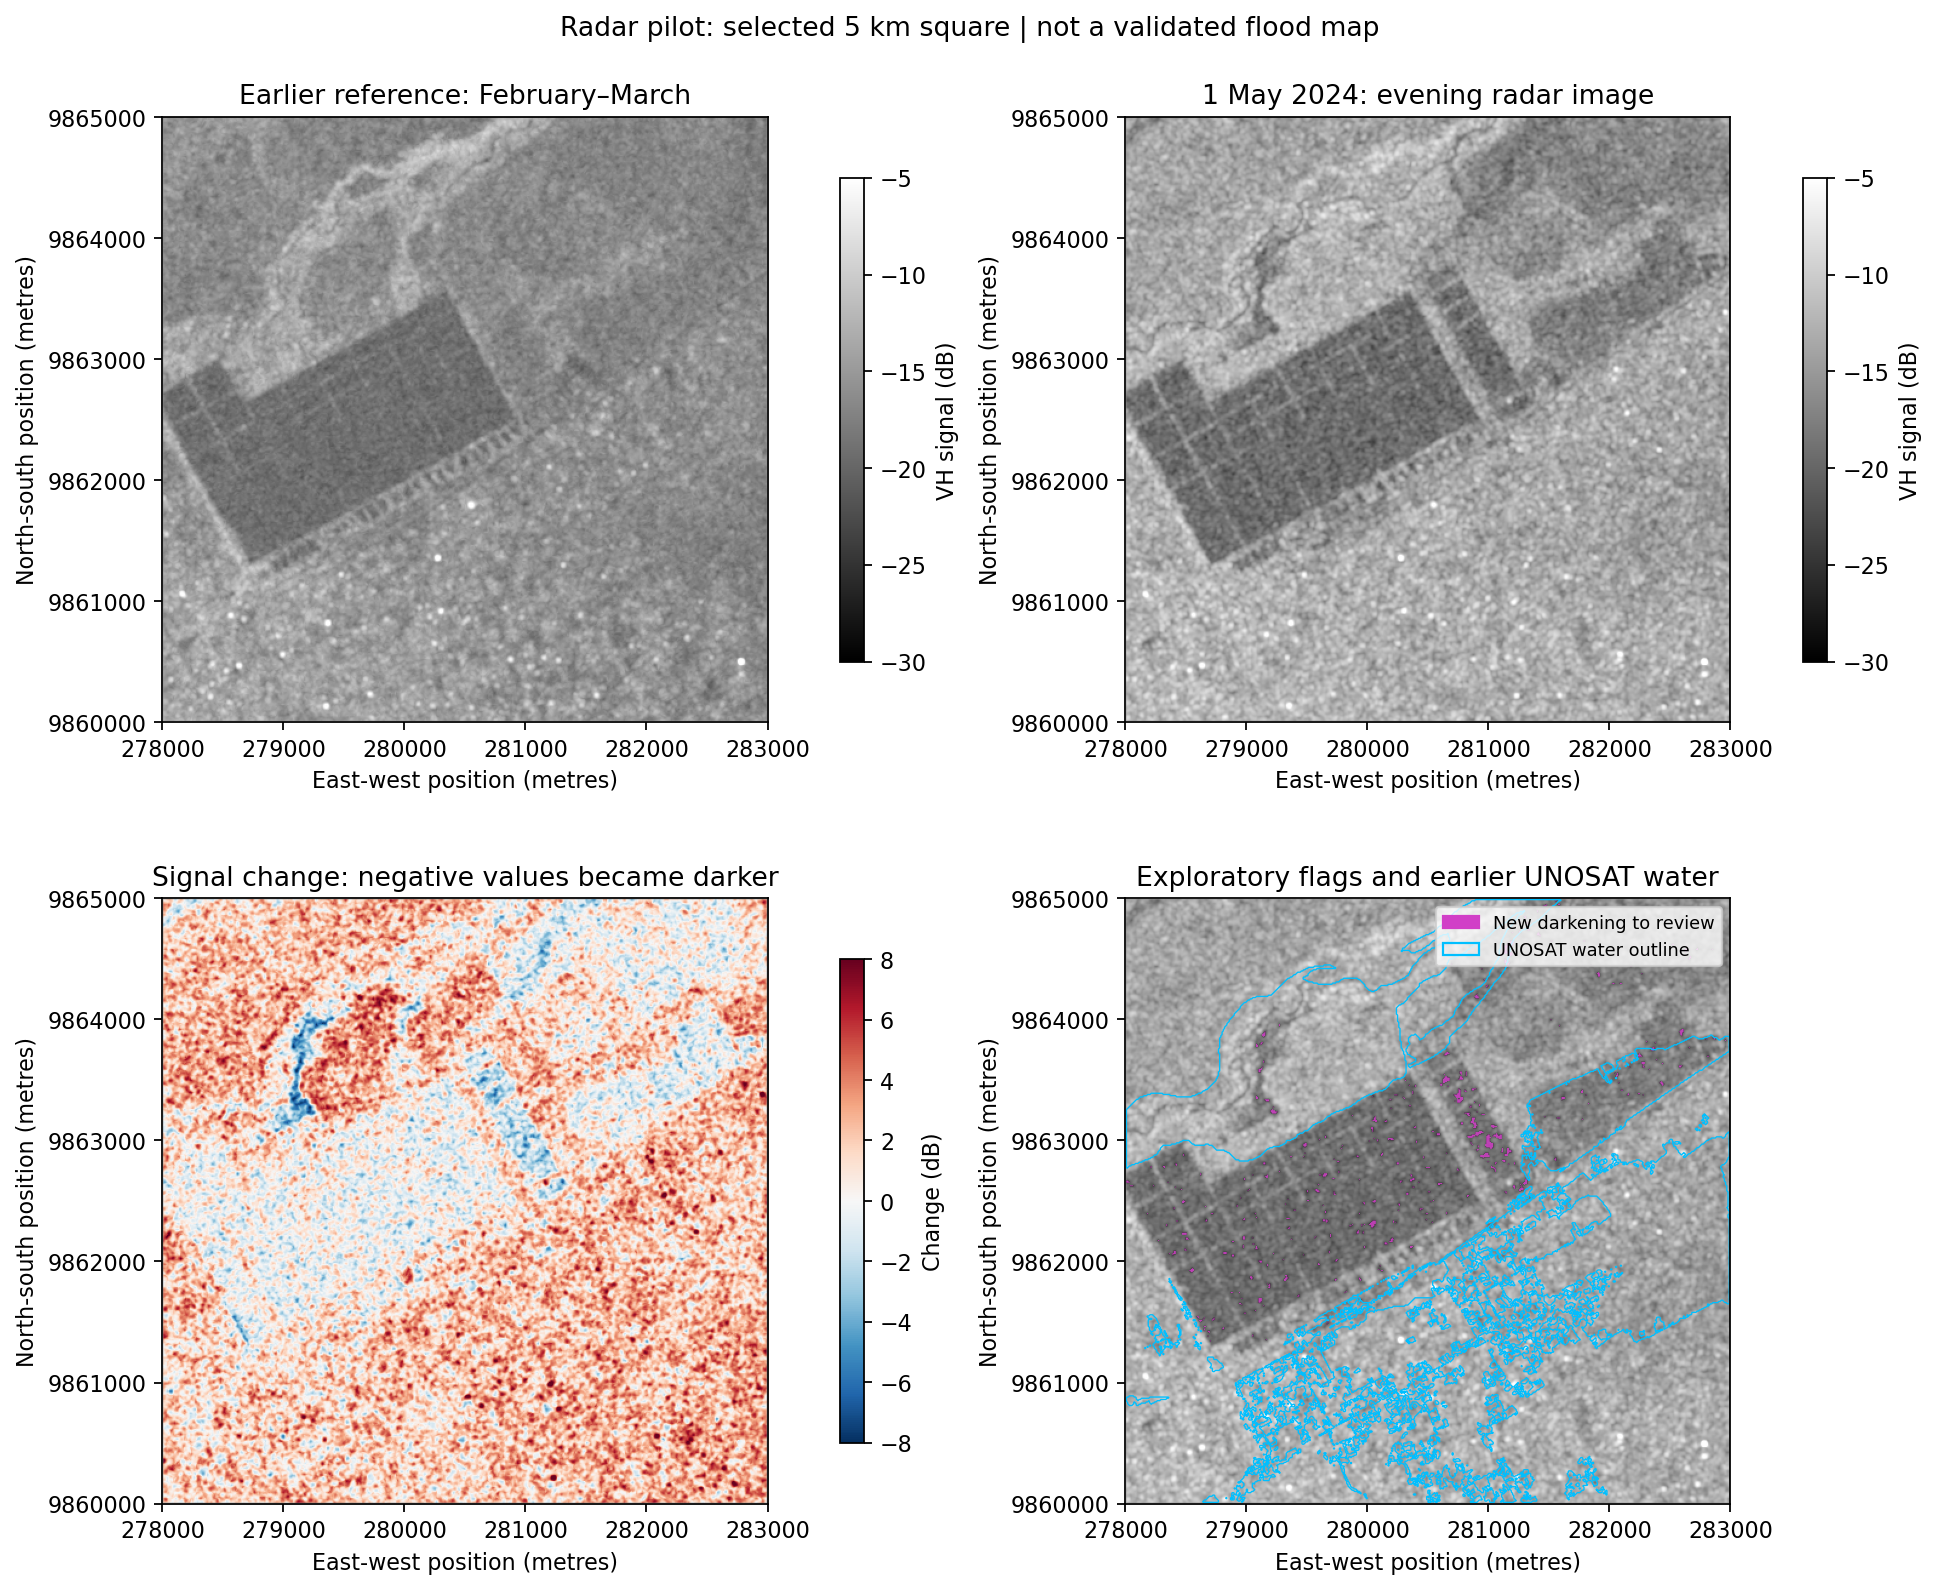

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

extent = [PILOT_BOUNDS[0], PILOT_BOUNDS[2], PILOT_BOUNDS[1], PILOT_BOUNDS[3]]
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, array, title in zip(axes.flat[:2], [reference_db, event_db],
                            ["Earlier reference: February–March", "1 May 2024: evening radar image"]):
    im = ax.imshow(array, extent=extent, origin="upper", cmap="gray", vmin=-30, vmax=-5)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.7, label="VH signal (dB)")
im = axes[1, 0].imshow(change_db, extent=extent, origin="upper", cmap="RdBu_r", vmin=-8, vmax=8)
axes[1, 0].set_title("Signal change: negative values became darker")
fig.colorbar(im, ax=axes[1, 0], shrink=0.7, label="Change (dB)")
axes[1, 1].imshow(event_db, extent=extent, origin="upper", cmap="gray", vmin=-30, vmax=-5)
axes[1, 1].imshow(np.ma.masked_where(~(new_darkening & comparison_mask), np.ones(pilot_shape)),
                  extent=extent, origin="upper", cmap=ListedColormap(["#d13fc7"]), alpha=0.85)
# Contours follow the raster grid used in the comparison.
xs = PILOT_BOUNDS[0] + (np.arange(500) + 0.5) * 10
ys = PILOT_BOUNDS[3] - (np.arange(500) + 0.5) * 10
axes[1, 1].contour(xs, ys, water_mask & comparison_mask, levels=[0.5], colors=["#00bfff"], linewidths=0.6)
axes[1, 1].set_title("Exploratory flags and earlier UNOSAT water")
axes[1, 1].legend(handles=[Patch(color="#d13fc7", label="New darkening to review"),
                         Patch(facecolor="none", edgecolor="#00bfff", label="UNOSAT water outline")], fontsize=8)
for ax in axes.flat:
    ax.set_xlabel("East-west position (metres)")
    ax.set_ylabel("North-south position (metres)")
    ax.ticklabel_format(style="plain", useOffset=False)
fig.suptitle("Radar pilot: selected 5 km square | not a validated flood map")
fig.savefig(FIGURES_DIR / "radar_pilot_review.png", dpi=160, bbox_inches="tight")
plt.show()

## 43. What this pilot tells me
The image download, alignment and comparison completed successfully. The simple change rule did not match the reference water well in this selected square.

With the fixed -20 dB and -3 dB rule, about **0.35%** of the UNOSAT mapped-water area was flagged. Across the nine example threshold combinations, this stayed below **2.5%**. These figures describe agreement with a reference map taken earlier that day. They are not forecast accuracy, and they do not prove that every disagreement is a radar error.

I will not turn these flags into training labels. Before expanding the method, I need to inspect optical imagery and check the reference polygons and observation timing. A more complex model cannot fix unreliable labels by itself. This result applies to this simple rule and this square; it does not rule out every satellite-based approach.

## 44. Check optical images near the flood date
I use the same five-kilometre square as the radar experiment. I first check the Sentinel-2 scene-classification layer, which marks clouds, shadows, water and land. I measure usable coverage inside the square rather than relying on the cloud percentage for the whole satellite tile.

For this cautious first check, I accept classes 4, 5 and 6: vegetation, bare land and water. Other classes remain uncertain. These classifications can be wrong; a clear-pixel mask is not proof of flooding or dryness.

Source: [Copernicus Sentinel-2 processing documentation](https://sentiwiki.copernicus.eu/web/s2-processing).

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from io import BytesIO
import json
import hashlib
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import rasterio
import certifi
from rasterio.windows import from_bounds
from rasterio.transform import from_origin
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from retry_requests import retry
from IPython.display import display

PROJECT_DIR = Path.cwd()
OPTICAL_RAW_DIR = PROJECT_DIR / "data/raw/optical_pilot"
OPTICAL_DIR = PROJECT_DIR / "data/processed/optical_pilot"
GEOGRAPHY_DIR = PROJECT_DIR / "data/processed/geography"
FIGURES_DIR = PROJECT_DIR / "data/figures"
for folder in (OPTICAL_RAW_DIR, OPTICAL_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)
OPTICAL_BOUNDS = (278000, 9860000, 283000, 9865000)
OPTICAL_CRS = "EPSG:32737"
optical_transform = from_origin(278000, 9865000, 10, 10)
optical_shape = (500, 500)
optical_session = retry(requests.Session(), retries=3, backoff_factor=1)
search_path = OPTICAL_RAW_DIR / "scene_search.json"
if not search_path.exists():
    from rasterio.warp import transform_bounds
    bounds = transform_bounds(OPTICAL_CRS, "EPSG:4326", *OPTICAL_BOUNDS)
    parameters = {"collections": "sentinel-2-l2a", "bbox": ",".join(map(str, bounds)),
                  "datetime": "2024-04-20T00:00:00Z/2024-05-12T23:59:59Z", "limit": 100}
    response = optical_session.get("https://planetarycomputer.microsoft.com/api/stac/v1/search",
                                   params=parameters, timeout=90)
    response.raise_for_status()
    search_path.write_text(json.dumps({"parameters": parameters, "result": response.json()}))
optical_search = json.loads(search_path.read_text())
if any(link.get("rel") == "next" for link in optical_search["result"].get("links", [])):
    raise ValueError("Collect the remaining search pages before comparing coverage.")
optical_items = optical_search["result"]["features"]
if not optical_items:
    raise ValueError("No optical scenes were found.")
optical_file_records = []

def read_optical_crop(item, band):
    settings = {"scene_id": item["id"], "band": band, "bounds": OPTICAL_BOUNDS,
                "crs": OPTICAL_CRS, "shape": optical_shape}
    key = hashlib.sha256(json.dumps(settings, sort_keys=True).encode()).hexdigest()[:16]
    path = OPTICAL_RAW_DIR / f"{band}_{key}.tif"
    if not path.exists():
        href = item["assets"][band]["href"]
        response = optical_session.get("https://planetarycomputer.microsoft.com/api/sas/v1/sign",
                                       params={"href": href}, timeout=60)
        if not response.ok:
            raise RuntimeError("The optical imagery service did not grant access.")
        signed_href = response.json()["href"]
        try:
            with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
                              CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif", CURL_CA_BUNDLE=certifi.where()):
                with rasterio.open(signed_href) as source:
                    if source.crs != OPTICAL_CRS:
                        raise ValueError("Unexpected optical coordinate system.")
                    window = from_bounds(*OPTICAL_BOUNDS, source.transform)
                    array = source.read(1, window=window, out_shape=optical_shape, resampling=Resampling.nearest)
        except Exception:
            raise RuntimeError("The optical crop could not be read. Check source access and grid settings.") from None
        finally:
            del signed_href
        temporary = path.with_suffix(".tmp.tif")
        with rasterio.open(temporary, "w", driver="GTiff", height=500, width=500, count=1,
                           dtype=array.dtype, crs=OPTICAL_CRS, transform=optical_transform,
                           nodata=0, compress="deflate") as output:
            output.write(array, 1)
        temporary.replace(path)
    with rasterio.open(path) as source:
        if source.shape != optical_shape or source.crs != OPTICAL_CRS or not source.transform.almost_equals(optical_transform):
            raise ValueError("A saved optical crop has different grid settings.")
        array = source.read(1)
    optical_file_records.append({**settings, "file": path.name, "original_asset_url": item["assets"][band]["href"],
                                 "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
    return array

scl_arrays = {}
cloud_rows = []
reference_time = pd.Timestamp("2024-05-01T08:06:00Z")
for item in optical_items:
    scl = read_optical_crop(item, "SCL")
    scl_arrays[item["id"]] = scl
    acquired = pd.Timestamp(item["properties"]["datetime"])
    cloud_rows.append({"scene_id": item["id"], "acquired_utc": acquired,
                       "days_from_reference": (acquired - reference_time).total_seconds() / 86400,
                       "clear_fraction_in_pilot": float(np.isin(scl, [4, 5, 6]).mean()),
                       "cloud_shadow_fraction_in_pilot": float(np.isin(scl, [3, 8, 9, 10]).mean()),
                       "unclassified_or_other_fraction": float((~np.isin(scl, [3, 4, 5, 6, 8, 9, 10])).mean())})
    print("Checked local cloud coverage:", acquired.date())
cloud_check = pd.DataFrame(cloud_rows).sort_values("acquired_utc")
cloud_check.to_csv(OPTICAL_DIR / "local_cloud_coverage.csv", index=False)
display(cloud_check[["acquired_utc", "days_from_reference", "clear_fraction_in_pilot", "cloud_shadow_fraction_in_pilot"]].round(3))

Checked local cloud coverage: 2024-05-12


Checked local cloud coverage: 2024-05-07


Checked local cloud coverage: 2024-05-02


Checked local cloud coverage: 2024-04-27


Checked local cloud coverage: 2024-04-22


,acquired_utc,days_from_reference,clear_fraction_in_pilot,cloud_shadow_fraction_in_pilot
4,2024-04-22 07:36:21.024000+00:00,-9.021,0.957,0.000
3,2024-04-27 07:36:09.024000+00:00,-4.021,0.084,0.845
2,2024-05-02 07:36:21.024000+00:00,0.979,0.717,0.230
1,2024-05-07 07:36:19.024000+00:00,5.979,0.016,0.941
0,2024-05-12 07:36:21.024000+00:00,10.979,0.566,0.419


## 45. Inspect the closest image and the clearest image
I select the image closest in time and the image with the highest usable coverage. Selection uses dates and coverage only. The clearest image may be too far from 1 May to validate that day's flood map.

I display red, green and blue bands using the same simple display stretch. This is for visual inspection only; I do not calculate a water index or classify floods from these display values. Pixels outside the clear-pixel mask are grey in the masked view.

In [2]:
nearest_id = cloud_check.loc[cloud_check.days_from_reference.abs().idxmin(), "scene_id"]
clearest_id = cloud_check.sort_values(["clear_fraction_in_pilot", "acquired_utc"], ascending=[False, True]).iloc[0].scene_id
selected_ids = list(dict.fromkeys([nearest_id, clearest_id]))
optical_rgb = {}
for scene_id in selected_ids:
    item = next(item for item in optical_items if item["id"] == scene_id)
    channels = [read_optical_crop(item, band) for band in ["B04", "B03", "B02"]]
    optical_rgb[scene_id] = np.stack(channels, axis=-1)
    print("RGB crop ready:", item["properties"]["datetime"])
(OPTICAL_RAW_DIR / "crop_manifest.json").write_text(json.dumps({
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "search_parameters": optical_search["parameters"], "files": optical_file_records,
    "selection": "Closest date and highest local clear fraction; no selection based on map agreement",
    "scl_resolution_m": 20, "output_pixel_spacing_m": 10,
    "resampling": "Nearest neighbour; resampling SCL does not add detail",
}, indent=2))

RGB crop ready: 2024-05-02T07:36:21.024000Z


RGB crop ready: 2024-04-22T07:36:21.024000Z


7921

## 46. Overlay the reference polygons and record coverage limits
I show the saved UNOSAT outlines on the optical image using the same metre-based grid as the radar crops. The outlines are an external reference, not a prediction from the optical image. I also calculate how much of the reference water is visible under the cautious clear-pixel mask.

A shared coordinate system checks the software alignment, but it does not establish the positional accuracy or correctness of the source polygons. I keep that distinction when interpreting disagreement.

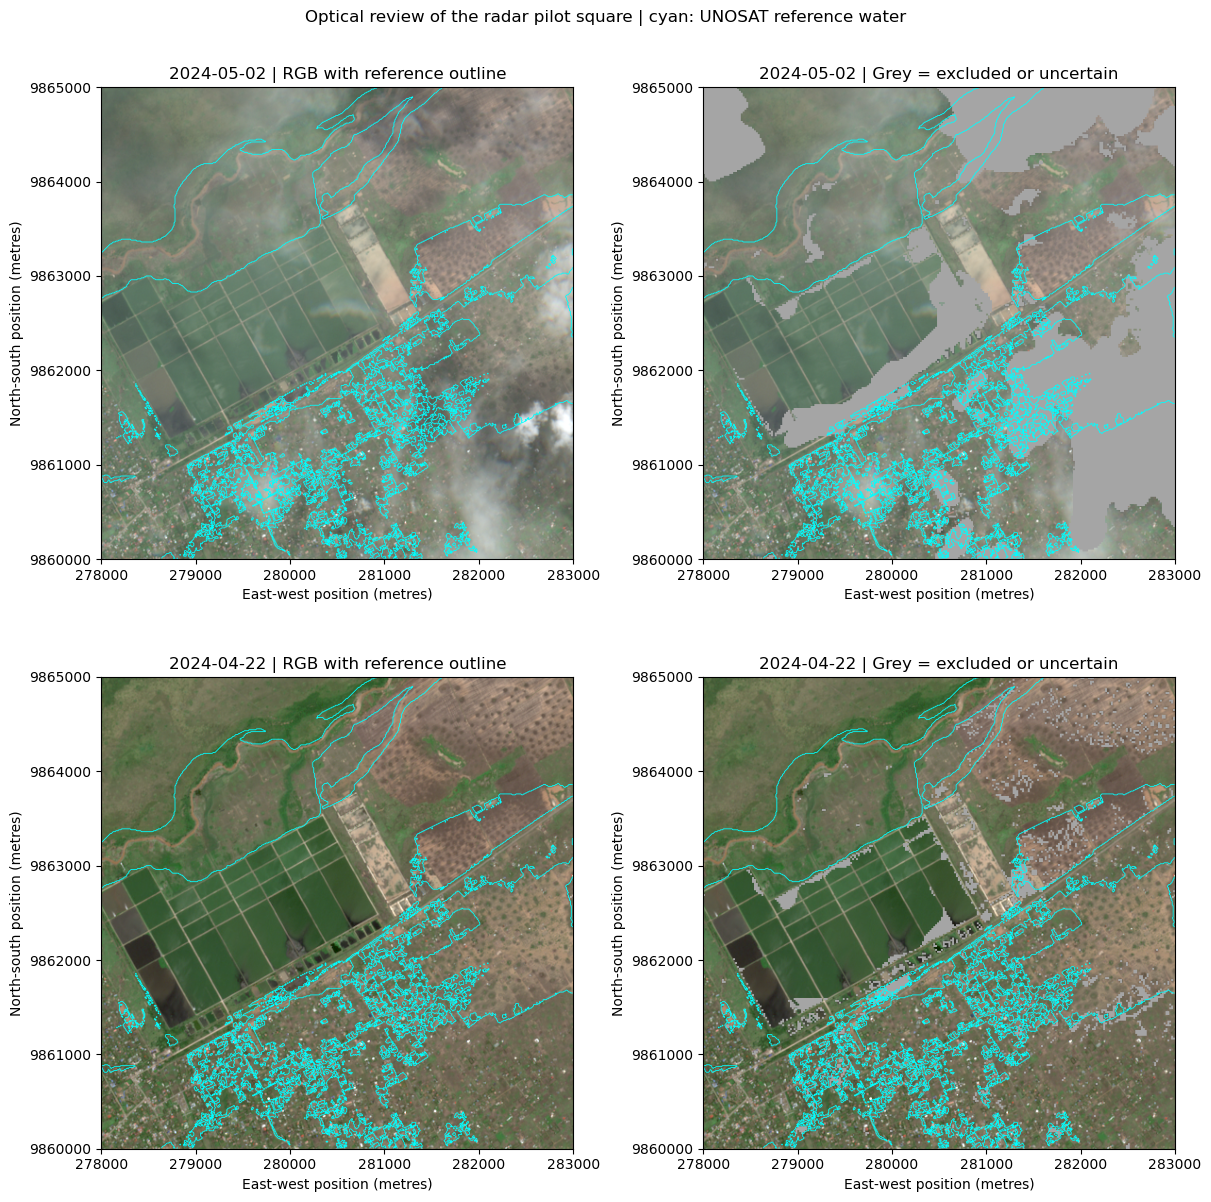

,acquired_utc,days_from_reference,reference_water_clear_fraction
0,2024-05-12 07:36:21.024000+00:00,10.979,0.440
1,2024-05-07 07:36:19.024000+00:00,5.979,0.003
2,2024-05-02 07:36:21.024000+00:00,0.979,0.661
3,2024-04-27 07:36:09.024000+00:00,-4.021,0.020
4,2024-04-22 07:36:21.024000+00:00,-9.021,0.949


417

In [3]:
import matplotlib.pyplot as plt

review = gpd.read_file(BytesIO((GEOGRAPHY_DIR / "review_area_20240501.geojson").read_bytes())).to_crs(OPTICAL_CRS)
water = gpd.read_file(BytesIO((GEOGRAPHY_DIR / "mapped_flood_water_20240501.geojson").read_bytes())).to_crs(OPTICAL_CRS)
review_mask = geometry_mask(review.geometry, transform=optical_transform, out_shape=optical_shape, invert=True)
water_mask = geometry_mask(water.geometry, transform=optical_transform, out_shape=optical_shape, invert=True) & review_mask
if not water_mask.any():
    raise ValueError("The reference has no mapped water in this square.")
visibility_rows = []
for item in optical_items:
    row = cloud_check.set_index("scene_id").loc[item["id"]]
    clear = np.isin(scl_arrays[item["id"]], [4, 5, 6])
    visibility_rows.append({"scene_id": item["id"], "acquired_utc": row.acquired_utc,
        "days_from_reference": row.days_from_reference,
        "reference_water_clear_fraction": float((water_mask & clear).sum() / water_mask.sum()),
        "review_area_clear_fraction": float((review_mask & clear).sum() / review_mask.sum())})
visibility = pd.DataFrame(visibility_rows)
visibility.to_csv(OPTICAL_DIR / "reference_water_visibility.csv", index=False)
fig, axes = plt.subplots(len(selected_ids), 2, figsize=(12, 6 * len(selected_ids)), squeeze=False, constrained_layout=True)
extent = [OPTICAL_BOUNDS[0], OPTICAL_BOUNDS[2], OPTICAL_BOUNDS[1], OPTICAL_BOUNDS[3]]
xs = OPTICAL_BOUNDS[0] + (np.arange(500) + 0.5) * 10
ys = OPTICAL_BOUNDS[3] - (np.arange(500) + 0.5) * 10
for i, scene_id in enumerate(selected_ids):
    rgb = optical_rgb[scene_id]
    # Fixed display stretch of stored values; no quantitative water index.
    shown = np.clip((rgb.astype("float32") - 1000) / 3000, 0, 1) ** (1 / 1.8)
    clear = np.isin(scl_arrays[scene_id], [4, 5, 6]) & (rgb > 0).all(axis=-1)
    masked = shown.copy()
    masked[~clear] = 0.65
    row = cloud_check.set_index("scene_id").loc[scene_id]
    for j, picture in enumerate([shown, masked]):
        axes[i, j].imshow(picture, origin="upper", extent=extent)
        axes[i, j].contour(xs, ys, water_mask, levels=[0.5], colors=["#00ffff"], linewidths=0.6)
        axes[i, j].set_title(f"{row.acquired_utc.date()} | " + ("RGB with reference outline" if j == 0 else "Grey = excluded or uncertain"))
        axes[i, j].set_xlabel("East-west position (metres)")
        axes[i, j].set_ylabel("North-south position (metres)")
        axes[i, j].ticklabel_format(style="plain", useOffset=False)
fig.suptitle("Optical review of the radar pilot square | cyan: UNOSAT reference water")
fig.savefig(FIGURES_DIR / "optical_pilot_review.png", dpi=160, bbox_inches="tight")
plt.show()
display(visibility[["acquired_utc", "days_from_reference", "reference_water_clear_fraction"]].round(3))
(OPTICAL_DIR / "coverage_decision.json").write_text(json.dumps({
    "closest_scene": nearest_id, "clearest_scene": clearest_id,
    "new_training_labels": 0,
    "decision": "Visual and coverage review only; no flood or non-flood labels inferred",
    "limitations": ["Different observation dates", "Cloud and shadow masks are estimates", "Reference polygons are preliminary"],
}, indent=2))

## 47. Check that processing did not move the reference map
I checked the original database layer and the processed flood polygons on the pilot grid. The source uses WGS 84 coordinates with a height reference. Its water-class code is 1 (flood water) and its field-validation code is 0 (not yet checked on the ground).

The original shape is invalid, which explains the earlier repair step. Within the pilot review area, the original and processed versions give the same water mask at all 225,647 tested pixel centres. This checks the processing at this grid spacing; it does not prove positional accuracy or confirm that the mapped areas were flooded.

The database contains several products, so I retain the exact layer name instead of assuming that every shape belongs to the individual PDF map downloaded earlier.

In [ ]:
from pathlib import Path
import geopandas as g, rasterio, numpy as np, json
from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from io import BytesIO
root=Path('data/cache');gdb=next(root.glob('unosat_*/*gdb'))
layer='PL_20240501_FloodExtent_Nairobi_Kiambu'
raw=g.read_file(gdb,layer=layer)
print('Source CRS:',raw.crs,'Shapes:',len(raw),'Valid:',raw.geometry.is_valid.to_list(),flush=True)
print(g.read_file(gdb,layer='Field_Validation',ignore_geometry=True).to_string(index=False),flush=True)
tr=from_origin(278000,9865000,10,10)
a=geometry_mask(raw.to_crs(32737).geometry,out_shape=(500,500),transform=tr,invert=True)
b=g.read_file(BytesIO(Path('data/processed/geography/mapped_flood_water_20240501.geojson').read_bytes())).to_crs(32737)
r=g.read_file(BytesIO(Path('data/processed/geography/review_area_20240501.geojson').read_bytes())).to_crs(32737)
bmask=geometry_mask(b.geometry,out_shape=(500,500),transform=tr,invert=True)
rmask=geometry_mask(r.geometry,out_shape=(500,500),transform=tr,invert=True)
s={'source_layer':layer,'source_crs':str(raw.crs),'source_rows':len(raw),'invalid_source_shapes':int((~raw.geometry.is_valid).sum()),'source_water_classes':raw.Water_Class.to_list(),'source_validation_codes':raw.Field_Validation.to_list(),'compared_pixels':int(rmask.sum()),'different_pixels':int(((a!=bmask)&rmask).sum()),'comparison':'Original and repaired/cropped source rasterised on the same grid within the review area; checks processing, not ground truth'}
Path('data/processed/optical_pilot/reference_geometry_audit.json').write_text(json.dumps(s,indent=2));print(json.dumps(s,indent=2))


{
  "source_layer": "PL_20240501_FloodExtent_Nairobi_Kiambu",
  "source_crs": "COMPD_CS[\"WGS 84 + EGM96 height\",GEOGCS[\"WGS 84\",DATUM[\"WGS_1984\",SPHEROID[\"WGS 84\",6378137,298.257223563,AUTHORITY[\"EPSG\",\"7030\"]],AUTHORITY[\"EPSG\",\"6326\"]],PRIMEM[\"Greenwich\",0,AUTHORITY[\"EPSG\",\"8901\"]],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]],AXIS[\"Latitude\",NORTH],AXIS[\"Longitude\",EAST],AUTHORITY[\"EPSG\",\"4326\"]],VERT_CS[\"EGM96 height\",VERT_DATUM[\"EGM96 geoid\",2005,AUTHORITY[\"EPSG\",\"5171\"]],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Gravity-related height\",UP],AUTHORITY[\"EPSG\",\"5773\"]]]",
  "source_rows": 1,
  "invalid_source_shapes": 1,
  "source_water_classes": [
    1
  ],
  "source_validation_codes": [
    0
  ],
  "compared_pixels": 225647,
  "different_pixels": 0,
  "comparison": "Original and repaired/cropped source rasterised on the same grid within the review area; checks processing, not ground truth"
}


## 48. What the optical check supports
The 2 May image passes the cautious clear-pixel check over about **72% of the pilot square** and **66% of the reference mapped-water area**. It was acquired about 23.5 hours after the UNOSAT image. The 22 April image is clearer, but it is nine days earlier and is not a confirmed dry baseline.

The visual comparison shows persistent rectangular features in both images. These need checking as possible permanent or managed water before treating a water-like signal as flooding. Cloud-free imagery alone does not resolve every uncertain area.

I can continue with a small, manually checked set of visible locations, using before/after evidence and an explicit uncertainty category. I cannot assign labels to obscured areas or extend a single image's condition to an entire day. No labels were added during this check, and no model accuracy claim is supported yet.

## 49. Prepare small before-and-after image samples
I compare eight 500-metre squares from 22 April and 2 May. I choose the clearest square in each of eight parts of the pilot area, using the same rule each time. I require at least 90% of each square to pass the clear-pixel check on both dates.

This is a small review sample, not an accuracy test. The earlier image is not confirmed to be dry. The later image was taken after the 1 May reference map. A clear-pixel flag can also miss haze.

I use the saved downloads, check that their contents and map grids match, and keep existing review notes when I run this section again.

In [99]:
from pathlib import Path
import runpy
import json

review_tools = runpy.run_path(str(Path("scripts/prepare_optical_review.py")))
review_summary = review_tools["prepare_review"]()
print(json.dumps(review_summary, indent=2))

{
  "patches_checked": 100,
  "eligible_patches": 44,
  "selected_patches": 8,
  "minimum_shared_clear_fraction": 0.9392,
  "selection": "Highest shared clear coverage in each of eight spatial sectors; ties use sample ID.",
  "limits": "Purposive pilot sample. April 22 is not confirmed dry. May 2 is after the May 1 reference. No automatic flood labels."
}


## 50. Review the image pairs
I show the earlier image, the later image and the area marked clear on both dates. White means that both images passed this check; it does not mean that the land was dry. Each square is 500 metres wide, but its image detail remains 10 metres.

I keep the observations in `data/processed/optical_review/sample_review.csv`. The notes are an AI-assisted visual review, not independent ground evidence. I leave `flood_label` empty where the images do not support a reliable decision.

Reviewed samples: 8
Samples with a flood label: 0


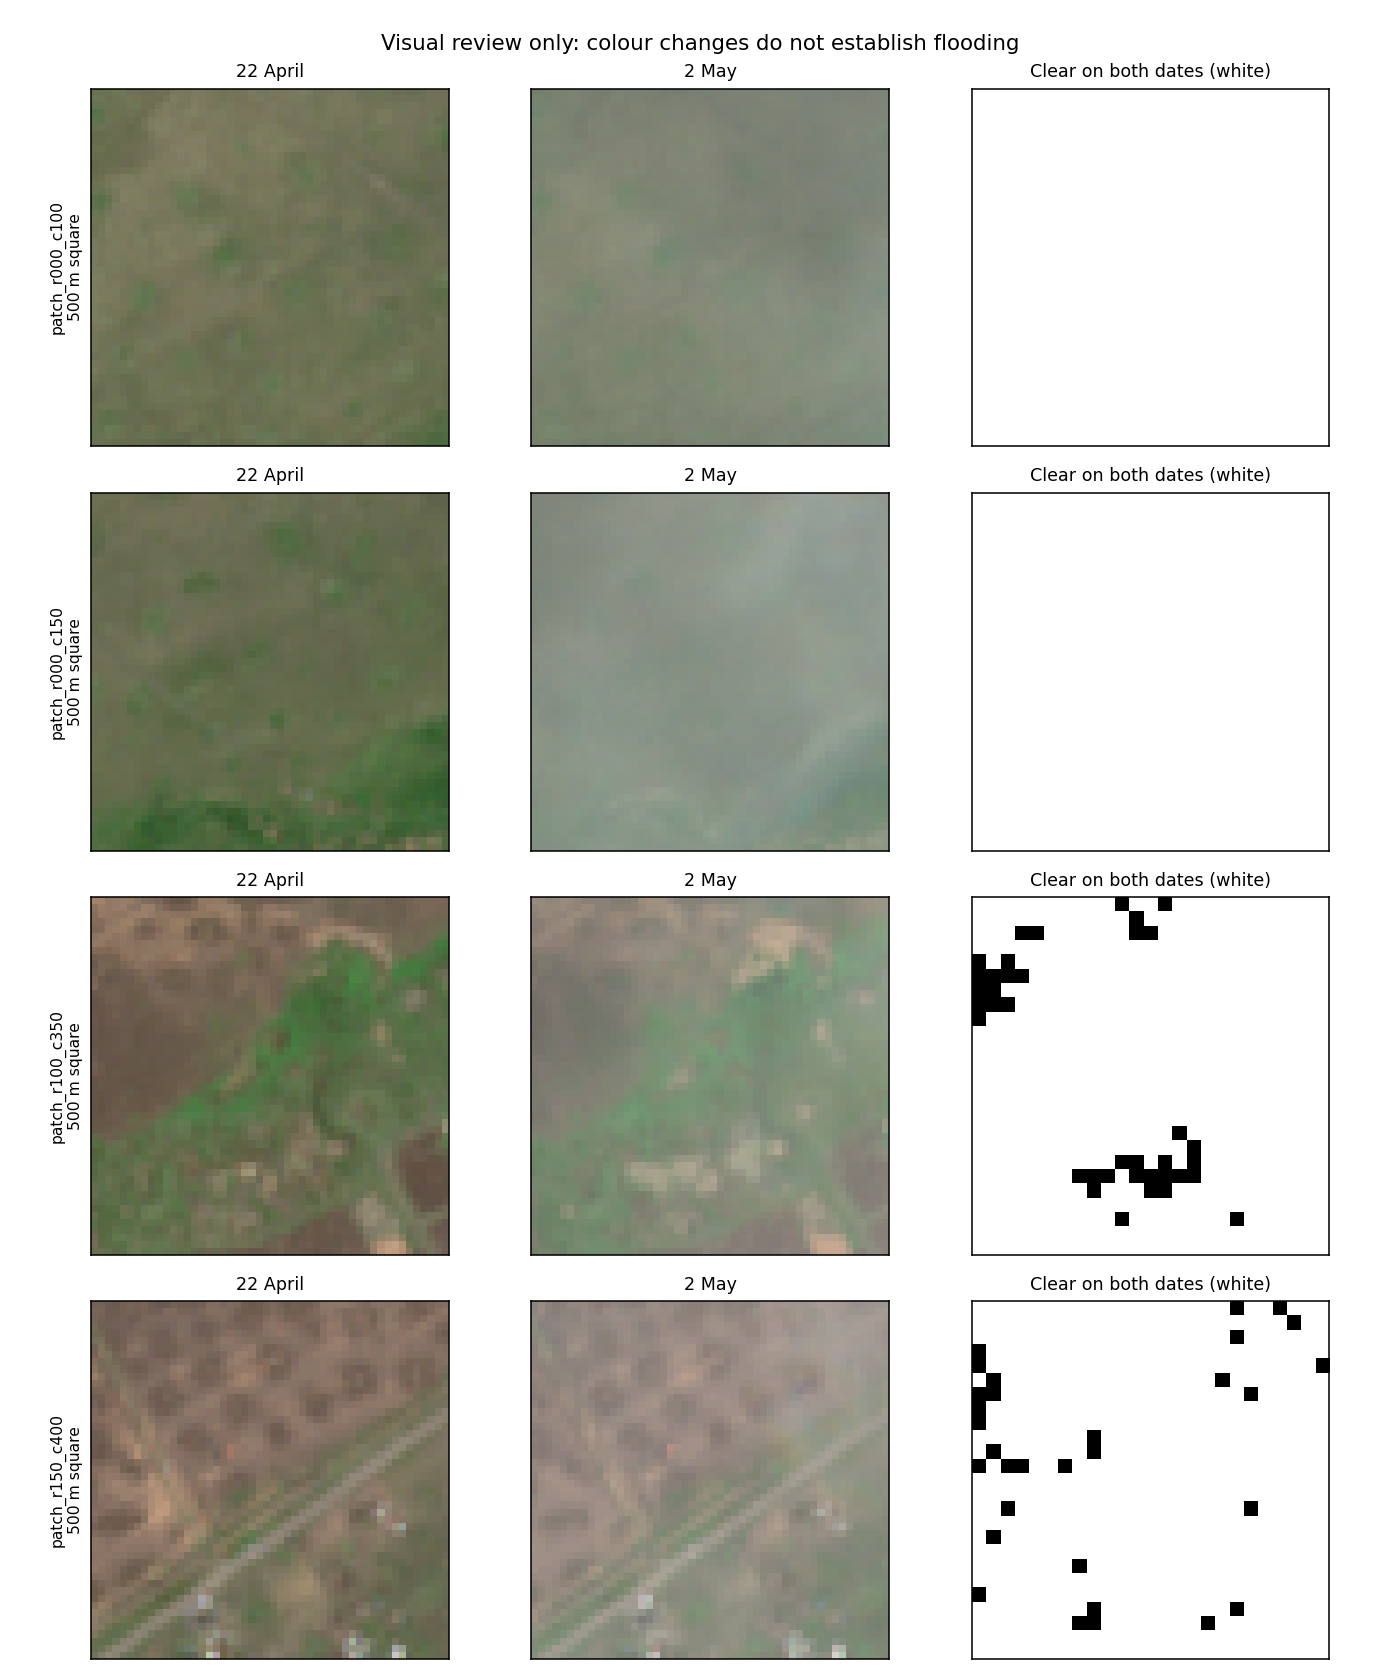

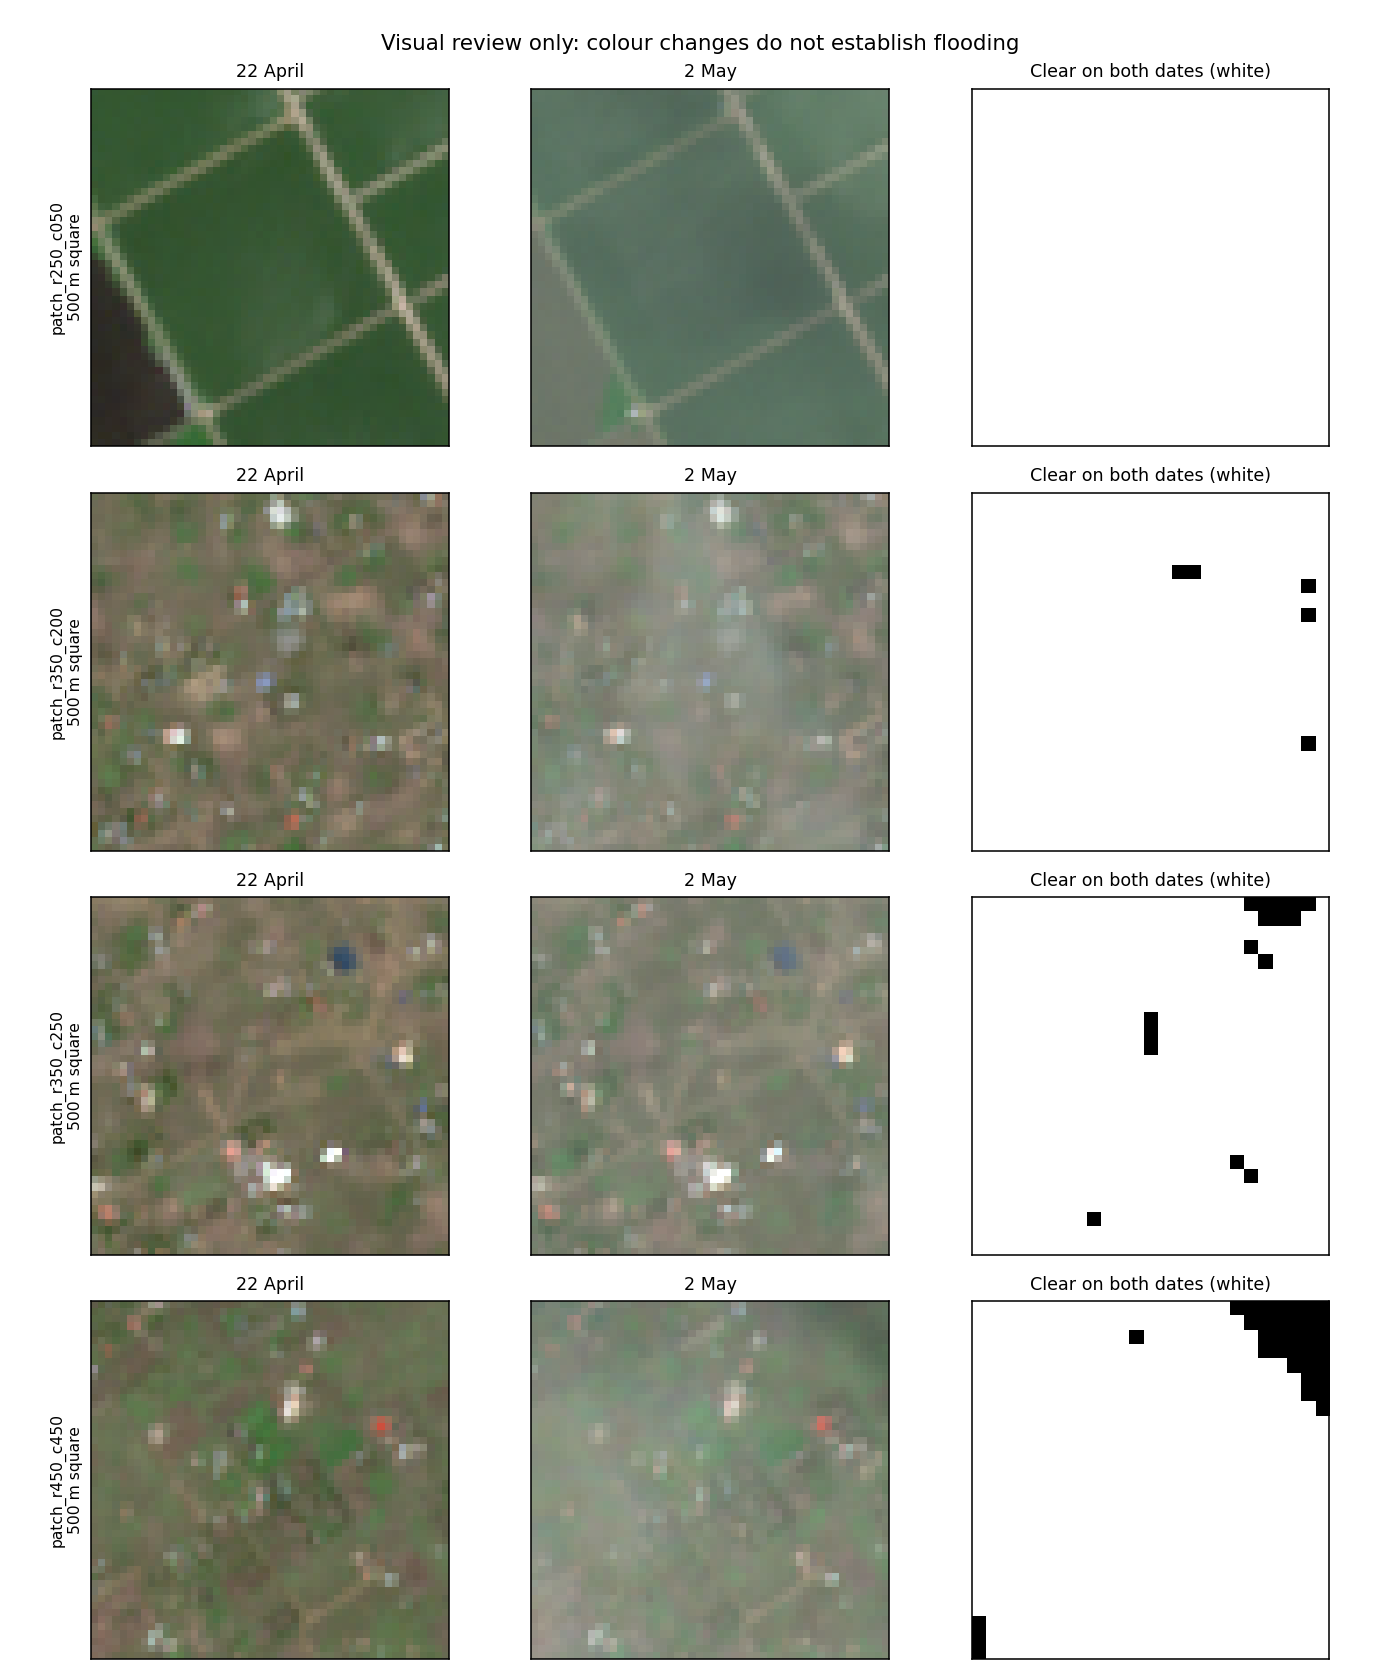

,sample_id,shared_clear_fraction,assessment,notes,flood_label
0,patch_r000_c100,1.0000,ambiguous,Mostly smooth green-brown surface on both date...,NaN
1,patch_r000_c150,1.0000,ambiguous,Similar smooth surface and lower-edge vegetati...,NaN
2,patch_r100_c350,0.9392,ambiguous,Vegetation and brown surfaces remain visible. ...,NaN
3,patch_r150_c400,0.9504,ambiguous,Diagonal linear feature remains visible among ...,NaN
4,patch_r250_c050,1.0000,persistent_water_like_shapes,Regular green pond-like shapes and dividing li...,NaN
5,patch_r350_c200,0.9920,ambiguous,Small bright features and vegetation appear in...,NaN
6,patch_r350_c250,0.9744,ambiguous,Bright features and green-brown surfaces remai...,NaN
7,patch_r450_c450,0.9440,ambiguous,Vegetation and bright features remain visible....,NaN


In [101]:
import pandas as pd
from IPython.display import Image, display

for image_path in sorted(Path("data/figures/optical_review").glob("image_pairs_*.png")):
    display(Image(filename=str(image_path)))
image_reviews = pd.read_csv("data/processed/optical_review/sample_review.csv")
display(image_reviews[["sample_id", "shared_clear_fraction", "assessment", "notes", "flood_label"]])
print("Reviewed samples:", len(image_reviews))
print("Samples with a flood label:", int(image_reviews.flood_label.notna().sum()))

## 51. What I can conclude from this review
I checked 100 possible squares. Of these, 44 passed the 90% shared-clear rule, and I selected eight across the pilot area. The selected squares have about 94–100% shared clear coverage.

I can see regular pond-like shapes in one sample on both dates. The other samples show ambiguous surfaces or changes in colour and visibility. I cannot confirm a new flood from these pairs. I also cannot use an apparent lack of change as proof that no flood happened between the two dates.

I have therefore added no training labels. This result does not show that Nairobi had no flooding; it shows the limits of these particular image pairs.

My next data step is to seek additional dated flood footprints from separate events and review their observation coverage. If those cannot be obtained, I need to agree a narrower flood-susceptibility project with my supervisor: estimating where flooding is more likely, rather than claiming validated next-day forecasts. Training three models on this single event would not establish reliable forecast accuracy.

## 52. Try historical river-flow data
I now test the agreed river high-flow approach. This is a different target from confirmed neighbourhood flooding. I request simulated daily river flow from Open-Meteo, using `consolidated_v4` explicitly rather than mixing historical and forecast products.

I select six points on the saved river map inside Nairobi County. I consider larger upstream areas first and keep the points at least five kilometres apart. These are river-map test points, not confirmed matches to the model's river network.

I test April in 2018, 2021 and 2024. These short samples check availability and variation; they are not enough to set high-flow thresholds or train a model. The API documentation lists an older historical end date, but this request returned values for April 2024. I record the requested product and raw response without assuming that every intervening date is available.

Source: [Open-Meteo Flood API](https://open-meteo.com/en/docs/flood-api). The saved requests use daily river discharge in cubic metres per second. These daily values use GMT; I must align future weather features to the same day boundaries.

In [104]:
from pathlib import Path
import runpy

flood_tools = runpy.run_path(str(Path("scripts/flood_api_pilot.py")))
flood_checks = flood_tools["run_pilot"]()

       site_id  year status  returned_latitude  returned_longitude  offset_m  missing_days  unique_values  minimum  maximum timezone  utc_offset_seconds
river_11029638  2018     ok          -1.274998           37.125015    2669.8             0             18     0.22     1.47      GMT                   0
river_11028017  2018     ok          -1.224999           37.025010    2906.0             0             30     6.00   128.72      GMT                   0
river_11029146  2018     ok          -1.224999           37.025010    2460.4             0             30     6.00   128.72      GMT                   0
river_11028917  2018     ok          -1.224999           36.975006    3041.6             0             29     5.81   130.22      GMT                   0
river_11035056  2018     ok          -1.424999           36.925003    2410.6             0             29     1.56    30.33      GMT                   0
river_11033976  2018     ok          -1.424999           36.875015    2309.8      

## 53. Check the selected model cells
I compare requested points with the returned model-cell centres. A nearby centre does not prove that the model represents the intended river. I also check whether different requests returned the same cell and the same flow series.

I keep the raw replies and request settings under `data/raw/flood_api_pilot`. The tables below are saved under `data/processed/flood_api_pilot`. No flood labels are created.

In [106]:
import json
import pandas as pd

flood_dir = Path("data/processed/flood_api_pilot")
flow = pd.read_csv(flood_dir / "daily_discharge.csv")
checks = pd.read_csv(flood_dir / "coverage_checks.csv")
assert len(flow) == 540
assert not flow.duplicated(["site_id", "date"]).any()
assert flow.river_discharge_m3s.notna().all()
assert (flow.river_discharge_m3s >= 0).all()
cell_columns = ["returned_latitude", "returned_longitude"]
cell_sites = flow[["site_id"] + cell_columns].drop_duplicates()
cell_sites["cell_id"] = cell_sites.groupby(cell_columns, sort=True).ngroup().map(lambda value: f"glofas_cell_{value:02d}")
flow = flow.merge(cell_sites, on=["site_id"] + cell_columns, validate="many_to_one")
for _, group in flow.groupby(["cell_id", "date"]):
    assert group.river_discharge_m3s.nunique() == 1
unique_flow = flow.drop_duplicates(["cell_id", "date"])
cell_sites.to_csv(flood_dir / "site_cell_mapping.csv", index=False)
unique_flow.drop(columns="site_id").to_csv(flood_dir / "unique_cell_discharge.csv", index=False)
flood_summary = {"requested_sites": int(flow.site_id.nunique()), "returned_cells": int(flow.cell_id.nunique()),
                 "downloaded_site_days": len(flow), "unique_cell_days": len(unique_flow),
                 "missing_values": int(flow.river_discharge_m3s.isna().sum()),
                 "smallest_offset_m": float(checks.offset_m.min()), "largest_offset_m": float(checks.offset_m.max()),
                 "decision": "Historical coverage pilot passed; river identity and continuous coverage still need checking. No training labels."}
(flood_dir / "pilot_summary.json").write_text(json.dumps(flood_summary, indent=2))
print(json.dumps(flood_summary, indent=2))
display(cell_sites)

{
  "requested_sites": 6,
  "returned_cells": 5,
  "downloaded_site_days": 540,
  "unique_cell_days": 450,
  "missing_values": 0,
  "smallest_offset_m": 2309.8,
  "largest_offset_m": 3041.6,
  "decision": "Historical coverage pilot passed; river identity and continuous coverage still need checking. No training labels."
}


,site_id,returned_latitude,returned_longitude,cell_id
0,river_11029638,-1.274998,37.125015,glofas_cell_02
30,river_11028017,-1.224999,37.025010,glofas_cell_04
60,river_11029146,-1.224999,37.025010,glofas_cell_04
90,river_11028917,-1.224999,36.975006,glofas_cell_03
120,river_11035056,-1.424999,36.925003,glofas_cell_01
150,river_11033976,-1.424999,36.875015,glofas_cell_00


## 54. Inspect the map and daily flow
I plot the requested points and the returned centres against the existing river map. The connecting lines show the selection offset; they are not river paths. The charts show simulated flow, not measured flooding.

I see six requested points but only five distinct model cells. One eastern point returns much lower flow than the other selected points. That could reflect a different river cell, so I flag it for checking rather than choosing a nearby cell only because its flow looks larger.

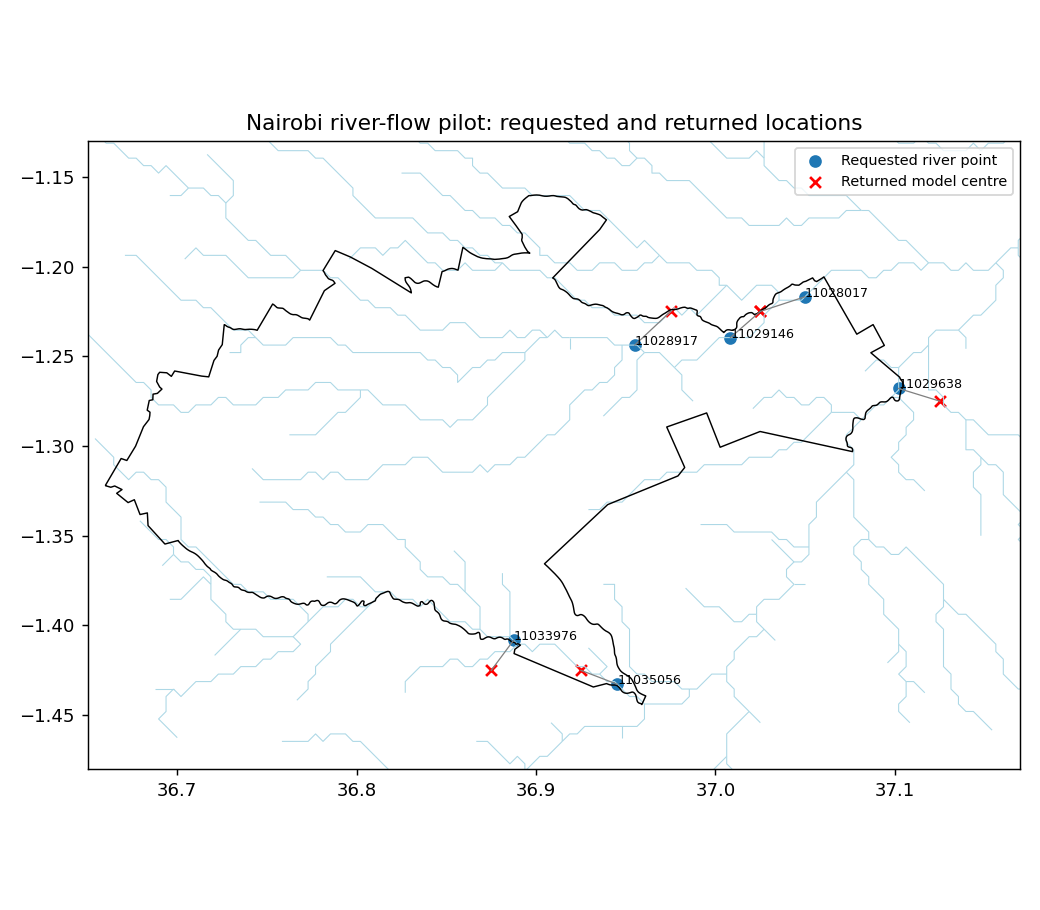

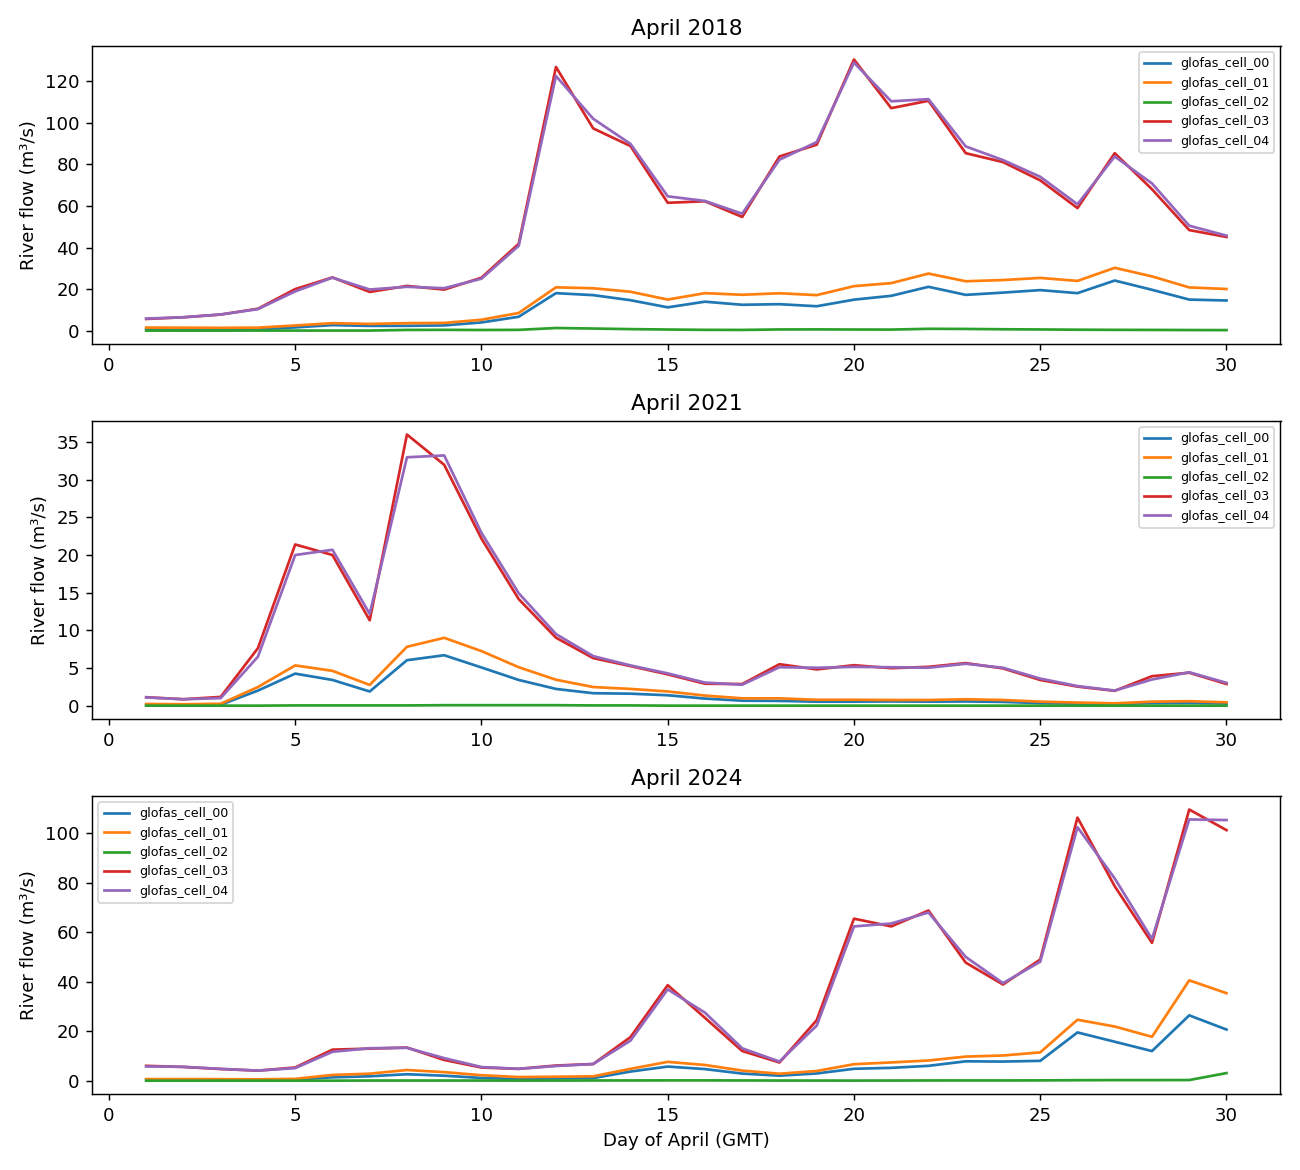

In [108]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path("data/cache/matplotlib").resolve()))
import matplotlib.pyplot as plt
import geopandas as gpd
from io import BytesIO
from IPython.display import Image, display

sites = pd.read_csv(flood_dir / "requested_sites.csv").merge(cell_sites, on="site_id", validate="one_to_one")
rivers = gpd.read_file(BytesIO(Path("data/processed/rivers/nearby_hydrorivers.geojson").read_bytes())).to_crs(4326)
county = gpd.read_file(BytesIO(Path("data/processed/geography/nairobi_county.geojson").read_bytes())).to_crs(4326)
fig, ax = plt.subplots(figsize=(8, 7))
rivers.plot(ax=ax, color="lightblue", linewidth=.6)
county.boundary.plot(ax=ax, color="black", linewidth=.8)
ax.scatter(sites.longitude, sites.latitude, label="Requested river point", marker="o")
ax.scatter(sites.returned_longitude, sites.returned_latitude, label="Returned model centre", marker="x", color="red")
for row in sites.itertuples():
    ax.plot([row.longitude, row.returned_longitude], [row.latitude, row.returned_latitude], color="gray", linewidth=.7)
    ax.annotate(str(row.HYRIV_ID), (row.longitude, row.latitude), fontsize=7)
ax.set_xlim(36.65,37.17)
ax.set_ylim(-1.48,-1.13)
ax.set_title("Nairobi river-flow pilot: requested and returned locations")
ax.legend(fontsize=8)
fig.tight_layout()
figure_dir = Path("data/figures")
fig.savefig(figure_dir / "flood_api_pilot_map.png", dpi=130)
plt.close(fig)
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
for ax, year in zip(axes, [2018, 2021, 2024]):
    subset = unique_flow[unique_flow.date.str.startswith(str(year))]
    for cell_id, group in subset.groupby("cell_id"):
        ax.plot(pd.to_datetime(group.date).dt.day, group.river_discharge_m3s, label=cell_id)
    ax.set_title(f"April {year}")
    ax.set_ylabel("River flow (m³/s)")
    ax.legend(fontsize=7)
axes[-1].set_xlabel("Day of April (GMT)")
fig.tight_layout()
fig.savefig(figure_dir / "flood_api_pilot_flow.png", dpi=130)
plt.close(fig)
for name in ["flood_api_pilot_map.png", "flood_api_pilot_flow.png"]:
    display(Image(filename=str(figure_dir / name)))

## 55. Decision after the first river-flow pilot
The API returned all 540 requested daily values, with no missing or negative flow values. After removing repeated requests for the same model cell, I have 450 distinct cell-days across five cells. The requested and returned points differ by about 2.3–3.0 kilometres.

This is enough to continue investigating the river high-flow project. It is not evidence that the intended rivers have been matched correctly or that the model predicts neighbourhood flooding accurately.

Next I need to verify the model river locations, then collect a continuous multi-year series for suitable cells. I will reserve later years for testing and calculate high-flow thresholds using training years only. My target will be next-day unusually high **simulated river flow**. A simple persistence forecast will be the first comparison before logistic regression, random forest and XGBoost.

Historical reconstructed flow may not have been available at the original prediction time. Any experiment using it as an earlier-day input must be described as a retrospective experiment until I check what data a live system can actually receive.

## 56. Check how much land drains into each model cell
I use the official GloFAS version 4 upstream-area map to check the selected cells. Upstream area means the amount of land that can drain towards a river location. I compare it with the value in our existing river map.

Similar areas support further investigation, but do not prove that two maps describe exactly the same river reach. The model and the river map use different grids and river layouts. I keep the selected cells fixed rather than move them to obtain larger flow values.

The eastern low-flow cell has a model upstream area of about 2,953 square kilometres, compared with about 3,003 in the river map. Its low flow is therefore still unexplained. I retain it as a flagged research cell. Two original points share one model cell, and the two nearby northern model cells have catchment areas of about 954 and 985 square kilometres; they should not be treated as independent catchments without checking their connections.

Source: [GloFAS auxiliary data](https://confluence.ecmwf.int/pages/viewpage.action?pageId=242067380). I saved the official upstream-area file, its source link and its file checksum. Its units are square metres; I divide by one million to report square kilometres.

In [111]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import display

history_tools = runpy.run_path(str(Path("scripts/collect_river_history.py")))
history_summary = history_tools["collect_history"]()
history_dir = Path("data/processed/river_history")
river_audit = pd.read_csv(history_dir / "river_cell_audit.csv")
display(river_audit[["site_id", "cell_id", "UPLAND_SKM", "glofas_upstream_km2", "area_ratio", "flow_review"]])

{
  "cells": 5,
  "rows": 27395,
  "missing": 0,
  "period": "2010-01-01 through 2024-12-31",
  "train": "2010\u20132018",
  "validation": "2019\u20132021",
  "test": "2022\u20132024",
  "purpose": "Retrospective simulated high-flow research; river identity remains provisional. No threshold or model fitted."
}


,site_id,cell_id,UPLAND_SKM,glofas_upstream_km2,area_ratio,flow_review
0,river_11029638,glofas_cell_02,3002.8,2953.138176,0.983461,Low pilot flow despite large upstream area; un...
1,river_11028017,glofas_cell_04,1070.5,984.504960,0.919668,NaN
2,river_11029146,glofas_cell_04,665.1,984.504960,1.480236,NaN
3,river_11028917,glofas_cell_03,587.4,953.739136,1.623662,NaN
4,river_11035056,glofas_cell_01,495.3,461.455648,0.931669,NaN
5,river_11033976,glofas_cell_00,411.4,430.692224,1.046894,NaN


## 57. Check a continuous historical series
I downloaded daily flow for the five fixed model cells from 1 January 2010 to 31 December 2024. These are provisional model-cell study locations, not verified neighbourhood flood locations. I keep the explicit `consolidated_v4` product and GMT day boundaries.

I save the raw replies so rerunning this section can use the cache. The checks require the expected dates, non-negative available values, consistent units and unchanged returned locations. I also compare the new download with the earlier April pilot.

I reserve 2010–2018 for training, 2019–2021 for validation and 2022–2024 for testing. All cells use the same date boundaries. I do not calculate high-flow thresholds using the later years. The current checks concern data coverage only; no model has been fitted.

In [113]:
history = pd.read_csv(history_dir / "daily_discharge_2010_2024.csv")
coverage = pd.read_csv(history_dir / "annual_coverage.csv")
expected_days = pd.date_range("2010-01-01", "2024-12-31").strftime("%Y-%m-%d").tolist()
for cell_id, group in history.groupby("cell_id"):
    assert group.date.tolist() == expected_days
assert len(history) == 5 * len(expected_days)
assert history.river_discharge_m3s.notna().all()
assert not history.duplicated(["cell_id", "date"]).any()
pilot = pd.read_csv("data/processed/flood_api_pilot/unique_cell_discharge.csv")
comparison = pilot.merge(history, on=["cell_id", "date"], suffixes=("_pilot", "_history"), validate="one_to_one")
assert len(comparison) == len(pilot) == 450
assert (comparison.river_discharge_m3s_pilot == comparison.river_discharge_m3s_history).all()
partition_check = history.groupby("partition").agg(first_date=("date", "min"), last_date=("date", "max"), rows=("date", "size"))
partition_check.to_csv(history_dir / "partition_summary.csv")
display(partition_check)
print("Complete daily rows:", len(history))
print("Missing flow values:", int(history.river_discharge_m3s.isna().sum()))
print("Earlier pilot values matched:", len(comparison))

Complete daily rows: 27395
Missing flow values: 0
Earlier pilot values matched: 450


,first_date,last_date,rows
partition,,,
test,2022-01-01,2024-12-31,5480
train,2010-01-01,2018-12-31,16435
validation,2019-01-01,2021-12-31,5480


## 58. What is ready for the next modelling step
I now have 27,395 daily records across five model cells, with no missing days or flow values. All 450 distinct values from the earlier pilot match this longer download.

This gives me a continuous dataset for a retrospective high-flow experiment. It does not validate real flood alerts or settle the uncertain river matches. I keep those limitations in the saved river audit.

Next I can calculate a high-flow threshold separately for each cell using training years only, build earlier-day flow features and evaluate a persistence baseline. I should then add weather aligned to GMT days and compare the three planned models on the same time partitions. Point rainfall is only a first approximation: river flow can depend on rainfall across the upstream catchment, including land outside Nairobi.

I will report high-flow onset performance as well as daily classification scores, because repeated high-flow days can make persistence look strong. Any use of reconstructed earlier-day flow remains a retrospective experiment until I verify real-time data availability.

## 59. Add rainfall for the same study period
I downloaded daily ERA5 rainfall for 2010–2024 at the five model-cell locations. The requests use GMT so that rainfall and river flow share the same daily boundaries. The five locations return three weather grid locations; these are not five independent weather observations.

This first experiment uses rainfall near each model cell. It does not yet represent rainfall over the whole upstream catchment. I also leave out the old 1-kilometre terrain features because those locations are different from this river-cell dataset.

Source: [Open-Meteo historical weather documentation](https://open-meteo.com/en/docs/historical-weather-api). These reconstructed weather values, like the historical flow inputs, are useful for a retrospective experiment. They do not establish what a live alert system could have known at that time.

In [116]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import display

weather_tools = runpy.run_path(str(Path("scripts/collect_model_weather.py")))
model_weather = weather_tools["collect_weather"]()
display(model_weather.head())

Weather rows: 27395 Distinct returned weather cells: 3


,cell_id,date,rain_mm,weather_latitude,weather_longitude
0,glofas_cell_00,2010-01-01,2.6,-1.5,37.0
1,glofas_cell_00,2010-01-02,7.8,-1.5,37.0
2,glofas_cell_00,2010-01-03,1.0,-1.5,37.0
3,glofas_cell_00,2010-01-04,2.3,-1.5,37.0
4,glofas_cell_00,2010-01-05,0.0,-1.5,37.0


## 60. Define high flow and train the first models
For each cell, I calculate the 95th percentile of river flow using 2010–2018 only. A day's label is 1 when its simulated flow is above that threshold; otherwise it is 0. This is a research definition of unusually high simulated flow, not a measured river-overflow level. I choose this rule before looking at validation performance.

Each row describes the day being predicted. I use flow from 1, 2, 3 and 7 days earlier, earlier 3- and 7-day mean flow, earlier 1-, 3- and 7-day rainfall totals, season and model-cell identity. Today's actual flow and rainfall are not model inputs. I express flow features relative to the cell's training threshold. The first seven days per cell are excluded because their earlier inputs are incomplete.

I train logistic regression, random forest and XGBoost on 2010–2018 and compare predictions on 2019–2021. Scaling is fitted on training data only. I use fixed initial settings and a 0.5 classification threshold. Class weighting helps the models account for less common high-flow days, but their scores should not yet be treated as calibrated probabilities.

Two simple comparisons are included: always predict low flow, and repeat yesterday's high-flow status. The final 2022–2024 test period remains unevaluated while I develop the models. All three fitted candidates and their feature lists are saved as research artifacts, not live alert models.

XGBoost 3.0.5 worked with this notebook environment. The initially installed newer release could not load the existing OpenMP library. Package versions are saved with the experiment.

In [118]:
training_tools = runpy.run_path(str(Path("scripts/train_high_flow.py")))
validation_results = training_tools["train_models"]()

              model  precision  recall    f1  roc_auc  average_precision  true_negatives  false_positives  false_negatives  true_positives  onsets  onset_recall  onset_alert_precision
         always_low      0.000   0.000 0.000    0.500              0.098            4945                0              535               0      70         0.000                  0.000
        persistence      0.869   0.869 0.869    0.986              0.940            4875               70               70             465      70         0.000                  0.000
logistic_regression      0.673   0.957 0.790    0.987              0.947            4696              249               23             512      70         0.671                  0.202
      random_forest      0.813   0.908 0.858    0.985              0.940            4833              112               49             486      70         0.300                  0.328
            xgboost      0.767   0.931 0.841    0.988              0.946        

## 61. Read the validation results
Precision tells me how many predicted high-flow days were correct. Recall tells me how many actual high-flow days the model found. F1 balances those two measures. ROC-AUC and average precision assess score rankings; average precision is useful when high-flow days are uncommon.

I also report exact first-day recall for each high-flow spell: how often the model predicts high flow on a day that follows a low-flow day. Persistence always misses this first day by definition. Onset alert precision measures how often high-flow alerts issued after a low-flow day correspond to a real onset.

For persistence, the ranking score is yesterday's flow divided by the training threshold; its class prediction repeats yesterday's label. That score is not a probability.

These are pooled cell-day results. Nearby cells and consecutive days are related, so these rows are not independent flood events. I also save scores by cell so that the uncertain low-flow cell is visible. High scores here measure agreement with simulated flow, not confirmed neighbourhood floods.

In [120]:
import json
experiment_dir = Path("data/processed/high_flow_models")
validation_results = pd.read_csv(experiment_dir / "validation_metrics.csv")
display(validation_results[["model", "precision", "recall", "f1", "roc_auc", "average_precision", "onset_recall", "onset_alert_precision"]].round(3))
display(pd.read_csv(experiment_dir / "validation_metrics_by_cell.csv").round(3))
experiment = json.loads((experiment_dir / "experiment_metadata.json").read_text())
print("Training rows:", experiment["training_rows"])
print("Validation rows:", experiment["validation_rows"])
print("Held-out test rows:", experiment["held_out_test_rows"])
assert experiment["test_evaluated"] is False
print("Final test results have not been calculated.")

Training rows: 16400
Validation rows: 5480
Held-out test rows: 5480
Final test results have not been calculated.


,model,precision,recall,f1,roc_auc,average_precision,onset_recall,onset_alert_precision
0,always_low,0.000,0.000,0.000,0.500,0.098,0.000,0.000
1,persistence,0.869,0.869,0.869,0.986,0.940,0.000,0.000
2,logistic_regression,0.673,0.957,0.790,0.987,0.947,0.671,0.202
3,random_forest,0.813,0.908,0.858,0.985,0.940,0.300,0.328
4,xgboost,0.767,0.931,0.841,0.988,0.946,0.500,0.278


,model,cell_id,precision,recall,f1
0,always_low,glofas_cell_00,0.000,0.000,0.000
1,always_low,glofas_cell_01,0.000,0.000,0.000
2,always_low,glofas_cell_02,0.000,0.000,0.000
3,always_low,glofas_cell_03,0.000,0.000,0.000
4,always_low,glofas_cell_04,0.000,0.000,0.000
5,persistence,glofas_cell_00,0.867,0.867,0.867
6,persistence,glofas_cell_01,0.893,0.893,0.893
7,persistence,glofas_cell_02,0.936,0.936,0.936
8,persistence,glofas_cell_03,0.802,0.802,0.802
9,persistence,glofas_cell_04,0.825,0.825,0.825


## 62. How I will improve this experiment
I will use validation results to guide changes and keep the final test years for a later, fixed evaluation. I should compare flow-only and rainfall-only models with the combined model to establish what each input adds. I can then examine probability thresholds, false alarms and missed onsets, including performance at each model cell.

The main data improvements remain upstream catchment rainfall and resolving uncertain river matches. I should also test realistic input delays: reconstructed yesterday-flow and rainfall may not be available when a real forecast must be issued. Changes in reported scores cannot by themselves resolve these data limitations.

After choosing the features, settings and alert threshold using training and validation years, I can freeze the experiment and evaluate the untouched final test period once. That result will support a final comparison of the three models for this simulated target.

## 63. Compare which inputs help
I compare three input groups for each of the three models: earlier river flow, earlier rainfall, and both together. All groups keep season and cell identity, so “rainfall only” means no flow inputs; it does not mean rainfall is the only column.

I keep the original model settings and training years fixed so that I can compare the input groups fairly. I reuse the fitted combined models and fit the six other candidates on 2010–2018. I do not score the final test years.

The next cell loads the saved comparison. I can set `RERUN_COMPARISON = True` to fit and compare the models again. The script saves all settings, scores and feature lists.

In [123]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import display

comparison_dir = Path("data/processed/high_flow_models/input_comparison")
RERUN_COMPARISON = False
if RERUN_COMPARISON or not (comparison_dir / "comparison_summary.json").exists():
    comparison_tools = runpy.run_path("scripts/compare_high_flow_inputs.py")
    comparison_tools["compare_inputs"]()
comparison_summary = json.loads((comparison_dir / "comparison_summary.json").read_text())
input_scores = pd.read_csv(comparison_dir / "input_comparison_at_050.csv")
display(input_scores[["candidate", "precision", "recall", "f1", "onset_recall", "false_alarms"]].round(3))
assert comparison_summary["test_evaluated"] is False

,candidate,precision,recall,f1,onset_recall,false_alarms
0,logistic_regression__combined,0.673,0.957,0.790,0.671,249
1,logistic_regression__flow_only,0.665,0.957,0.785,0.671,258
2,logistic_regression__rainfall_only,0.503,0.807,0.620,0.586,427
3,random_forest__combined,0.813,0.908,0.858,0.300,112
4,random_forest__flow_only,0.779,0.908,0.839,0.300,138
5,random_forest__rainfall_only,0.575,0.643,0.607,0.329,254
6,xgboost__combined,0.767,0.931,0.841,0.500,151
7,xgboost__flow_only,0.736,0.923,0.819,0.429,177
8,xgboost__rainfall_only,0.507,0.742,0.602,0.514,386


## 64. Compare alert thresholds
The model's score is converted into an alert using a threshold. Lowering it usually catches more high-flow days and raises more false alarms. This alert threshold is separate from the training-only river-flow threshold used to define the target.

I try score thresholds from 0.10 to 0.95 in steps of 0.05. I choose the threshold for each candidate using daily F1 in 2019–2020, then check it on 2021. I select the provisional candidate using the same earlier-year rule, not the best 2021 result.

This is an exploratory check: I already saw 2021 in the earlier validation report, so it is not a new untouched holdout. Only 2022–2024 remains the final test period. Maximising daily F1 may not give the best early warning, so I show first-day detection and false alarms alongside it.

In [125]:
threshold_results = pd.read_csv(comparison_dir / "selected_threshold_results.csv")
check_2021 = threshold_results[threshold_results.period == "2021_check"]
display(check_2021[["candidate", "threshold", "precision", "recall", "f1", "false_alarms", "onsets", "detected_onsets"]].round(3))
print("Provisional candidate:", comparison_summary["selected_candidate"])
print("Alert threshold:", comparison_summary["threshold"])
print("Persistence on the same 2021 dates:")
display(pd.DataFrame([comparison_summary["baseline_2021"]]))

Provisional candidate: logistic_regression__flow_only
Alert threshold: 0.95
Persistence on the same 2021 dates:


,candidate,threshold,precision,recall,f1,false_alarms,onsets,detected_onsets
1,logistic_regression__combined,0.90,0.568,0.778,0.656,16,8,2
4,logistic_regression__flow_only,0.95,0.692,0.667,0.679,8,8,1
7,logistic_regression__rainfall_only,0.65,0.197,0.963,0.327,106,8,7
10,random_forest__combined,0.65,0.583,0.778,0.667,15,8,2
13,random_forest__flow_only,0.85,0.750,0.667,0.706,6,8,0
16,random_forest__rainfall_only,0.30,0.142,0.926,0.246,151,8,6
19,xgboost__combined,0.80,0.583,0.778,0.667,15,8,2
22,xgboost__flow_only,0.85,0.588,0.741,0.656,14,8,1
25,xgboost__rainfall_only,0.50,0.154,0.926,0.265,137,8,6


,precision,recall,f1,average_precision,roc_auc,false_alarms,missed_high_days,onsets,detected_onsets,onset_recall,onset_alert_precision,rows
0,0.703704,0.703704,0.703704,None,None,8,8,8,0,0.0,0.0,1825


## 65. Inspect the trade-off visually
I plot daily F1 against the input group, then show the threshold trade-off for the provisional candidate. False alarms are counted as cell-days, not independent flood incidents. Consecutive dates and nearby cells can be related.

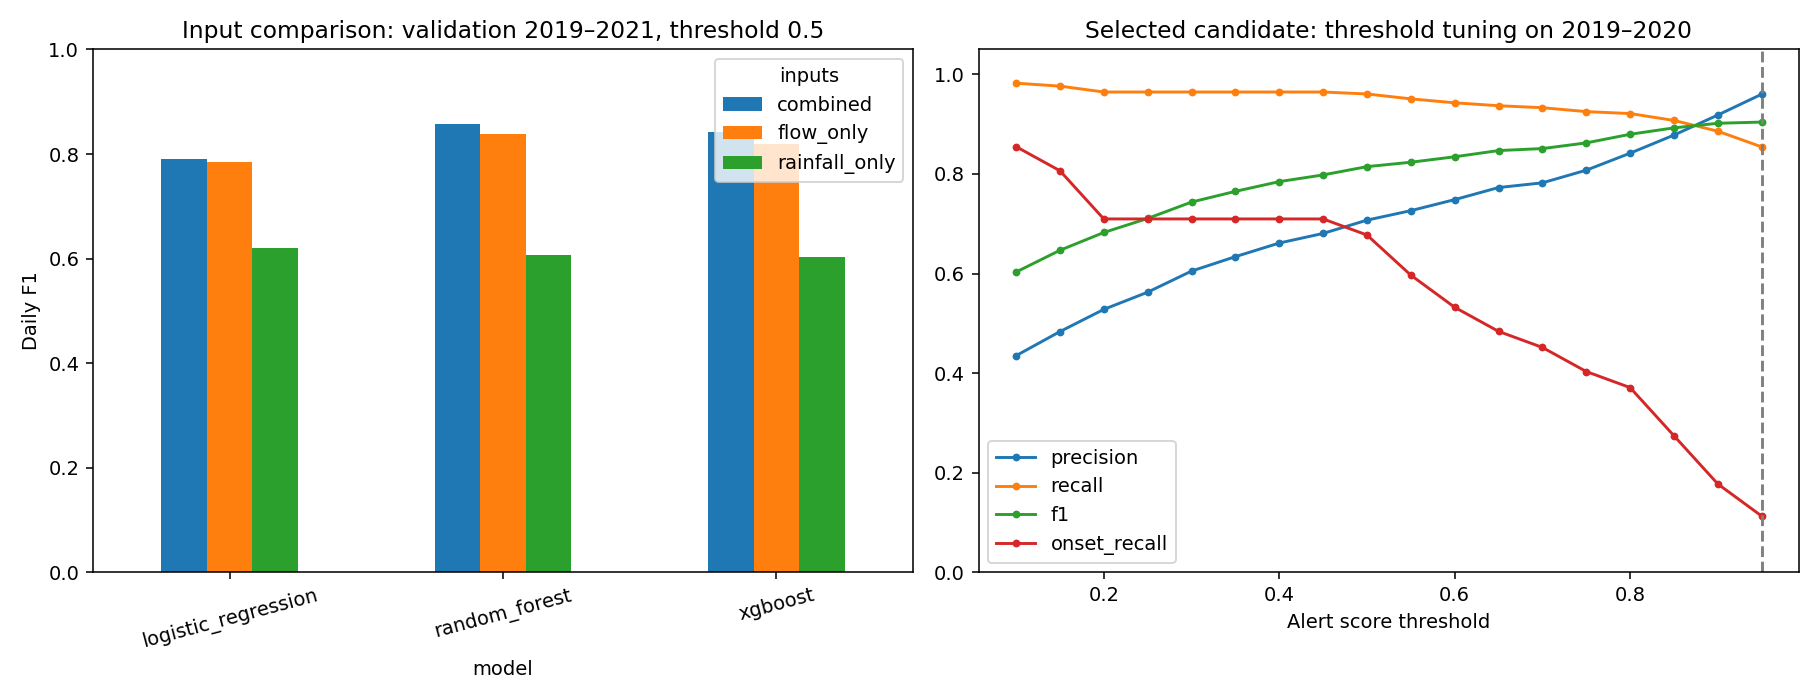

In [127]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path("data/cache/matplotlib").resolve()))
import matplotlib.pyplot as plt
from IPython.display import Image

plot_scores = input_scores.copy()
plot_scores[["model", "inputs"]] = plot_scores.candidate.str.split("__", expand=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_scores.pivot(index="model", columns="inputs", values="f1").plot.bar(ax=axes[0])
axes[0].set_title("Input comparison: validation 2019–2021, threshold 0.5")
axes[0].set_ylabel("Daily F1")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
sweep = pd.read_csv(comparison_dir / "threshold_sweep_2019_2020.csv")
selected_sweep = sweep[sweep.candidate == comparison_summary["selected_candidate"]]
for metric in ["precision", "recall", "f1", "onset_recall"]:
    axes[1].plot(selected_sweep.threshold, selected_sweep[metric], marker=".", label=metric)
axes[1].axvline(comparison_summary["threshold"], color="gray", linestyle="--")
axes[1].set_title("Selected candidate: threshold tuning on 2019–2020")
axes[1].set_xlabel("Alert score threshold")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
fig.tight_layout()
figure_path = Path("data/figures/high_flow_input_comparison.png")
fig.savefig(figure_path, dpi=140)
plt.close(fig)
display(Image(filename=str(figure_path)))

## 66. Keep the final evaluation separate
I saved a provisional candidate with its feature list, fitted preprocessing, river-flow thresholds and chosen alert threshold in `models/high_flow_experiment/input_comparison/provisional_selected.joblib`. Reloading it reproduced its saved validation scores.

This is not yet the final selected model. The daily-F1 rule is a research comparison, not an agreed operating rule for public alerts. The next practical checks are input delays and whether the choice remains useful at each cell, especially the flagged low-flow cell. More representative upstream rainfall may help, but the current point-rainfall experiment cannot establish that in advance.

I will freeze a model and its threshold before the final 2022–2024 evaluation. I will not repeatedly use those test results to tune the same model and still call them an independent test.

**What this run showed:** At the original 0.5 alert threshold, adding rainfall improved daily F1 for every model compared with flow-only inputs. Rainfall-only candidates were weaker on daily F1 than flow-based candidates.

The earlier-year F1 rule selected flow-only logistic regression at a score threshold of 0.95. On the 2021 check, it reached F1 0.679 versus 0.704 for persistence, with eight false-alarm cell-days for each. It detected just one of eight high-flow onsets; persistence detected none. I do not claim that this candidate is an improvement. The selected threshold is also the highest threshold tested, so it is a grid-search result, not proof of a global optimum.

There were only 27 high-flow cell-days and eight onsets in the 2021 check. This small sample makes the first-day result uncertain. A more useful next step is comparison across several time windows within the development years and explicit delay checks, while keeping 2022–2024 untouched.

## 67. Analyse the errors before changing the models
I now examine the original validation predictions at the 0.5 alert threshold. I keep the models and labels fixed so that this analysis does not confuse model changes with changes in the data.

A false alarm here means predicted high flow when the simulated flow did not exceed the training threshold. It does not mean that I have confirmed there was no real flood. I count both alert days and continuous alert episodes for each model cell.

I check all 5,480 validation cell-days per model, confirm the target labels against the saved flow thresholds, and reconcile the daily and episode totals. I use no final test results and fit no new models.

In [130]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import display

error_tools = runpy.run_path("scripts/analyse_high_flow_errors.py")
error_dir = error_tools["analyse_errors"]()
error_summary = pd.read_csv(error_dir / "model_summary.csv")
display(error_summary[["model", "false_alarm_days", "missed_high_days", "precision", "recall", "false_positive_rate", "onsets", "detected_onsets"]].round(3))

              model   rows  high_days  prevalence  alerts  false_alarm_days  missed_high_days  precision  recall  false_positive_rate  false_alarms_per_100_cell_days  onsets  detected_onsets
         always_low 5480.0      535.0       0.098     0.0               0.0             535.0        NaN   0.000                0.000                           0.000    70.0              0.0
logistic_regression 5480.0      535.0       0.098   761.0             249.0              23.0      0.673   0.957                0.050                           4.544    70.0             47.0
        persistence 5480.0      535.0       0.098   535.0              70.0              70.0      0.869   0.869                0.014                           1.277    70.0              0.0
      random_forest 5480.0      535.0       0.098   598.0             112.0              49.0      0.813   0.908                0.023                           2.044    70.0             21.0
            xgboost 5480.0      535.0       0

,model,false_alarm_days,missed_high_days,precision,recall,false_positive_rate,onsets,detected_onsets
0,always_low,0.0,535.0,NaN,0.000,0.000,70.0,0.0
1,logistic_regression,249.0,23.0,0.673,0.957,0.050,70.0,47.0
2,persistence,70.0,70.0,0.869,0.869,0.014,70.0,0.0
3,random_forest,112.0,49.0,0.813,0.908,0.023,70.0,21.0
4,xgboost,151.0,37.0,0.767,0.931,0.031,70.0,35.0


## 68. Separate timing errors from isolated false alarms
I classify false-alarm dates by whether a high-flow day occurs within three days before or after them. “Between” means there are nearby high-flow days on both sides. The three-day window is an exploratory description, not a new definition of a correct prediction.

This check uses later target values only to understand past mistakes. Those values are never model inputs. I leave every original false alarm counted as an error, even if it happens shortly before a high-flow day. Dates near the validation boundary can have incomplete timing context.

For the original random forest, 93 of 112 false-alarm days are within three days of a high-flow day. Of these, 84 have a high-flow day in the previous three days, including 13 between high-flow dates. Logistic regression has 106 of 249 false-alarm days with no high-flow day within three days.

I also examine actual flow relative to the threshold. “Near” means between 90% and 100% of the threshold. About 43% of random-forest false alarms are near it, compared with about 1.2% of all low-flow days. This concentration is useful to investigate, but I do not relabel these errors as successes.

In [132]:
timing = pd.read_csv(error_dir / "false_alarm_timing.csv")
proximity = pd.read_csv(error_dir / "threshold_proximity.csv")
episodes = pd.read_csv(error_dir / "episode_summary.csv")
display(timing.pivot(index="model", columns="timing_context", values="false_alarm_days").fillna(0).astype(int))
display(proximity[proximity["subset"].isin(["false_alarm_days", "all_negative_days"])].round(3))
display(episodes)
print("An episode that overlaps one high-flow day can still contain false-alarm days.")

An episode that overlaps one high-flow day can still contain false-alarm days.


timing_context,after_high_within_3d,before_high_within_3d,between_high_days_within_3d,no_high_within_3d
model,,,,
logistic_regression,101,27,15,106
persistence,57,0,13,0
random_forest,71,9,13,19
xgboost,64,14,12,61


,model,subset,days,median_actual_flow_ratio,near_below_threshold_days,near_below_threshold_fraction
0,always_low,false_alarm_days,0,NaN,0,NaN
1,always_low,all_negative_days,4945,0.018,59,0.012
3,logistic_regression,false_alarm_days,249,0.760,54,0.217
4,logistic_regression,all_negative_days,4945,0.018,59,0.012
6,persistence,false_alarm_days,70,0.919,37,0.529
7,persistence,all_negative_days,4945,0.018,59,0.012
9,random_forest,false_alarm_days,112,0.880,48,0.429
10,random_forest,all_negative_days,4945,0.018,59,0.012
12,xgboost,false_alarm_days,151,0.846,51,0.338
13,xgboost,all_negative_days,4945,0.018,59,0.012


,model,alert_episodes,overlapping_episodes,alert_days,episodes_starting_on_low_day,boundary_episodes,episodes_without_high_day
0,logistic_regression,132,57,761,86,0,75
1,persistence,70,62,535,8,0,8
2,random_forest,84,64,598,23,0,20
3,xgboost,116,63,649,60,0,53


## 69. Check differences across years and cells
High-flow prevalence is about 13.7% in 2019, 14.1% in 2020 and 1.5% in 2021 under the same training thresholds. The 2021 validation results therefore describe a very different balance of high and low days. This can affect precision; it does not by itself prove a change in climate or a fault in the source data.

Cells 03 and 04 together account for roughly half of the false-alarm days for each trained model. Those cells also have uncertain river relationships, so their mapping and shared catchment information deserve attention. I do not infer a causal explanation from these counts.

I save results by cell and year, plus a comparison with and without flagged cell 02. Excluding that cell is a sensitivity check, not a change to the agreed study dataset. The errors are not confined to that one flagged cell.

,model,year,high_days,prevalence,false_alarm_days,precision,recall,detected_onsets
3,logistic_regression,2019,250.0,0.137,92.0,0.726,0.976,25.0
4,logistic_regression,2020,258.0,0.141,109.0,0.691,0.946,17.0
5,logistic_regression,2021,27.0,0.015,48.0,0.333,0.889,5.0
6,persistence,2019,250.0,0.137,27.0,0.890,0.876,0.0
7,persistence,2020,258.0,0.141,35.0,0.866,0.880,0.0
8,persistence,2021,27.0,0.015,8.0,0.704,0.704,0.0
9,random_forest,2019,250.0,0.137,33.0,0.872,0.896,5.0
10,random_forest,2020,258.0,0.141,54.0,0.816,0.926,12.0
11,random_forest,2021,27.0,0.015,25.0,0.479,0.852,4.0
12,xgboost,2019,250.0,0.137,50.0,0.823,0.928,15.0


,model,scope,precision,recall,false_positive_rate
0,always_low,all_cells,NaN,0.000,0.000
1,always_low,without_flagged_cell_02,NaN,0.000,0.000
2,logistic_regression,all_cells,0.673,0.957,0.050
3,logistic_regression,without_flagged_cell_02,0.663,0.951,0.050
4,persistence,all_cells,0.869,0.869,0.014
5,persistence,without_flagged_cell_02,0.849,0.849,0.016
6,random_forest,all_cells,0.813,0.908,0.023
7,random_forest,without_flagged_cell_02,0.799,0.893,0.023
8,xgboost,all_cells,0.767,0.931,0.031
9,xgboost,without_flagged_cell_02,0.755,0.917,0.031


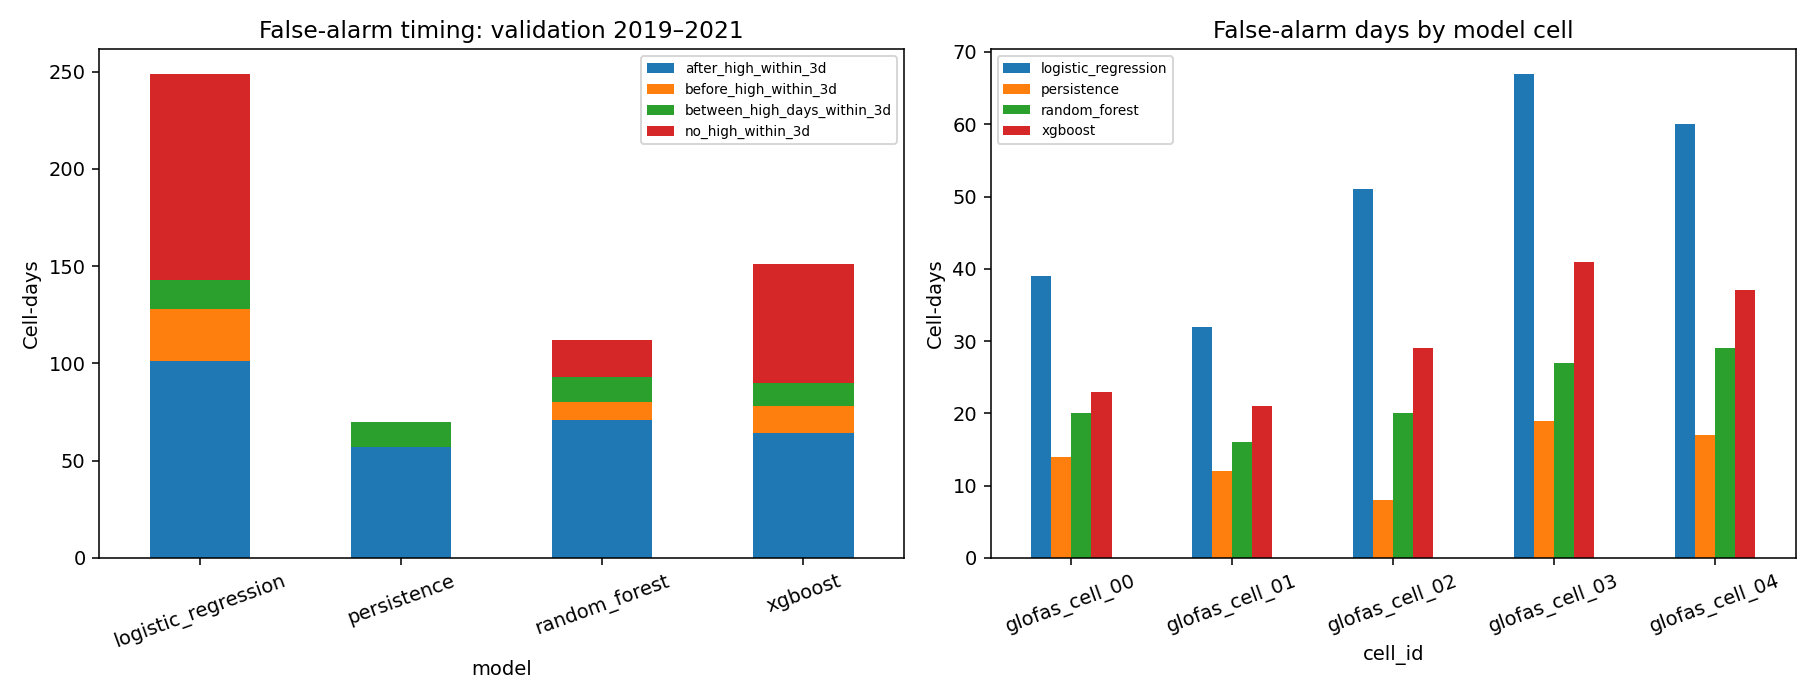

In [134]:
year_errors = pd.read_csv(error_dir / "by_year.csv")
cell_errors = pd.read_csv(error_dir / "by_cell.csv")
display(year_errors[year_errors.model != "always_low"][["model", "year", "high_days", "prevalence", "false_alarm_days", "precision", "recall", "detected_onsets"]].round(3))
display(pd.read_csv(error_dir / "flagged_cell_sensitivity.csv")[["model", "scope", "precision", "recall", "false_positive_rate"]].round(3))

import os
os.environ.setdefault("MPLCONFIGDIR", str(Path("data/cache/matplotlib").resolve()))
import matplotlib.pyplot as plt
from IPython.display import Image
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
timing.pivot(index="model", columns="timing_context", values="false_alarm_days").fillna(0).plot.bar(stacked=True, ax=axes[0])
axes[0].set_title("False-alarm timing: validation 2019–2021")
axes[0].set_ylabel("Cell-days")
axes[0].legend(fontsize=7)
axes[0].tick_params(axis="x", rotation=20)
cell_errors[cell_errors.model != "always_low"].pivot(index="cell_id", columns="model", values="false_alarm_days").plot.bar(ax=axes[1])
axes[1].set_title("False-alarm days by model cell")
axes[1].set_ylabel("Cell-days")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=7)
fig.tight_layout()
error_figure = Path("data/figures/high_flow_error_analysis.png")
fig.savefig(error_figure, dpi=140)
plt.close(fig)
display(Image(filename=str(error_figure)))

## 70. Use the findings to plan controlled improvements
The analysis shows a mix of near-threshold errors, alerts after high-flow periods and more isolated false alarms. I should not assume they all have the same cause or immediately replace the data source.

My next controlled experiment will compare the original class weighting with milder weighting and no weighting, keeping the input columns and model settings otherwise fixed. I will report precision, recall, first-day detection and false-alarm episodes. I will also check the trade-off across several chronological development periods. If a fold uses an earlier training end date, I must recalculate its flow thresholds and preprocessing using that fold's training years only.

I should check delayed-input experiments separately, then prioritise river matching and upstream rainfall if the remaining error patterns justify them. Requiring repeated alerts might reduce isolated false alarms but could delay first warnings, so it is a hypothesis to test rather than an automatic fix.

All timing windows and proximity bands in this section are descriptive choices. I have not changed the target labels, removed difficult cells, or claimed that nearby high flow makes an earlier false alarm correct. The final 2022–2024 test remains unevaluated.

## 71. Compare class weighting carefully
The original models give more weight to high-flow training examples because they are less common. I compare those settings with milder weighting and no weighting. I keep the combined flow and rainfall inputs, model settings, random seed and 0.5 alert threshold fixed.

The mild positive-to-negative weight ratio is the square root of the training imbalance ratio. For logistic regression and random forest, I normalise the weights to an average of one. XGBoost uses its positive-class weight parameter. The original random forest balances each bootstrap sample, while the mild version uses fixed weights from the whole training set.

I train on 2010–2018 and report 2019, 2020 and 2021 separately as well as together. This is a yearly breakdown of a fixed training experiment, not rolling cross-validation. I do not evaluate 2022–2024.

The comparison script checks that the original candidates reproduce their earlier scores and that reloading each saved candidate reproduces its predictions. The next cell loads the saved results. I can set `RERUN_WEIGHTS = True` to repeat the experiment.

In [137]:
from pathlib import Path
import json
import runpy
import hashlib
import pandas as pd
from IPython.display import display

weight_dir = Path("data/processed/high_flow_models/weight_comparison")
RERUN_WEIGHTS = False
if RERUN_WEIGHTS or not (weight_dir / "experiment_summary.json").exists():
    weight_tools = runpy.run_path("scripts/compare_class_weights.py")
    weight_tools["compare_weights"]()
weight_summary = json.loads((weight_dir / "experiment_summary.json").read_text())
assert weight_summary["test_evaluated"] is False
assert hashlib.sha256(Path("data/processed/high_flow_models/labelled_research_dataset.csv").read_bytes()).hexdigest() == weight_summary["data_sha256"]
weight_results = pd.read_csv(weight_dir / "validation_metrics.csv")
pooled_weights = weight_results[weight_results.period == "all_validation"]
display(pooled_weights[["model", "weighting", "precision", "recall", "f1", "false_alarm_days", "missed_high_days", "onsets", "detected_onsets", "entirely_false_episodes"]].round(3))
print("Original training imbalance ratio:", round(weight_summary["negative_positive_ratio"], 3))
print("Mild ratio:", round(weight_summary["mild_ratio"], 3))

Original training imbalance ratio: 19.297
Mild ratio: 4.393


,model,weighting,precision,recall,f1,false_alarm_days,missed_high_days,onsets,detected_onsets,entirely_false_episodes
0,logistic_regression,mild,0.837,0.901,0.868,94,53,70,22,25
4,logistic_regression,none,0.930,0.841,0.883,34,85,70,4,16
8,logistic_regression,original,0.673,0.957,0.790,249,23,70,47,75
12,persistence,baseline,0.869,0.869,0.869,70,70,70,0,8
16,random_forest,mild,0.880,0.880,0.880,64,64,70,10,20
20,random_forest,none,0.925,0.832,0.876,36,90,70,4,14
24,random_forest,original,0.813,0.908,0.858,112,49,70,21,20
28,xgboost,mild,0.878,0.884,0.881,66,62,70,13,20
32,xgboost,none,0.943,0.830,0.883,27,91,70,3,9
36,xgboost,original,0.767,0.931,0.841,151,37,70,35,53


## 72. Check the cost of fewer false alarms
I report how many false-alarm days each change removes, how many extra high-flow days it misses and how first-day detection changes. A lower false-alarm count is not automatically a better warning system.

An entirely false episode contains alerts but no high-flow target day. Episodes are counted separately within each model cell. Yearly episode counts may split a continuous episode at a year boundary, so their sum need not equal the full-period count.

These models produce scores, not calibrated flood probabilities. Keeping the score threshold at 0.5 isolates the effect of class weighting at that operating point. It does not establish which candidate performs best when all candidates are allowed the same false-alarm rate or recall.

,model,weighting,period,fewer_false_alarm_days,additional_missed_high_days,change_in_detected_onsets
0,logistic_regression,mild,all_validation,155,30,-25
1,logistic_regression,none,all_validation,215,62,-43
8,random_forest,mild,all_validation,48,15,-11
9,random_forest,none,all_validation,76,41,-17
16,xgboost,mild,all_validation,85,25,-22
17,xgboost,none,all_validation,124,54,-32


,model,weighting,period,false_alarm_days,missed_high_days,onsets,detected_onsets
1,logistic_regression,mild,2019,23,30,31,5
2,logistic_regression,mild,2020,53,19,31,13
3,logistic_regression,mild,2021,18,4,8,4
5,logistic_regression,none,2019,7,45,31,0
6,logistic_regression,none,2020,18,32,31,3
7,logistic_regression,none,2021,9,8,8,1
9,logistic_regression,original,2019,92,6,31,25
10,logistic_regression,original,2020,109,14,31,17
11,logistic_regression,original,2021,48,3,8,5
13,persistence,baseline,2019,27,31,31,0


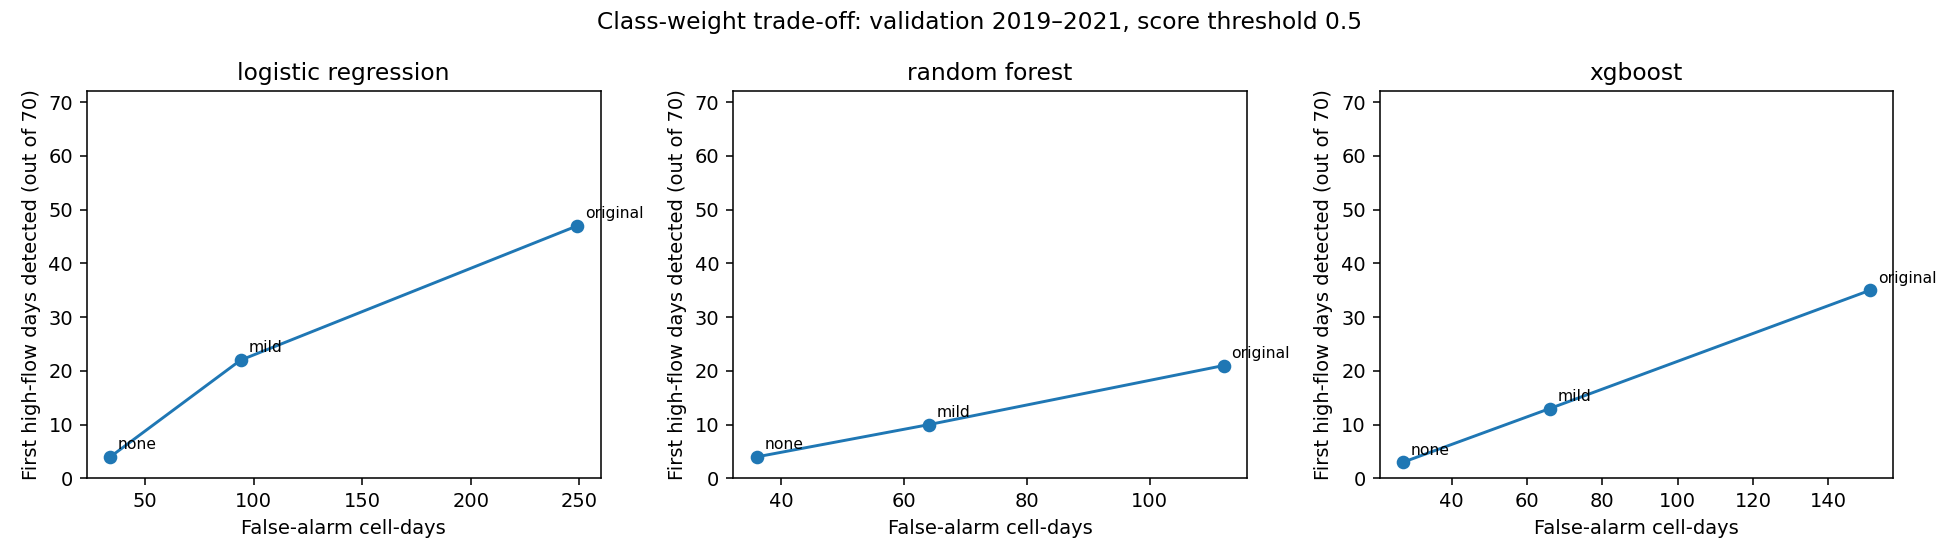

In [139]:
weight_changes = pd.read_csv(weight_dir / "changes_from_original.csv")
display(weight_changes[weight_changes.period == "all_validation"])
display(weight_results[weight_results.period != "all_validation"][["model", "weighting", "period", "false_alarm_days", "missed_high_days", "onsets", "detected_onsets"]])

import os
os.environ.setdefault("MPLCONFIGDIR", str(Path("data/cache/matplotlib").resolve()))
import matplotlib.pyplot as plt
from IPython.display import Image
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model in zip(axes, ["logistic_regression", "random_forest", "xgboost"]):
    subset = pooled_weights[pooled_weights.model == model].set_index("weighting").loc[["original", "mild", "none"]]
    ax.plot(subset.false_alarm_days, subset.detected_onsets, marker="o")
    for weighting, row in subset.iterrows():
        ax.annotate(weighting, (row.false_alarm_days, row.detected_onsets), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title(model.replace("_", " "))
    ax.set_xlabel("False-alarm cell-days")
    ax.set_ylabel("First high-flow days detected (out of 70)")
    ax.set_ylim(0, 72)
fig.suptitle("Class-weight trade-off: validation 2019–2021, score threshold 0.5")
fig.tight_layout()
weight_figure = Path("data/figures/high_flow_class_weights.png")
fig.savefig(weight_figure, dpi=140)
plt.close(fig)
display(Image(filename=str(weight_figure)))

## 73. Decide what this comparison supports
I have saved all nine weighting candidates and the yearly and per-cell results without replacing the earlier provisional candidate or declaring a final winner.

The next comparison should put candidates at comparable operating points, showing first-day detection at explicit false-alarm limits. Those limits need to be treated as research scenarios until an acceptable alert burden is agreed. I should also check input delays before choosing an alert model.

The final test years remain reserved. Any apparent improvement here is a development result for simulated high flow, not validated accuracy for real floods.

**Result of this run:** Mild weighting reduced false-alarm days for each model in every validation year, but also reduced first-day detection in every year. Across 2019–2021, logistic regression changed from 249 false-alarm days and 47 detected onsets to 94 and 22; random forest changed from 112 and 21 to 64 and 10; XGBoost changed from 151 and 35 to 66 and 13. There were 70 onsets in total.

With no weighting, false alarms fell further, but each model caught only three or four onsets. The higher daily precision and F1 therefore do not establish better early warning. Also, random forest with mild weighting still had 20 entirely false alert episodes, the same as the original, despite fewer false-alarm days. Fewer days does not necessarily mean fewer separate false-alert episodes.

I have evidence that weighting affects the trade-off at the chosen score threshold, not evidence that the data source is responsible for the errors or that a final winner has been established.

## 74. Compare candidates at the same false-alarm limits
I compare research scenarios allowing at most 1, 2 or 3 false-alarm cell-days per 100 low-flow cell-days in 2019–2020. The denominator is low-flow days, not all days, households or independent flood incidents. These are exploratory limits, not agreed public-alert requirements.

For each of the nine weighting candidates, I choose a score threshold on 2019–2020 only. I maximise the number of first high-flow days detected under the limit, then daily recall, then favour fewer false alarms. I use a fixed threshold grid at steps of 0.005, including an option that raises no alerts. The shortlist for each limit is also chosen on 2019–2020, before its 2021 check.

I report 2021 separately. It has already appeared in earlier development results, so this is not a new independent test. The final 2022–2024 period remains unevaluated. A limit met during tuning is not guaranteed to hold later.

In [142]:
from pathlib import Path
import json
import hashlib
import runpy
import pandas as pd
from IPython.display import display

limit_dir = Path("data/processed/high_flow_models/alert_limits")
RERUN_LIMITS = False
if RERUN_LIMITS or not (limit_dir / "analysis_summary.json").exists():
    limit_tools = runpy.run_path("scripts/check_alert_limits_and_delays.py")
    limit_tools["check_limits"]()
limit_summary = json.loads((limit_dir / "analysis_summary.json").read_text())
assert limit_summary["test_evaluated"] is False
assert hashlib.sha256(Path("data/processed/high_flow_models/labelled_research_dataset.csv").read_bytes()).hexdigest() == limit_summary["data_sha256"]
selected_limits = pd.read_csv(limit_dir / "selected_budget_results.csv")
display(selected_limits[["cap", "candidate", "period", "threshold", "false_alarm_days", "false_positive_rate", "detected_onsets", "onsets", "cap_met"]].round(4))
print("All nine candidates are recorded in candidate_budget_results.csv.")

All nine candidates are recorded in candidate_budget_results.csv.


,cap,candidate,period,threshold,false_alarm_days,false_positive_rate,detected_onsets,onsets,cap_met
0,0.01,logistic_regression__original,2019_2020_tuning,0.910,31,0.0099,10,62,True
1,0.01,logistic_regression__original,2021_check,0.910,12,0.0067,2,8,True
2,0.02,logistic_regression__original,2019_2020_tuning,0.835,60,0.0191,17,62,True
3,0.02,logistic_regression__original,2021_check,0.835,26,0.0145,3,8,True
4,0.03,xgboost__original,2019_2020_tuning,0.630,87,0.0276,28,62,True
5,0.03,xgboost__original,2021_check,0.630,28,0.0156,4,8,True


## 75. Check sensitivity to delayed inputs
I test the shortlisted models without refitting them or changing their alert thresholds. I move all flow and rainfall input features back by 1, 3 or 5 extra days within each cell. The target day, seasonal features and cell identity remain unchanged.

With no extra delay, the most recent input describes the previous day. With one extra day of delay, it describes two days earlier. I check that the zero-delay scores match the saved predictions and that shifted values come from the correct earlier date and cell.

This is a hypothetical stress test. It does not establish the actual delay of either data provider. It also does not show what a model trained specifically for delayed inputs could achieve. The results address whether the existing candidate depends on very recent information.

In [144]:
delay_results = pd.read_csv(limit_dir / "delay_stress_results_2021.csv")
display(delay_results[["cap", "candidate", "extra_delay_days", "newest_input_age_days", "false_alarm_days", "precision", "recall", "detected_onsets", "onsets", "cap_met"]].round(3))
print("Persistence with the original previous-day input on the same 2021 dates:")
display(pd.DataFrame([limit_summary["persistence_2021"]]))

Persistence with the original previous-day input on the same 2021 dates:


,cap,candidate,extra_delay_days,newest_input_age_days,false_alarm_days,precision,recall,detected_onsets,onsets,cap_met
0,0.01,logistic_regression__original,0,1,12,0.636,0.778,2,8,True
1,0.01,logistic_regression__original,1,2,18,0.455,0.556,0,8,False
2,0.01,logistic_regression__original,3,4,21,0.364,0.444,1,8,False
3,0.01,logistic_regression__original,5,6,30,0.091,0.111,0,8,False
4,0.02,logistic_regression__original,0,1,26,0.458,0.815,3,8,True
5,0.02,logistic_regression__original,1,2,33,0.312,0.556,0,8,True
6,0.02,logistic_regression__original,3,4,34,0.277,0.481,2,8,True
7,0.02,logistic_regression__original,5,6,43,0.065,0.111,0,8,False
8,0.03,xgboost__original,0,1,28,0.451,0.852,4,8,True
9,0.03,xgboost__original,1,2,35,0.314,0.593,0,8,True


,rows,negative_days,high_days,false_alarm_days,false_positive_rate,precision,recall,f1,onsets,detected_onsets,onset_recall
0,1825,1798,27,8,0.004449,0.703704,0.703704,0.703704,8,0,0.0


## 76. Interpret the results with the sample size in view
Under the 1% research limit, the earlier-year selection chooses original-weight logistic regression at threshold 0.910. In 2021 it produces 12 false-alarm days and detects 2 of 8 onsets. Under 2%, logistic regression at 0.835 produces 26 false-alarm days and detects 3 onsets. Under 3%, original-weight XGBoost at 0.630 produces 28 false-alarm days and detects 4 onsets. All three meet their respective false-positive-rate limits in this 2021 check.

With one extra day of input delay, the same choices produce 18, 33 and 35 false-alarm days, and all detect zero of the eight onsets. The small count of onsets limits confidence in these estimates. Some longer delays happen to catch a few onsets, so I do not claim a smooth or statistically proven relationship between delay and performance.

These counts concern model-cell high-flow spells. Nearby cells can describe related river behaviour, so eight onsets do not mean eight independent observed floods.

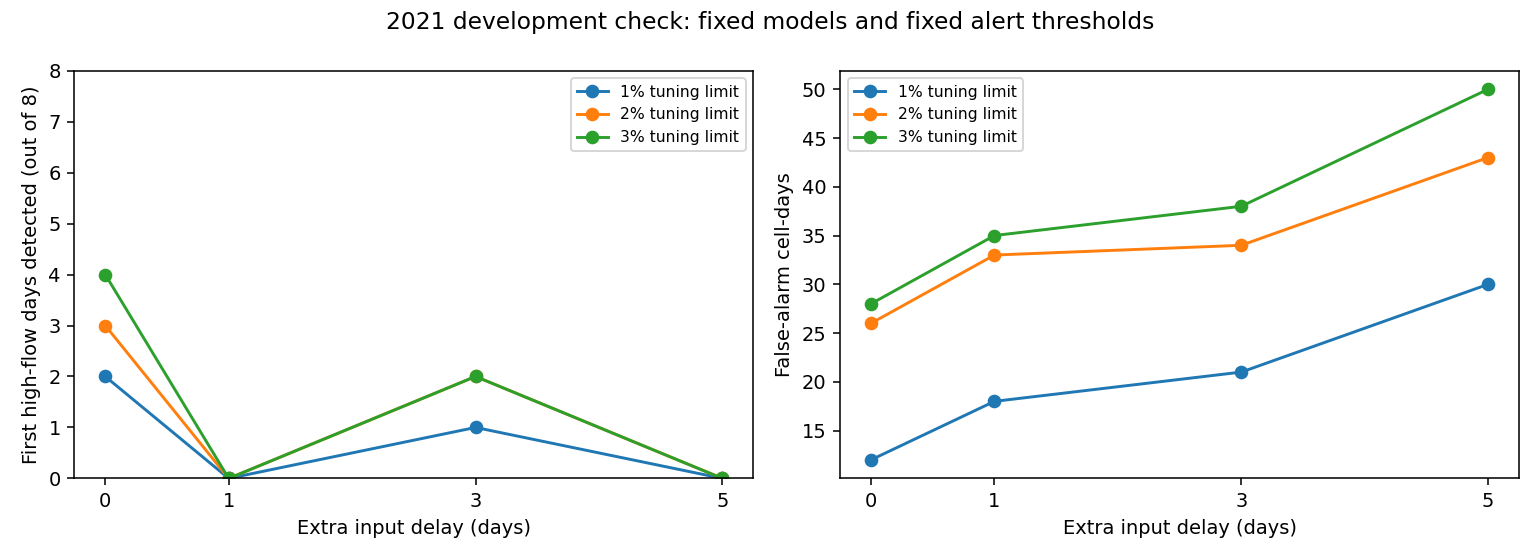

In [146]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path("data/cache/matplotlib").resolve()))
import matplotlib.pyplot as plt
from IPython.display import Image

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cap, group in delay_results.groupby("cap"):
    label = f"{cap:.0%} tuning limit"
    axes[0].plot(group.extra_delay_days, group.detected_onsets, marker="o", label=label)
    axes[1].plot(group.extra_delay_days, group.false_alarm_days, marker="o", label=label)
axes[0].set_ylabel("First high-flow days detected (out of 8)")
axes[0].set_ylim(0, 8)
axes[1].set_ylabel("False-alarm cell-days")
for ax in axes:
    ax.set_xlabel("Extra input delay (days)")
    ax.set_xticks([0, 1, 3, 5])
    ax.legend(fontsize=8)
fig.suptitle("2021 development check: fixed models and fixed alert thresholds")
fig.tight_layout()
limit_figure = Path("data/figures/high_flow_delay_stress.png")
fig.savefig(limit_figure, dpi=140)
plt.close(fig)
display(Image(filename=str(limit_figure)))

## 77. Prioritise data timing before final model selection
The current experiment relies strongly on very recent reconstructed flow. I should now verify when usable river-flow and rainfall inputs would actually reach a live system. I need the issue time, valid time and source version, not just a past date attached to a reconstructed value.

Once that availability is established, I can rebuild features and train models for a realistic information window. This could involve older observed inputs or archived forecasts with known issue times. I should also retain the upstream-rainfall and river-matching limitations in the project report.

I have not selected a public-alert operating limit or a final model. The shortlisted settings are research comparisons, and this stress test does not replace independent flood validation. I will leave the final test years untouched until the target, available inputs and operating rule are fixed.